Data collection conditions for $\alpha$ runs:

- **HV @ Cathode = 23 kV**
- **HV @ EL Gate = 7.5 kV**
- **Pressure  = 4 bar**

We study the intrinsic $^{222}\text{Rn}$-inducied background and perform comparative analysis with the equivalent results from NEXT-White detector.

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis')

from libs import crudo

from   iminuit import Minuit
from   iminuit.cost import LeastSquares
from   matplotlib.offsetbox import (OffsetImage, AnnotationBbox)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
from   PIL import Image
import scipy
from   scipy.optimize import curve_fit

# Styling Plot
crudo.pt.ccortesp_plot_style()
PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

Crudo package loaded successfully.
Available sub-modules: data_management (dm), energy_functions (ef), fit_functions (ff), plotting_tools (pt), topology_functions (tf), utilities (ut).


# Preliminary

## Global Definitions

The subsequent definition of global variables is a roadmap through the following $\alpha$ analysis for the $^{222}Rn$-induced background

In [2]:
# Dataframe name to analyze
DF_NAME = 'Rn_background'   # 'alpha_runs' (old version), 'Rn_background' (new version), 'run_14739', 'test_s2w'

# Trigger rate for low-Rn period from the trigger fit
TRG_RATE_LOW_RN_CV, TRG_RATE_LOW_RN_ERR = 0.0, 0.0

# Lifetime
LIFETIME = 0.0      # In [μs]

# Run number definition of High-Rn and Low-Rn periods
HIGH_RN_RUNS = [14739]
LOW_RN_RUNS  = [14834, 14835, 14837, 14838, 14839, 14840]

# Alpha threshold
ALPHA_THRESHOLD = None       # In [PE]. It can be None or 900 e.g

# Directory with important information
ANA_DATA = {'High_Rn': {},  'Low_Rn' : {}}

# Alpha trigger count efficiency (not all the OK triggers are alphas events) ---> numbers given by Pau!
ALPHA_TRG_EFF_HIGH = 0.7542
ALPHA_TRG_EFF_LOW  = 0.3056
TRG_EFF_ERR  = 0.1     # Relative error

## Data

In [3]:
# α runs!
RUNS_INFO = [
                # --- Cold-Getter: Jan 17th --- #5
                {"run_number": 14714, "duration": 64574, "OK": 1909287, "LOST": 1728359, "real_rate": 56.333},
                # {"run_number": 14715, "duration": 84365, "OK": 2469062, "LOST": 2239303, "real_rate": 55.809},      # Waveforms in magnetic tape, not processed
                {"run_number": 14716, "duration": 17036, "OK": 495769 , "LOST": 451306 , "real_rate": 55.592},
                {"run_number": 14720, "duration": 48518, "OK": 1432110, "LOST": 1294941, "real_rate": 56.207},      # Estimated from fit
                {"run_number": 14733, "duration": 53881, "OK": 1587637, "LOST": 1429629, "real_rate": 55.998},
                {"run_number": 14735, "duration": 84987, "OK": 2508569, "LOST": 2267982, "real_rate": 56.203},
                {"run_number": 14737, "duration": 72705, "OK": 2153786, "LOST": 1960347, "real_rate": 56.586},
                {"run_number": 14739, "duration": 87138, "OK": 2576630, "LOST": 2334343, "real_rate": 56.358},
                {"run_number": 14741, "duration": 87755, "OK": 2592615, "LOST": 2349583, "real_rate": 56.318},
                {"run_number": 14743, "duration": 82332, "OK": 2437984, "LOST": 2220643, "real_rate": 56.583},
                {"run_number": 14745, "duration": 60990, "OK": 1803415, "LOST": 1636317, "real_rate": 56.398},
                
                # --- Hot-Getter: Jan 27th --- #
                {"run_number": 14753, "duration": 86308, "OK": 2188547, "LOST": 1532351, "real_rate": 43.111},
                {"run_number": 14765, "duration": 55978, "OK": 1259832, "LOST": 735202 , "real_rate": 35.639},
                # {"run_number": 14776, "duration": 47397, "OK": 957081 , "LOST": 481810 , "real_rate": 30.358},      # Data removed
                {"run_number": 14780, "duration": 88503, "OK": 1600797, "LOST": 682246 , "real_rate": 25.796},
                # Feb 2025
                {"run_number": 14782, "duration": 85654, "OK": 1382153, "LOST": 506234 , "real_rate": 22.046},
                {"run_number": 14784, "duration": 57290, "OK": 842541 , "LOST": 273581 , "real_rate": 19.481},
                {"run_number": 14789, "duration": 74148, "OK": 976360 , "LOST": 277504 , "real_rate": 16.910},
                # --- Zero Suppression --- #
                {"run_number": 14803, "duration": 71721, "OK": 933727 , "LOST": 104677 , "real_rate": 14.478},
                {"run_number": 14804, "duration": 65116, "OK": 680552 , "LOST": 156995 , "real_rate": 12.862},
                # --- NO Zero Suppression --- #
                {"run_number": 14811, "duration": 84651, "OK": 782816 , "LOST": 147773 , "real_rate": 10.993},
                {"run_number": 14814, "duration": 6344 , "OK": 55679  , "LOST": 10155  , "real_rate": 10.377},
                {"run_number": 14815, "duration": 86232, "OK": 717786 , "LOST": 121527 , "real_rate": 9.733 },
                {"run_number": 14816, "duration": 86580, "OK": 659265 , "LOST": 101374 , "real_rate": 8.785 },
                {"run_number": 14817, "duration": 49662, "OK": 352203 , "LOST": 50474  , "real_rate": 8.108 },
                {"run_number": 14828, "duration": 53609, "OK": 300827 , "LOST": 100405 , "real_rate": 7.484 },
                {"run_number": 14829, "duration": 73042, "OK": 387003 , "LOST": 121249 , "real_rate": 6.958 },
                {"run_number": 14834, "duration": 5779 , "OK": 32864  , "LOST": 3887   , "real_rate": 6.359 },    # Low-Rn here after
                {"run_number": 14835, "duration": 11713, "OK": 66515  , "LOST": 7358   , "real_rate": 6.306 },
                {"run_number": 14837, "duration": 55751, "OK": 294175 , "LOST": 31034  , "real_rate": 5.833 },
                {"run_number": 14838, "duration": 87854, "OK": 431766 , "LOST": 42219  , "real_rate": 5.395 },
                {"run_number": 14839, "duration": 84881, "OK": 401004 , "LOST": 37747  , "real_rate": 5.169 },
                {"run_number": 14840, "duration": 56174, "OK": 260266 , "LOST": 23627  , "real_rate": 5.054 },
            ]

### Reconstructed

In [4]:
RECO_DATA = {run["run_number"]: crudo.dm.load_run_data(run, trigger=None)[run["run_number"]] for run in RUNS_INFO}

/DST/Events: Run 14714 successfully loaded with data shape: (295774, 26)
/DST/Events: Run 14716 successfully loaded with data shape: (147883, 26)
/DST/Events: Run 14720 successfully loaded with data shape: (427675, 26)
/DST/Events: Run 14733 successfully loaded with data shape: (246994, 26)
/DST/Events: Run 14735 successfully loaded with data shape: (380009, 26)
/DST/Events: Run 14737 successfully loaded with data shape: (337148, 26)
/DST/Events: Run 14739 successfully loaded with data shape: (403582, 26)
/DST/Events: Run 14741 successfully loaded with data shape: (405333, 26)
/DST/Events: Run 14743 successfully loaded with data shape: (381001, 26)
/DST/Events: Run 14745 successfully loaded with data shape: (280653, 26)
/DST/Events: Run 14753 successfully loaded with data shape: (302638, 26)
/DST/Events: Run 14765 successfully loaded with data shape: (244159, 26)
/DST/Events: Run 14780 successfully loaded with data shape: (128058, 26)
/DST/Events: Run 14782 successfully loaded with dat

Compute the efficiency of reconstructed events (after Sophronia) wrt the number of OK triggers

In [5]:
for i, entry in enumerate(RUNS_INFO):

    # Run info
    run_id = entry["run_number"]
    run_OK = entry["OK"]

    # Skip runs without raw data
    if RECO_DATA[run_id].empty:
        print(f"Run {run_id}: No raw data available")
        continue

    # Number of reconstructed events (after Sophronia)
    reco_evt_CV  = RECO_DATA[run_id]['event'].nunique()         if run_OK != -1 else -1
    reco_eff     = reco_evt_CV / run_OK                         if run_OK != -1 else -1
    reco_evt_err = np.sqrt(run_OK * reco_eff * (1 - reco_eff))  if run_OK != -1 else -1

    # Store and print information
    RUNS_INFO[i]["reco_evt_CV"]  = reco_evt_CV
    RUNS_INFO[i]["reco_evt_err"] = reco_evt_err
    print(f"Run {run_id}: ({reco_evt_CV} ± {reco_evt_err:.2f}) reconstructed events || ({reco_eff:.2%})")

Run 14714: (249139 ± 465.43) reconstructed events || (13.05%)
Run 14716: (58019 ± 226.34) reconstructed events || (11.70%)
Run 14720: (165556 ± 382.65) reconstructed events || (11.56%)
Run 14733: (203652 ± 421.34) reconstructed events || (12.83%)
Run 14735: (320146 ± 528.48) reconstructed events || (12.76%)
Run 14737: (284140 ± 496.64) reconstructed events || (13.19%)
Run 14739: (339737 ± 543.09) reconstructed events || (13.19%)
Run 14741: (341117 ± 544.28) reconstructed events || (13.16%)
Run 14743: (321175 ± 528.08) reconstructed events || (13.17%)
Run 14745: (236082 ± 452.96) reconstructed events || (13.09%)
Run 14753: (263681 ± 481.57) reconstructed events || (12.05%)
Run 14765: (120241 ± 329.80) reconstructed events || (9.54%)
Run 14780: (118417 ± 331.15) reconstructed events || (7.40%)
Run 14782: (152523 ± 368.36) reconstructed events || (11.04%)
Run 14784: (89383 ± 282.67) reconstructed events || (10.61%)
Run 14789: (93077 ± 290.18) reconstructed events || (9.53%)
Run 14803: (24

### Selected

Compute the efficiency of selected events wrt the number of reconstructed events.

In [6]:
# Open the file with selected data
with open(f"/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Rn_analysis/pkl/{DF_NAME}.pkl", "rb") as file:
    SEL_DATA = pickle.load(file)
            
# This is the number of events you work with
for i, entry in enumerate(RUNS_INFO):

    # Run info
    run_id = entry["run_number"]
    run_OK = entry["OK"]

    # Skip runs without raw data
    if RECO_DATA[run_id].empty:
        print(f"Run {run_id}: No raw data available")
        continue

    # Number of selected events
    reco_evt_CV = RECO_DATA[run_id]['event'].nunique()           if run_OK != -1 else -1
    sel_evt_CV  = SEL_DATA[run_id]['event'].nunique()            if run_OK != -1 else -1
    sel_eff     = sel_evt_CV / reco_evt_CV                       if run_OK != -1 else -1
    sel_evt_err = np.sqrt(reco_evt_CV * sel_eff * (1 - sel_eff)) if run_OK != -1 else -1

    # Store and print information
    RUNS_INFO[i]["sel_evt_CV"]  = sel_evt_CV
    RUNS_INFO[i]["sel_evt_err"] = sel_evt_err
    print(f"Run {run_id}: ({sel_evt_CV} ± {sel_evt_err:.2f}) selected events || ({sel_eff:.2%})")

Run 14714: (53934 ± 205.57) selected events || (21.65%)
Run 14716: (6684 ± 76.90) selected events || (11.52%)
Run 14720: (18837 ± 129.20) selected events || (11.38%)
Run 14733: (43267 ± 184.59) selected events || (21.25%)
Run 14735: (68902 ± 232.54) selected events || (21.52%)
Run 14737: (60859 ± 218.69) selected events || (21.42%)
Run 14739: (72968 ± 239.37) selected events || (21.48%)
Run 14741: (73686 ± 240.35) selected events || (21.60%)
Run 14743: (68656 ± 232.34) selected events || (21.38%)
Run 14745: (50495 ± 199.24) selected events || (21.39%)
Run 14753: (59966 ± 215.24) selected events || (22.74%)
Run 14765: (18724 ± 125.73) selected events || (15.57%)
Run 14780: (29981 ± 149.63) selected events || (25.32%)
Run 14782: (41063 ± 173.23) selected events || (26.92%)
Run 14784: (24307 ± 133.03) selected events || (27.19%)
Run 14789: (24925 ± 135.09) selected events || (26.78%)
Run 14803: (65672 ± 219.80) selected events || (26.44%)
Run 14804: (46641 ± 185.55) selected events || (26

## Masks

#### Exclusion dictionaries due to lack of information

In [7]:
# They have not yet been processed
NO_data = {
            14715: "NO processed",
            14776: "Data removed",
          }

# They have problems with the reconstruction
NO_reco = {
            14716: "Glowing?",
            14720: "Glowing?",
            14765: "Glowing?",
          }
NO_reco = {**NO_data, **NO_reco}

#### Active volume and cathode surroundings masks!

In [8]:
# Dictionaries with masks!
DT_stop   = {run["run_number"]: {} for run in RUNS_INFO}
AV_mask   = {run["run_number"]: {} for run in RUNS_INFO}
cath_mask = {run["run_number"]: {} for run in RUNS_INFO}

for i, entry in enumerate(RUNS_INFO):

    # Run info
    run_id   = entry["run_number"]
    run_rate = entry["real_rate"]

    # Time mask
    DT_stop[run_id] = crudo.tf.cathode_position(entry, SEL_DATA, step_back=1)[run_id]
    # Active volume
    AV_mask[run_id] = (SEL_DATA[run_id]['DT'] >= 0) & (SEL_DATA[run_id]['DT'] < DT_stop[run_id])
    # Cathode surroundings
    cath_mask[run_id] = SEL_DATA[run_id]['DT'] >= DT_stop[run_id]

Run 14714: DT_stop = 1321.82 μs
Run 14716: DT_stop = 1320.90 μs
Run 14720: DT_stop = 1320.47 μs
Run 14733: DT_stop = 1316.15 μs
Run 14735: DT_stop = 1318.06 μs
Run 14737: DT_stop = 1317.45 μs
Run 14739: DT_stop = 1320.61 μs
Run 14741: DT_stop = 1320.36 μs
Run 14743: DT_stop = 1319.18 μs
Run 14745: DT_stop = 1320.22 μs
Run 14753: DT_stop = 1318.90 μs
Run 14765: DT_stop = 1319.41 μs
Run 14780: DT_stop = 1320.27 μs
Run 14782: DT_stop = 1320.69 μs
Run 14784: DT_stop = 1326.87 μs
Run 14789: DT_stop = 1320.44 μs
Run 14803: DT_stop = 1320.53 μs
Run 14804: DT_stop = 1321.26 μs
Run 14811: DT_stop = 1318.70 μs
Run 14814: DT_stop = 1316.32 μs
Run 14815: DT_stop = 1318.84 μs
Run 14816: DT_stop = 1321.77 μs
Run 14817: DT_stop = 1314.75 μs
Run 14828: DT_stop = 1321.74 μs
Run 14829: DT_stop = 1320.31 μs
Run 14834: DT_stop = 1325.08 μs
Run 14835: DT_stop = 1316.38 μs
Run 14837: DT_stop = 1319.99 μs
Run 14838: DT_stop = 1319.93 μs
Run 14839: DT_stop = 1317.14 μs
Run 14840: DT_stop = 1318.80 μs


## ELOG Issues

Sometimes, there are problems with the ELOG writing of the trigger values.
<br>
I estimate them from fits to the trigger real rate.

In [10]:
# Global
Date     = []
Date_err = []
Rate     = []
Rate_err = []
Run_numbers = []

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    run_long = entry["duration"]
    run_OK   = entry["OK"]
    run_LOST = entry["LOST"]
    
    # Skip runs without elog information
    if run_id in {14720}:  
        print(f"Skipping run {run_id}...")  
        continue

    Run_numbers.append(run_id)  # I need the ids for plotting
    
    # Mean date + error for each run
    date_CV = SEL_DATA[run_id]['time'].mean()
    Date.append(date_CV)
    date_error = SEL_DATA[run_id]['time'].std() / np.sqrt(len(SEL_DATA[run_id]['time']))
    Date_err.append(date_error)
    
    # Real rate + error for each run
    run_trigg = run_OK + run_LOST
    rate_CV   = run_trigg / run_long
    Rate.append(rate_CV)
    rate_stat = np.sqrt(run_trigg) / run_long
    Rate_err.append(rate_stat)
  
# ----- Fit ----- #
# Preliminary
Date     = np.array(Date)
Date_err = np.array(Date_err)
Rate     = np.array(Rate)
Rate_err = np.array(Rate_err)

# Masking: select specific data
HG_time = (Date >= 1737975600)
CG_time = (Date <  1737975600)

x_data = Date[CG_time]
y_data = Rate[CG_time]
y_err  = Rate_err[CG_time]

# Shifted time
x_shift = (x_data - x_data[0]) / 3600  # In [hr] for numeric stability

# Define the cost function + initial guess
least_squares = LeastSquares(x_shift, y_data, y_err, crudo.ff.linear_func)
init_guess    = [10, y_data.max()]
print(f'\nInitial guess: m = {init_guess[0]:.4f} Hz/hr, b = {init_guess[1]:.4f} Hz')
# print(f'\nInitial guess: N0 = {init_guess[0]:.4f} Hz, tau = {init_guess[1]:.4f} hr, b = {init_guess[2]:.4f} Hz')

# Define the Minuit object
m = Minuit(least_squares, *init_guess)

# Minimization process of the cost function and error estimation
m.migrad()
m.hesse()

# Results
popt = m.values;  perr = m.errors
print(f"\nFit results:")
print(f"  m = ({popt['m']:.4f} ± {perr['m']:.4f}) Hz/hr")
# print(f"  N0  = ({popt['N0']:.4f} ± {perr['N0']:.4f}) Hz")
# print(f"  tau = ({popt['tau']:.4f} ± {perr['tau']:.4f}) hr")
print(f"  b = ({popt['b']:.4f} ± {perr['b']:.4f}) Hz")

# Reduced chi-square
chi2 = m.fval
ndof = len(x_shift) - m.nfit
print(f"χ² / ndof = {chi2 / ndof:.4f}")  

Skipping run 14720...

Initial guess: m = 10.0000 Hz/hr, b = 56.5867 Hz

Fit results:
  m = (0.0017 ± 0.0002) Hz/hr
  b = (56.1318 ± 0.0212) Hz
χ² / ndof = 51.9221


In [ ]:
# ----- Estimation for Run of Interest ----- #
Run_ID = 14720
run_index = next((index for index, run in enumerate(RUNS_INFO) if run["run_number"] == Run_ID), None)
run_duration = RUNS_INFO[run_index]["duration"]

run_date = (SEL_DATA[Run_ID]['time'].mean() - x_data[0]) / 3600        # Shifted time for the run
run_rate = crudo.ff.linear_func(run_date, *popt)                       # Real rate from the fit
print(f"\nEstimated real rate for Run {Run_ID}: {run_rate:.3f} Hz")   


Estimated real rate for Run 14720: 56.207 Hz


# Rate Plots

### Trigger

After starting the hot-getter, we want to characterize the rate decay in the trigger system. 
<br>
It should be consistent with the half-life of the $^{222}\text{Rn}$ and let us define the baseline level of intrinsic $^{222}\text{Rn}$ in the detector.

In [11]:
# ----- Error Band Determination ----- #
# The error band is determined by the standard deviation of the real rate of the Cold-Getter (CG) runs
CG_rate = []

for i, entry in enumerate(RUNS_INFO):

    # Run info
    run_id   = entry["run_number"]
    run_long = entry["duration"]
    run_OK   = entry["OK"]
    run_LOST = entry["LOST"]

    # Run date
    date_CV = SEL_DATA[run_id]['time'].mean()

    # Run real rate (just for the CG runs)
    if date_CV < 1737975600:
        run_trigg = run_OK + run_LOST
        rate_CV   = run_trigg / run_long
        CG_rate.append(rate_CV)
        # print(f'Run {run_id}: {rate_CV:.4f} Hz')

# CG data
CG_sigma = np.std(CG_rate)
print(f'Cold-getter regime: σ = {CG_sigma:.4f} Hz')

Cold-getter regime: σ = 0.2772 Hz


In [12]:
# ----- Radon Decay Data ----- #
Date     = []
Date_err = []
Rate     = []
Rate_err = []
Run_numbers = []

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    run_long = entry["duration"]
    run_OK   = entry["OK"]
    run_LOST = entry["LOST"]

    if run_id in [14716, 14835]:  
        print(f"Skipping run {run_id}... plotting purposes")  
        continue

    Run_numbers.append(run_id)
    
    # Mean date + error for each run
    date_CV = SEL_DATA[run_id]['time'].mean()
    Date.append(date_CV)
    date_error = SEL_DATA[run_id]['time'].std() / np.sqrt(len(SEL_DATA[run_id]['time']))
    Date_err.append(date_error)
    
    # Real rate + error for each run
    run_trigg = run_OK + run_LOST
    rate_CV   = run_trigg / run_long
    Rate.append(rate_CV)
    rate_stat = np.sqrt(run_trigg) / run_long
    Rate_err.append(np.sqrt(rate_stat**2 + CG_sigma**2))                    # Total error (including CG error)

    print(f"Run {run_id}: Rate = {rate_CV:.4f} ± {np.sqrt(rate_stat**2 + CG_sigma**2):.4f} Hz")

Run 14714: Rate = 56.3330 ± 0.2788 Hz
Skipping run 14716... plotting purposes
Run 14720: Rate = 56.2070 ± 0.2793 Hz
Run 14733: Rate = 55.9987 ± 0.2791 Hz
Run 14735: Rate = 56.2033 ± 0.2784 Hz
Run 14737: Rate = 56.5867 ± 0.2786 Hz
Run 14739: Rate = 56.3586 ± 0.2784 Hz
Run 14741: Rate = 56.3181 ± 0.2784 Hz
Run 14743: Rate = 56.5834 ± 0.2785 Hz
Run 14745: Rate = 56.3983 ± 0.2789 Hz
Run 14753: Rate = 43.1119 ± 0.2781 Hz
Run 14765: Rate = 35.6396 ± 0.2784 Hz
Run 14780: Rate = 25.7962 ± 0.2778 Hz
Run 14782: Rate = 22.0467 ± 0.2777 Hz
Run 14784: Rate = 19.4820 ± 0.2778 Hz
Run 14789: Rate = 16.9103 ± 0.2776 Hz
Run 14803: Rate = 14.4784 ± 0.2776 Hz
Run 14804: Rate = 12.8624 ± 0.2776 Hz
Run 14811: Rate = 10.9932 ± 0.2775 Hz
Run 14814: Rate = 10.3774 ± 0.2802 Hz
Run 14815: Rate = 9.7332 ± 0.2774 Hz
Run 14816: Rate = 8.7854 ± 0.2774 Hz
Run 14817: Rate = 8.1084 ± 0.2775 Hz
Run 14828: Rate = 7.4844 ± 0.2775 Hz
Run 14829: Rate = 6.9584 ± 0.2774 Hz
Run 14834: Rate = 6.3594 ± 0.2792 Hz
Skipping run 148

In [14]:
# ----- Exponential + Constant Fit ----- #
# Preliminary
Date     = np.array(Date)
Date_err = np.array(Date_err)
Rate     = np.array(Rate)
Rate_err = np.array(Rate_err)

# Masking: select specific data
HG_time = (Date >= 1737975600)

x_data = Date[HG_time]
y_data = Rate[HG_time]
y_err  = Rate_err[HG_time]

# Shifted time
x_shift = (x_data - x_data[0]) / 3600  # In [hr] for numeric stability

# Define the cost function + initial guess
least_squares = LeastSquares(x_shift, y_data, y_err, crudo.ff.exponential_decay)
init_guess    = [y_data.max(), (x_shift.max() - x_shift.min()) / 2, y_data.min()]
print(f'Initial guess: N0 = {init_guess[0]:.4f} Hz, tau = {init_guess[1]:.4f} hr, b = {init_guess[2]:.4f} Hz')

# Define the Minuit object
m = Minuit(least_squares, *init_guess)

# Minimization process of the cost function and error estimation
m.migrad()
m.hesse()

# Results
popt = m.values;  perr = m.errors
print(f"\nFit results:")
print(f"  N0  = ({popt['N0']:.4f} ± {perr['N0']:.4f}) Hz")
print(f"  tau = ({popt['tau']:.4f} ± {perr['tau']:.4f}) hr")
print(f"  b   = ({popt['b']:.4f} ± {perr['b']:.4f}) Hz")

# Reduced chi-square
chi2 = m.fval
ndof = len(x_shift) - m.nfit
print(f"\nχ² / ndof = {chi2 / ndof:.4f}")

# Half-life
CV_lambda    = (popt['tau'] * np.log(2)) / 24  # In [d] to compare
Error_lambda = (perr['tau'] * np.log(2)) / 24
print(f"\nHalf-life = ({CV_lambda:.4f} ± {Error_lambda:.4f}) d")

# Low-Rn trigger rate
TRG_RATE_LOW_RN_CV  = popt['b']
TRG_RATE_LOW_RN_ERR = perr['b']
print(f"Estimated low-Rn trigger rate: ({TRG_RATE_LOW_RN_CV:.4f} ± {TRG_RATE_LOW_RN_ERR:.4f}) Hz")

# Fit
x_fit = (x_shift * 3600) + x_data[0]  # In [s]
y_fit = crudo.ff.exponential_decay(x_shift, *popt)

Initial guess: N0 = 43.1119 Hz, tau = 228.5998 hr, b = 5.0538 Hz

Fit results:
  N0  = (39.2067 ± 0.2377) Hz
  tau = (130.4632 ± 2.0291) hr
  b   = (3.8914 ± 0.1722) Hz

χ² / ndof = 0.1150

Half-life = (3.7679 ± 0.0586) d
Estimated low-Rn trigger rate: (3.8914 ± 0.1722) Hz


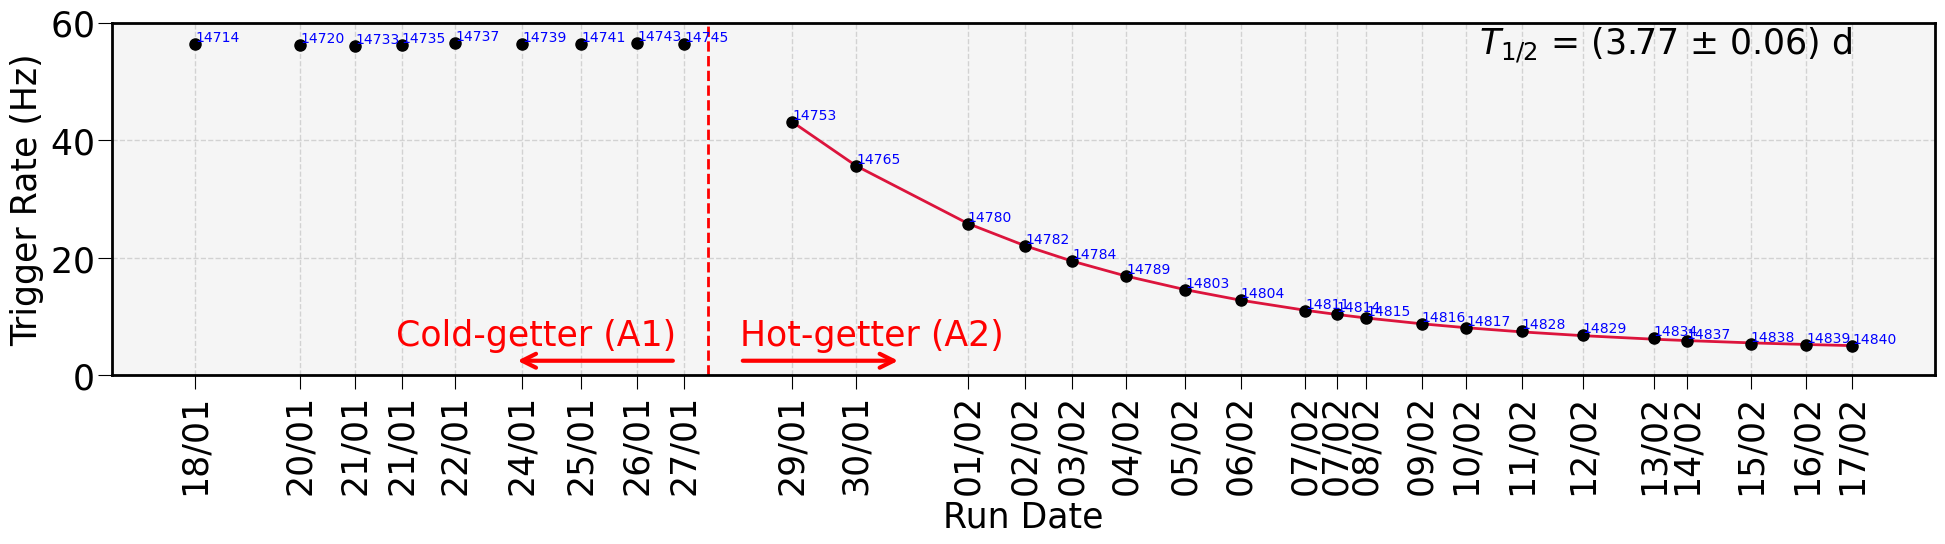

In [16]:
# ----- Plotting ---- #
fig, ax = plt.subplots(figsize=(20, 6))

# Data
plt.errorbar(Date, Rate, xerr=Date_err, yerr=Rate_err, fmt='o', c='black', ecolor='black')
for x, y, run_id in zip(Date, Rate, Run_numbers):
    plt.text(x, y, str(run_id), fontsize=10, ha='left', va='bottom', color='blue')  # Run number near the point

# Fit
plt.plot(x_fit, y_fit, color=crudo.pt.hist_colors[(1) % len(crudo.pt.hist_colors)], label=f'Fit\nχ² / ndof = {chi2 / ndof:.4f}')

# ----- Styling ----- #
# Important text
plt.axvline(x=1737975600, c='red', ls='--')
plt.text(1737975600+5e4, 4.0, 'Hot-getter (A2)', c='red', va='bottom', ha='left')
ax.annotate('', xytext=(1737975600+5e4, 2.5), xy=(1737975600+3e5, 2.5), arrowprops=dict(arrowstyle='->',  ec='red', fc='red'))
plt.text(1737975600-5e4, 4.0, 'Cold-getter (A1)', c='red', va='bottom', ha='right')
ax.annotate('', xytext=(1737975600-5e4, 2.5), xy=(1737975600-3e5, 2.5), arrowprops=dict(arrowstyle='->',  ec='red', fc='red'))
plt.text(Date.max(), 53, r'$T_{1/2}$'f' = ({CV_lambda:.2f} ± {Error_lambda:.2f}) d', va='bottom', ha='right')

# # Preliminary logo
# LOGO_BOX    = OffsetImage(PRELIM_LOGO, zoom = 0.1)
# xy = (Date.max(), Rate.max())
# ab = AnnotationBbox(LOGO_BOX, xy, xybox=(-67, 0), xycoords='data', boxcoords="offset points",  frameon=False)
# ax.add_artist(ab)

# Axes
plt.xlabel('Run Date')
x_labels = [crudo.ut.epoch_converter(t, h=False) for t in Date]  # Convert x-axis bin edges to readable time format
plt.xticks(Date, x_labels, rotation=90, ha='center')
plt.ylabel('Trigger Rate (Hz)')
plt.ylim(0, 60)
# plt.title('Trigger Real Rate')
# plt.legend(loc='upper right', fontsize=8)

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig(f'/lhome/ific/c/ccortesp/Analysis/NEXT-100/Rn_analysis/images/Trigger_Rate_Evolution.pdf')
plt.tight_layout()
plt.show()

### DAQ Efficiency

In [21]:
# # Global
# x_date = []

# for i, entry in enumerate(RUNS_INFO):
    
#     # Run info
#     run_id   = entry["run_number"]
#     run_OK   = entry["OK"]
#     run_LOST = entry["LOST"]

#     # DAQe efficiency + error
#     DAQe_CV, DAQe_error = crudo.ff.efficiency(run_OK, run_LOST)
    
#     # Date information    
#     Date_CV    = SEL_DATA[run_id]['time'].mean()
#     Date_error = SEL_DATA[run_id]['time'].std() / np.sqrt(len(SEL_DATA[run_id]['time']))
#     x_date.append(Date_CV)

#     # Plot
#     plt.errorbar(Date_CV, DAQe_CV, xerr=Date_error, yerr=DAQe_error, fmt='o', c='black', ecolor='black')
#     plt.text(Date_CV, DAQe_CV, str(run_id), fontsize=10, ha='left', va='bottom', color='blue')   # Run number near the point

# # Important dates
# plt.axvline(x=1737975600, c='red', ls='--')
# plt.text(1737975600-1e4, 0.9, 'Hot-getter recirculation', c='red', va='top', ha='right', rotation=90)

# # Styling
# plt.xlabel('Run Date')
# x_labels = [crudo.ut.epoch_converter(t, h=False) for t in x_date]  # Convert x-axis bin edges to readable time format
# plt.xticks(x_date, x_labels, rotation=90, ha='center')
# plt.ylabel('DAQ Efficiency')

# plt.grid(True)
# plt.gca().set_facecolor("whitesmoke")
# plt.show()

### Reconstructed Events

Este plot no está corregido por la eficiencia de reconstrucción.

In [20]:
# # Global
# x_date = []

# for i, entry in enumerate(RUNS_INFO):
    
#     # Run info
#     run_id   = entry["run_number"]
#     run_long = entry["duration"]
#     run_OK   = entry["OK"]
#     run_LOST = entry["LOST"]

#     # DAQe efficiency + error
#     DAQe_CV, DAQe_error = crudo.ff.efficiency(run_OK, run_LOST)
    
#     # Date information    
#     Date_CV    = SEL_DATA[run_id]['time'].mean()
#     Date_error = SEL_DATA[run_id]['time'].std() / np.sqrt(len(SEL_DATA[run_id]['time']))
#     x_date.append(Date_CV)
    
#     # Reco events
#     reco_evts  = entry['reco_evt_CV'];  reco_evts = int(reco_evts)
#     reco_CV, reco_var = scipy.stats.binom.stats(n=run_OK, p=reco_evts/run_OK, moments='mv')
    
#     # Reco rate + error for each run
#     rate_CV  = reco_CV / (run_long * DAQe_CV)
#     rate_err = rate_CV * np.sqrt((np.sqrt(reco_var) / reco_CV)**2 + (DAQe_error / DAQe_CV)**2)

#     # Plot
#     plt.errorbar(Date_CV, rate_CV, xerr=Date_error, yerr=rate_err, fmt='o', c='black', ecolor='black')
#     plt.text(Date_CV, rate_CV, str(run_id), fontsize=10, ha='left', va='bottom', color='blue')   # Run number near the point

# # Important dates
# plt.axvline(x=1737975600, c='red', ls='--')
# plt.text(1737975600-1e4, 0.5, 'Hot-getter recirculation', c='red', va='bottom', ha='right', rotation=90)

# # Styling
# plt.xlabel('Run Date')
# x_labels = [crudo.ut.epoch_converter(t, h=False) for t in x_date]  # Convert x-axis bin edges to readable time format
# plt.xticks(x_date, x_labels, rotation=90, ha='center')
# plt.ylabel('Rate (Hz)')
# # plt.title(r'Reconstructed Events')

# plt.grid(True)
# plt.gca().set_facecolor("whitesmoke")
# plt.show()

### $\alpha$ Candidates

Este plot no está corregido por la eficiencia de selección.

In [23]:
# # Global
# x_date = []

# for i, entry in enumerate(RUNS_INFO):
    
#     # Run info
#     run_id   = entry["run_number"]
#     run_long = entry["duration"]
#     run_OK   = entry["OK"]
#     run_LOST = entry["LOST"]

#     # DAQe efficiency + error
#     DAQe_CV, DAQe_error = crudo.ff.efficiency(run_OK, run_LOST)
    
#     # Date information    
#     Date_CV    = SEL_DATA[run_id]['time'].mean()
#     Date_error = SEL_DATA[run_id]['time'].std() / np.sqrt(len(SEL_DATA[run_id]['time']))
#     x_date.append(Date_CV)
    
#     # Reco events
#     reco_evts  = entry['sel_evt_CV'];  reco_evts = int(reco_evts)
#     reco_CV, reco_var = scipy.stats.binom.stats(n=run_OK, p=reco_evts/run_OK, moments='mv')
    
#     # Reco rate + error for each run
#     rate_CV  = reco_CV / (run_long * DAQe_CV)
#     rate_err = rate_CV * np.sqrt((np.sqrt(reco_var) / reco_CV)**2 + (DAQe_error / DAQe_CV)**2)

#     # Plot
#     plt.errorbar(Date_CV, rate_CV, xerr=Date_error, yerr=rate_err, fmt='o', c='black', ecolor='black')
#     plt.text(Date_CV, rate_CV, str(run_id), fontsize=10, ha='left', va='bottom', color='blue')   # Run number near the point

# # Important dates
# plt.axvline(x=1737975600, c='red', ls='--')
# plt.text(1737975600-1e4, 0, 'Hot-getter recirculation', c='red', va='bottom', ha='right', rotation=90)

# # Styling
# plt.xlabel('Run Date')
# x_labels = [crudo.ut.epoch_converter(t, h=False) for t in x_date]  # Convert x-axis bin edges to readable time format
# plt.xticks(x_date, x_labels, rotation=90, ha='center')
# plt.ylabel('Rate (Hz)')
# # plt.title(r'$\alpha$ Candidates')

# plt.grid(True)
# plt.gca().set_facecolor("whitesmoke")
# plt.show()

# Fits
To fit data we just use the population of the detector's center, where the information is quite uniform.

In [25]:
# Store fits information
FIT_PARAMETERS = {run["run_number"]: {} for run in RUNS_INFO}

### $S1e$ vs DT

Run 14714 Fit: m = (0.57 ± 0.00) PE/μs, b = (791.61 ± 1.76) PE
χ² / ndof = 1.5956


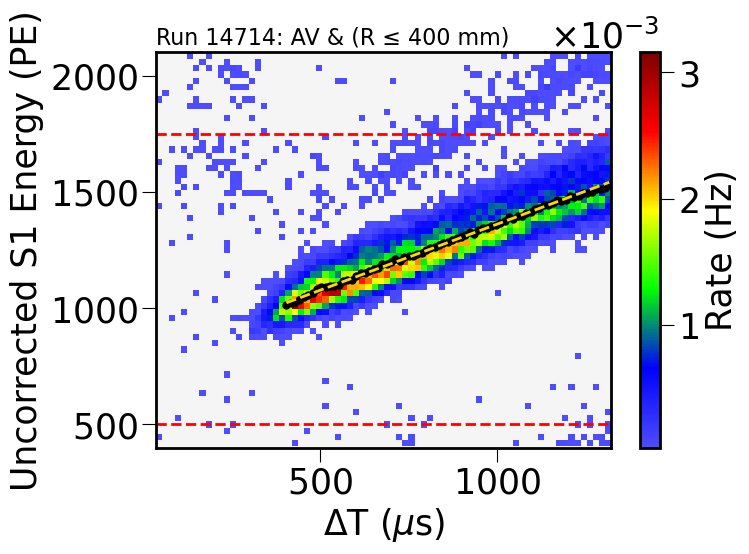

Run 14716 Fit: m = (0.58 ± 0.01) PE/μs, b = (785.81 ± 4.82) PE
χ² / ndof = 1.4104


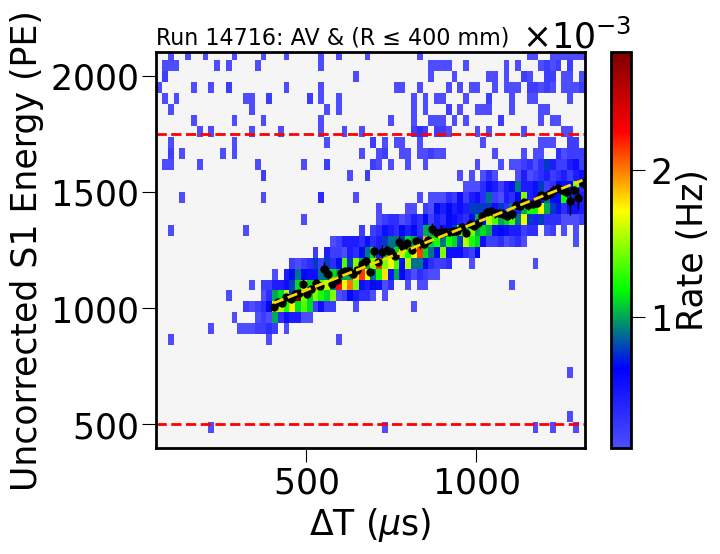

Run 14720 Fit: m = (0.54 ± 0.01) PE/μs, b = (825.46 ± 4.69) PE
χ² / ndof = 1.2454


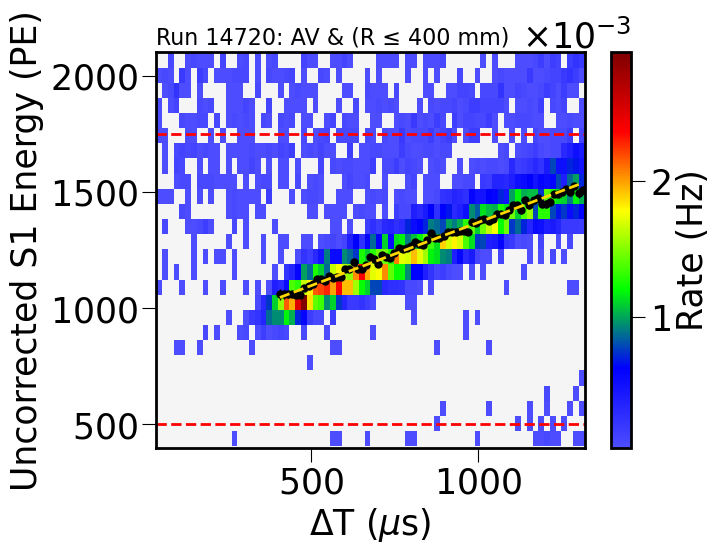

Run 14733 Fit: m = (0.57 ± 0.00) PE/μs, b = (791.74 ± 1.91) PE
χ² / ndof = 1.6118


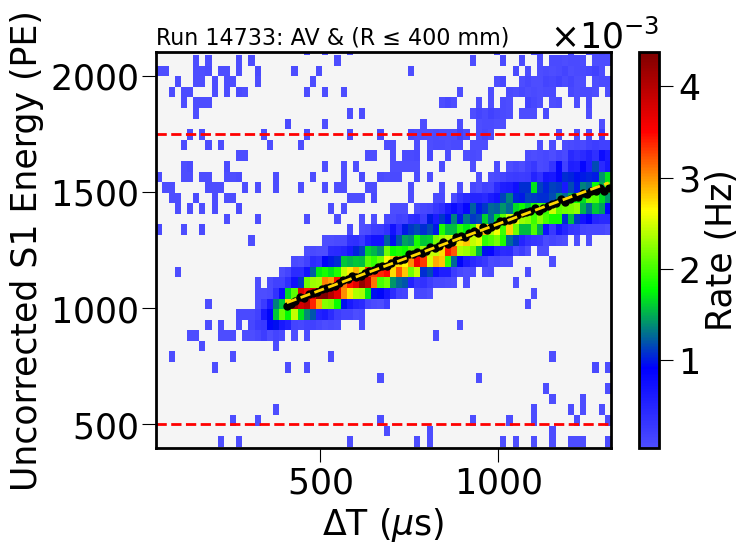

Run 14735 Fit: m = (0.57 ± 0.00) PE/μs, b = (795.80 ± 1.56) PE
χ² / ndof = 1.9630


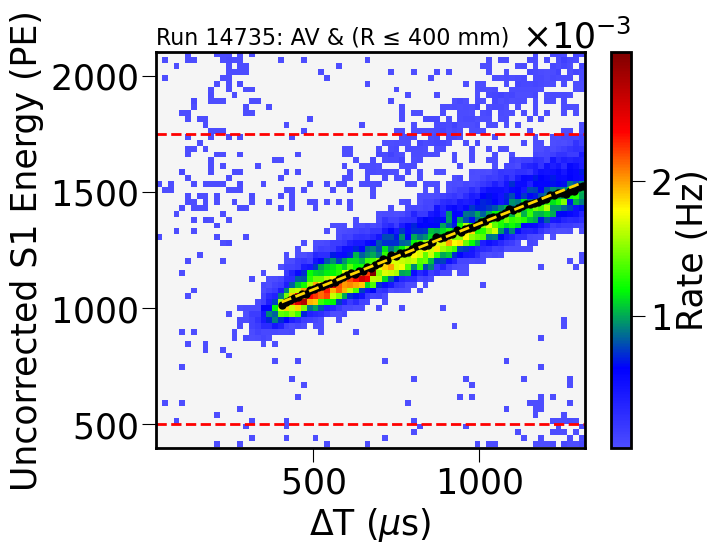

Run 14737 Fit: m = (0.56 ± 0.00) PE/μs, b = (799.04 ± 1.60) PE
χ² / ndof = 1.8549


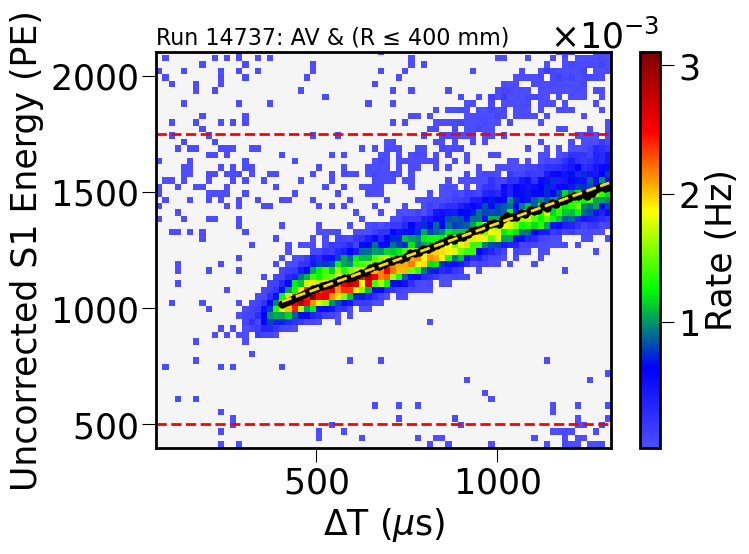

Run 14739 Fit: m = (0.57 ± 0.00) PE/μs, b = (796.53 ± 1.49) PE
χ² / ndof = 1.8023


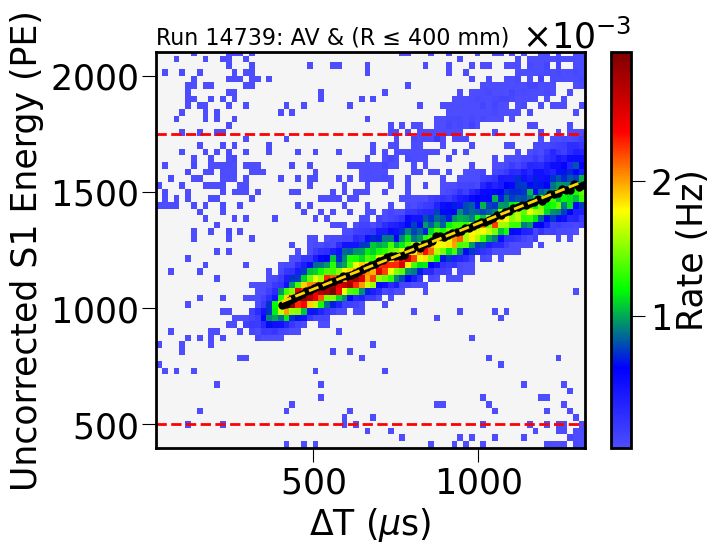

Run 14741 Fit: m = (0.57 ± 0.00) PE/μs, b = (795.20 ± 1.46) PE
χ² / ndof = 2.2537


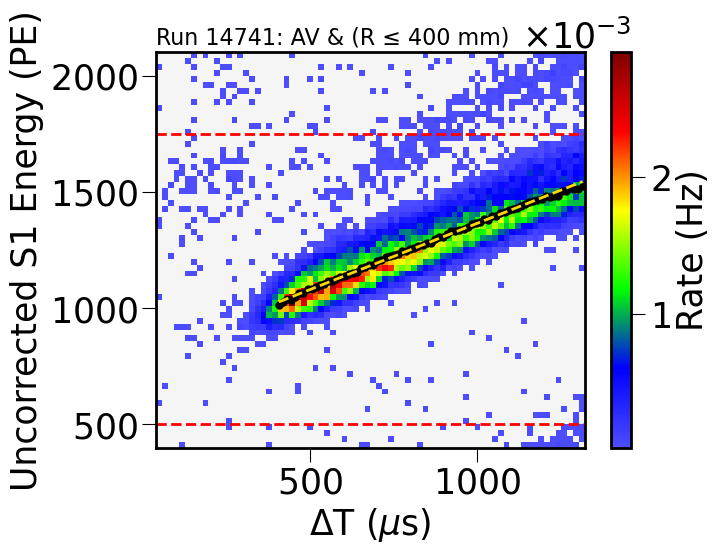

Run 14743 Fit: m = (0.57 ± 0.00) PE/μs, b = (794.70 ± 1.52) PE
χ² / ndof = 2.6609


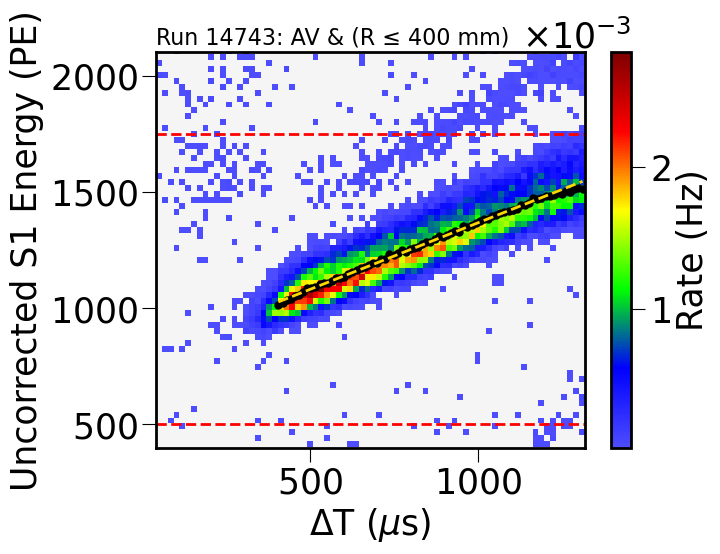

Run 14745 Fit: m = (0.57 ± 0.00) PE/μs, b = (796.95 ± 1.78) PE
χ² / ndof = 1.8820


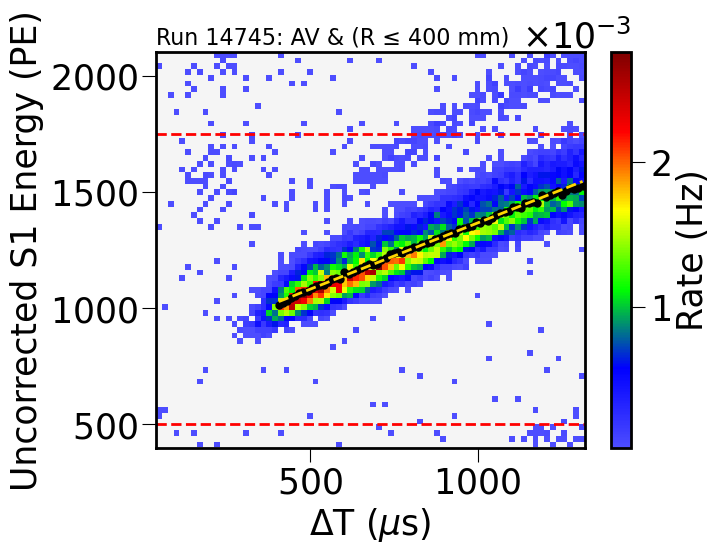

Run 14753 Fit: m = (0.57 ± 0.00) PE/μs, b = (795.32 ± 1.61) PE
χ² / ndof = 2.0783


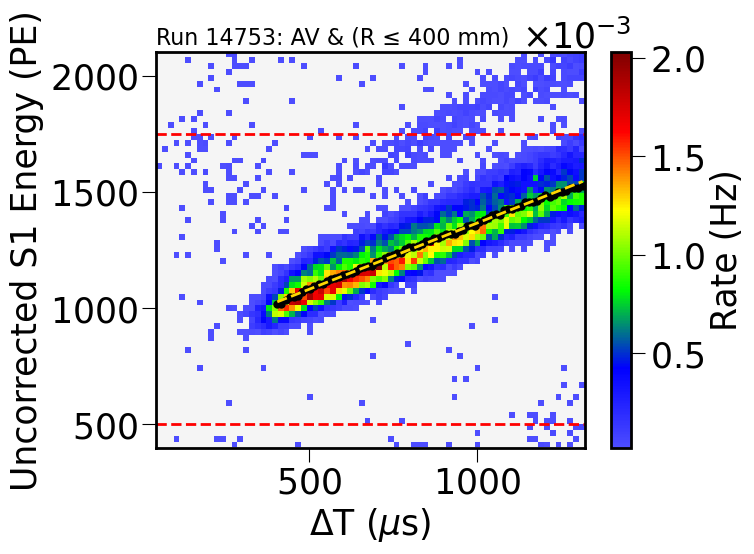

Run 14765 Fit: m = (0.53 ± 0.00) PE/μs, b = (829.13 ± 4.10) PE
χ² / ndof = 1.0793


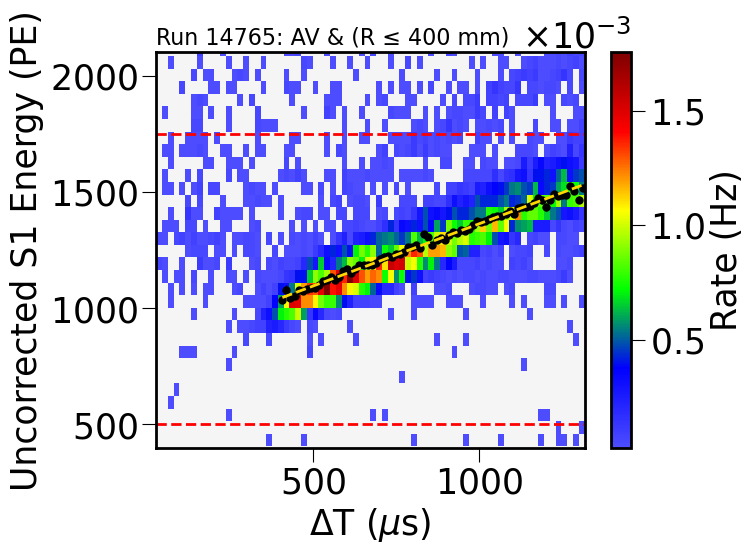

Run 14780 Fit: m = (0.56 ± 0.00) PE/μs, b = (835.96 ± 2.87) PE
χ² / ndof = 1.1536


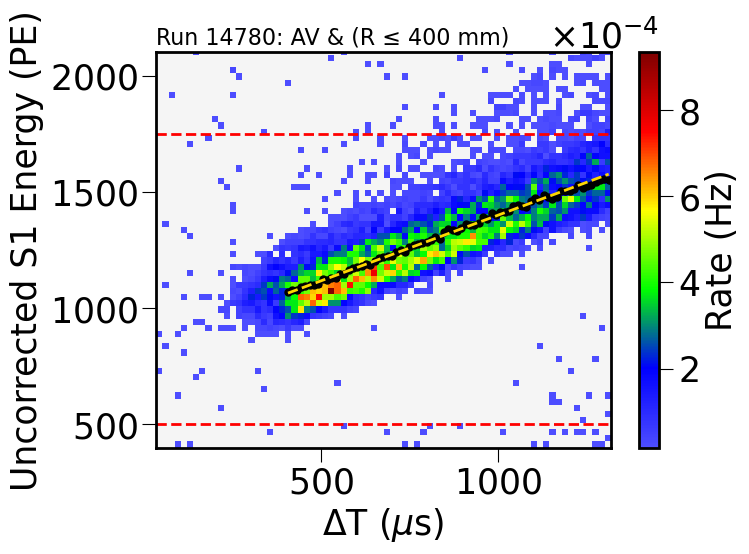

Run 14782 Fit: m = (0.58 ± 0.00) PE/μs, b = (795.10 ± 1.85) PE
χ² / ndof = 1.9721


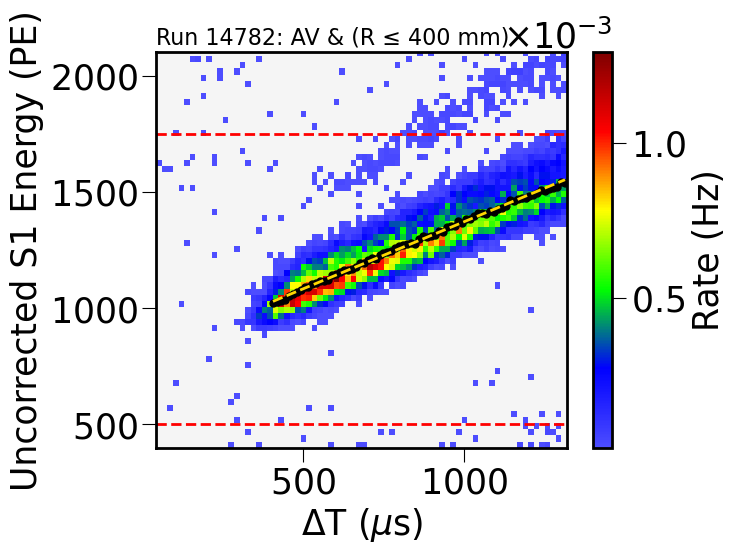

Run 14784 Fit: m = (0.57 ± 0.00) PE/μs, b = (798.71 ± 2.35) PE
χ² / ndof = 1.2479


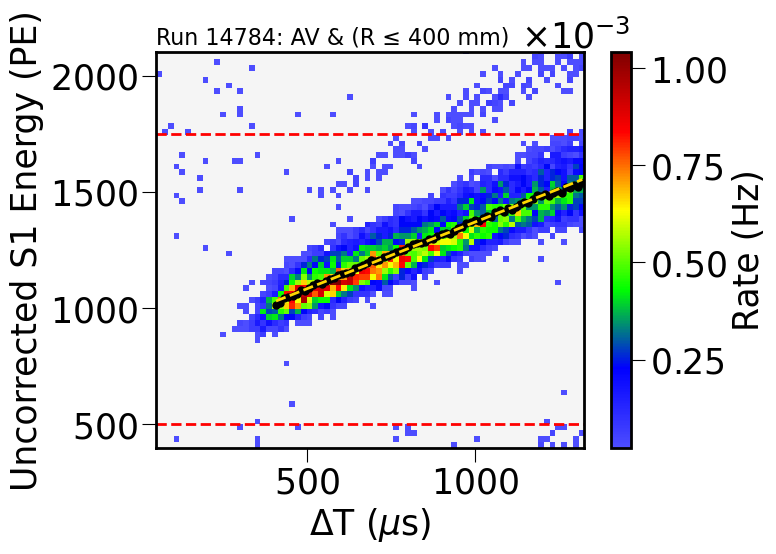

Run 14789 Fit: m = (0.58 ± 0.00) PE/μs, b = (795.51 ± 2.38) PE
χ² / ndof = 1.2913


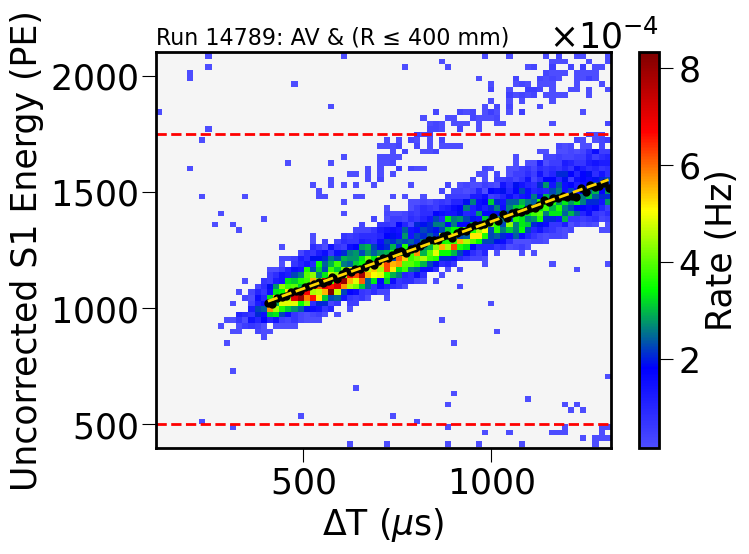

Run 14803 Fit: m = (0.50 ± 0.00) PE/μs, b = (699.88 ± 0.99) PE
χ² / ndof = 2.4466


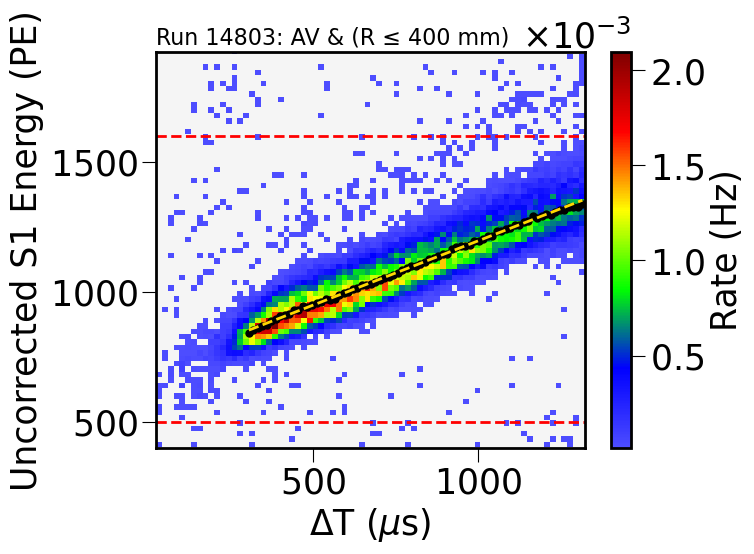

Run 14804 Fit: m = (0.50 ± 0.00) PE/μs, b = (699.94 ± 1.14) PE
χ² / ndof = 1.4258


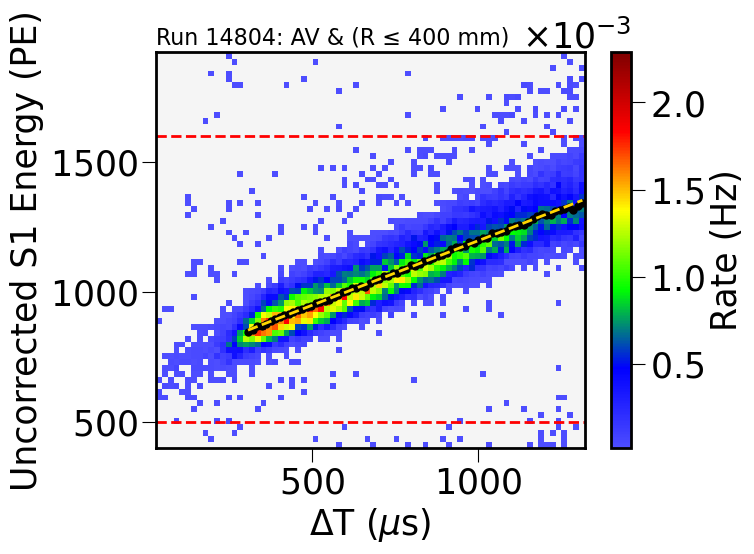

Run 14811 Fit: m = (0.49 ± 0.00) PE/μs, b = (700.72 ± 1.46) PE
χ² / ndof = 1.3355


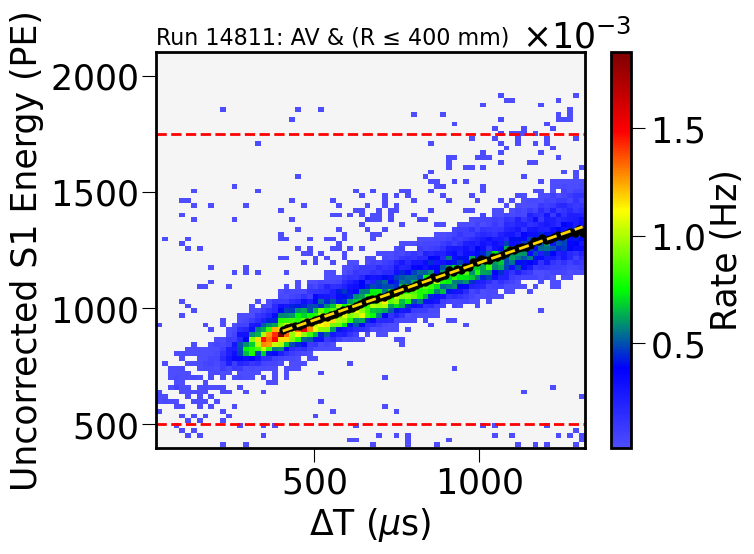

Run 14814 Fit: m = (0.49 ± 0.01) PE/μs, b = (700.33 ± 3.86) PE
χ² / ndof = 1.4695


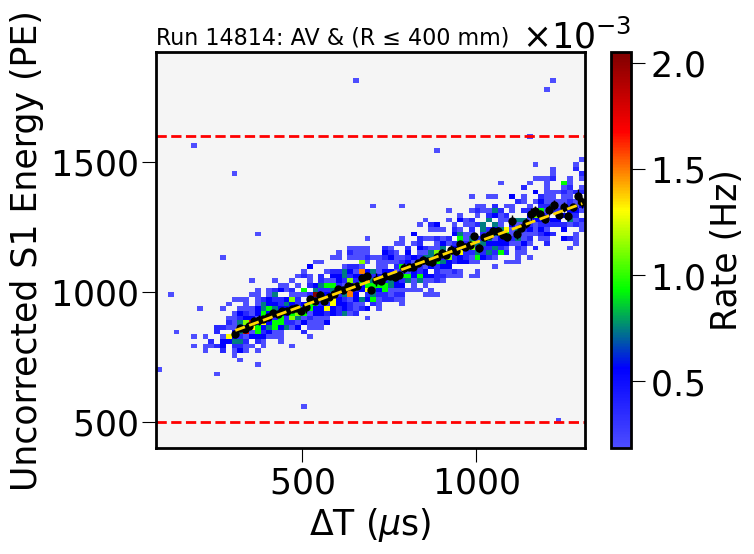

Run 14815 Fit: m = (0.50 ± 0.00) PE/μs, b = (697.47 ± 1.24) PE
χ² / ndof = 1.5860


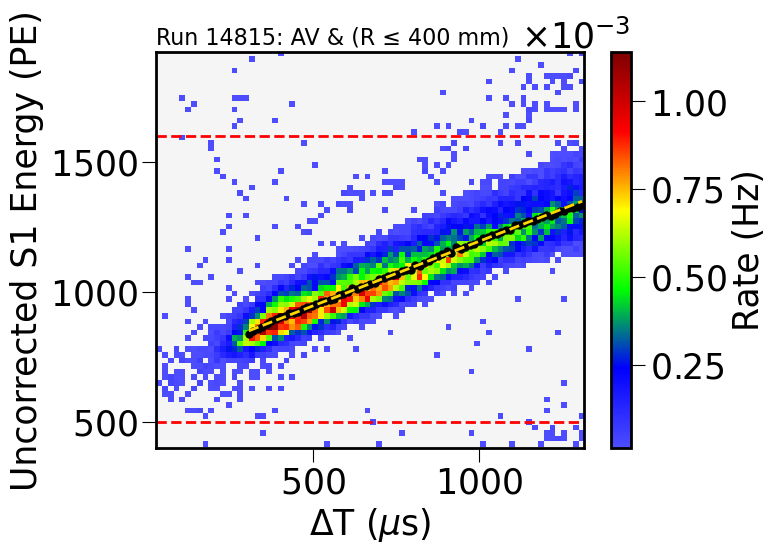

Run 14816 Fit: m = (0.49 ± 0.00) PE/μs, b = (699.75 ± 1.37) PE
χ² / ndof = 1.3509


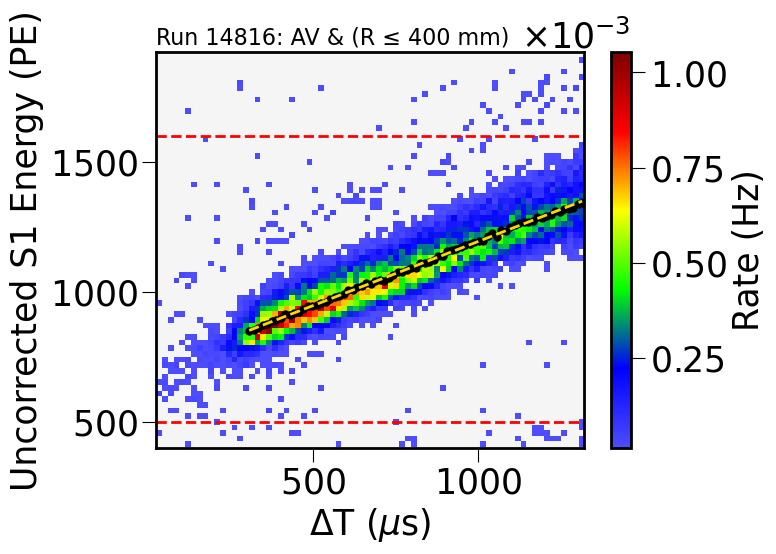

Run 14817 Fit: m = (0.49 ± 0.00) PE/μs, b = (699.96 ± 1.84) PE
χ² / ndof = 1.0837


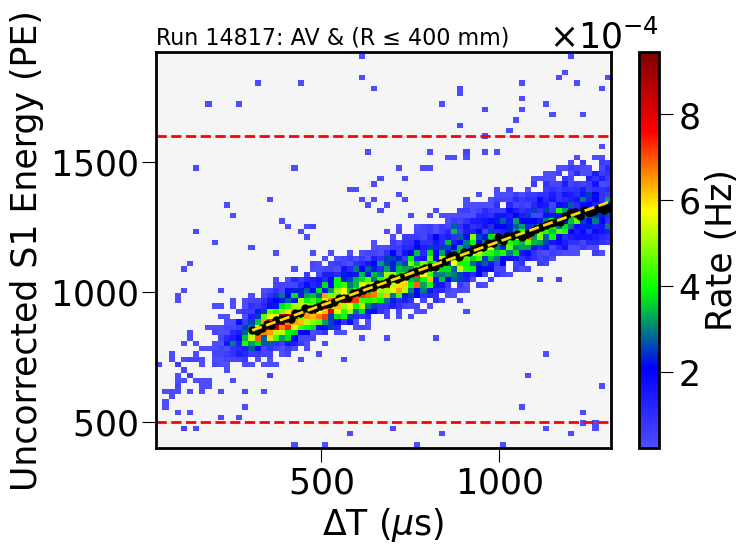

Run 14828 Fit: m = (0.50 ± 0.01) PE/μs, b = (694.12 ± 4.93) PE
χ² / ndof = 1.0750


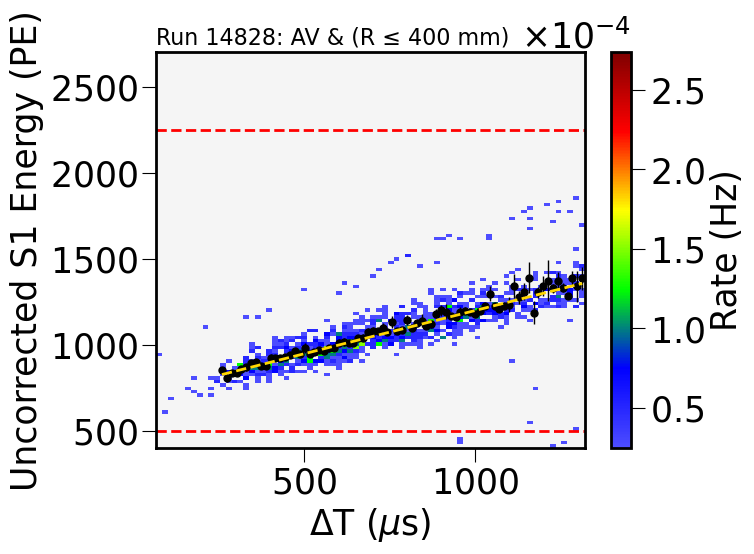

Run 14829 Fit: m = (0.60 ± 0.01) PE/μs, b = (884.87 ± 6.84) PE
χ² / ndof = 1.6737


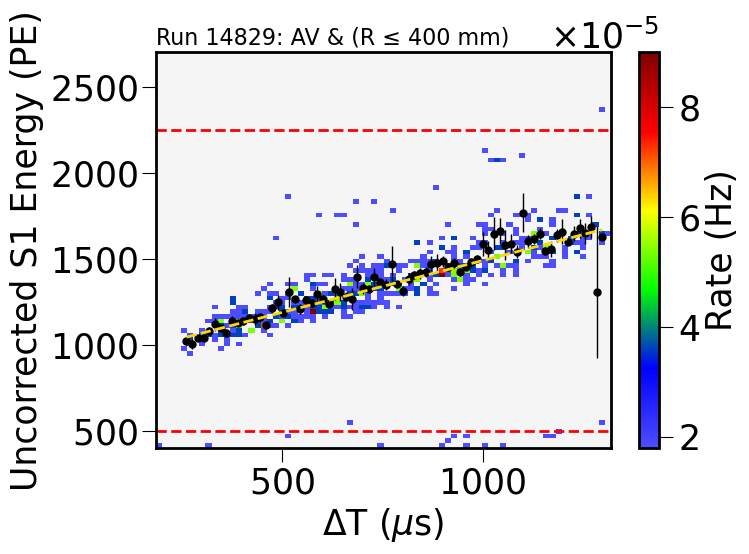

Run 14834 Fit: m = (0.71 ± 0.01) PE/μs, b = (790.45 ± 3.13) PE
χ² / ndof = 5.4379


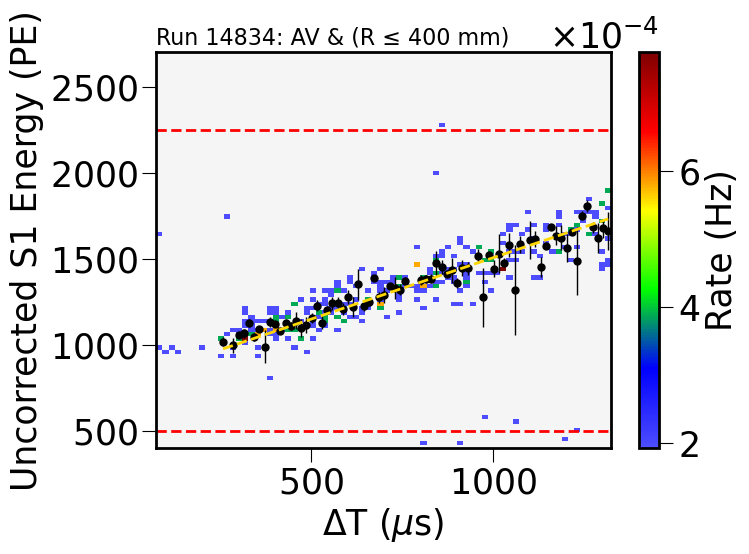

Run 14835 Fit: m = (0.64 ± 0.01) PE/μs, b = (858.64 ± 6.66) PE
χ² / ndof = 1.8514


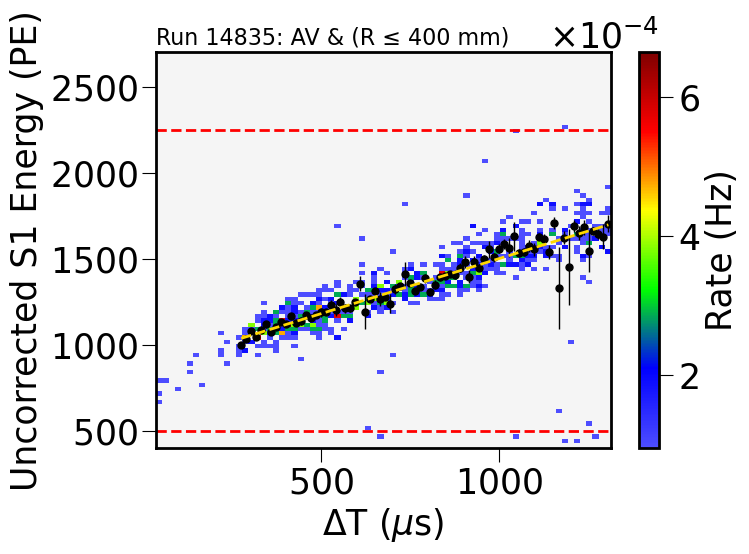

Run 14837 Fit: m = (0.62 ± 0.00) PE/μs, b = (878.64 ± 3.48) PE
χ² / ndof = 1.7596


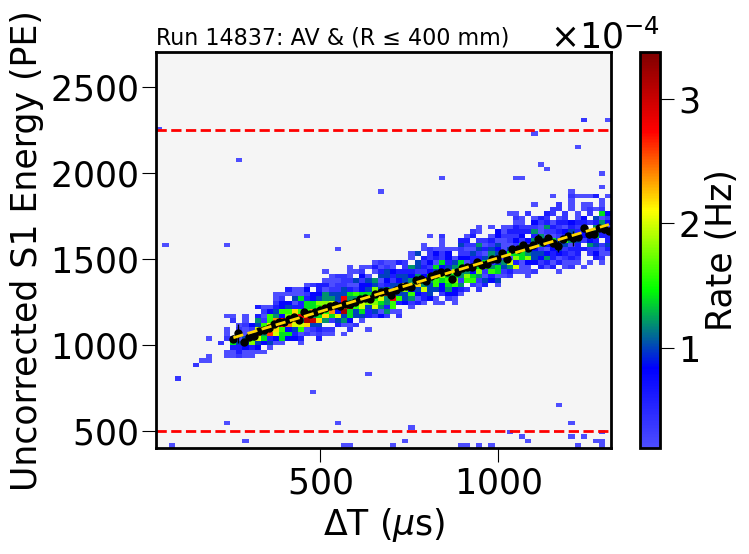

Run 14838 Fit: m = (0.62 ± 0.01) PE/μs, b = (879.39 ± 3.63) PE
χ² / ndof = 1.0782


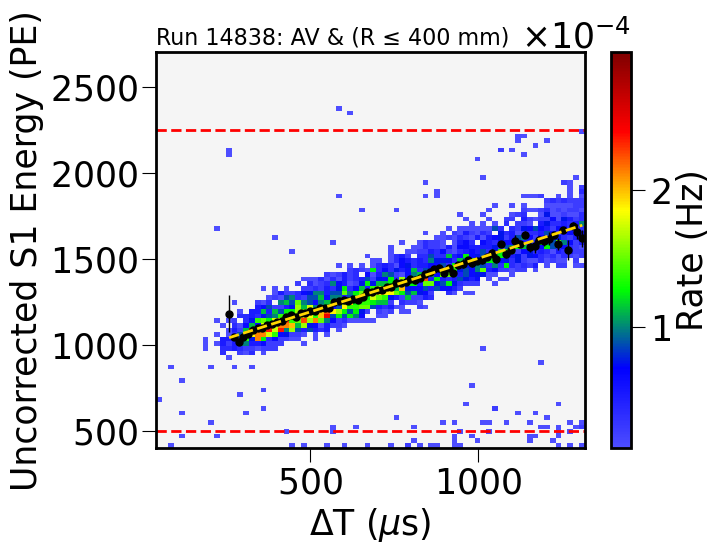

Run 14839 Fit: m = (0.64 ± 0.01) PE/μs, b = (871.25 ± 3.64) PE
χ² / ndof = 1.2073


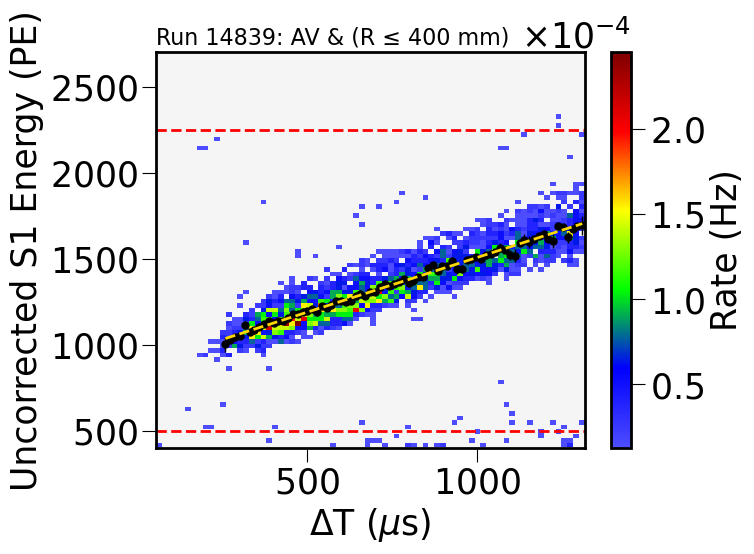

Run 14840 Fit: m = (0.62 ± 0.01) PE/μs, b = (879.86 ± 4.95) PE
χ² / ndof = 1.1224


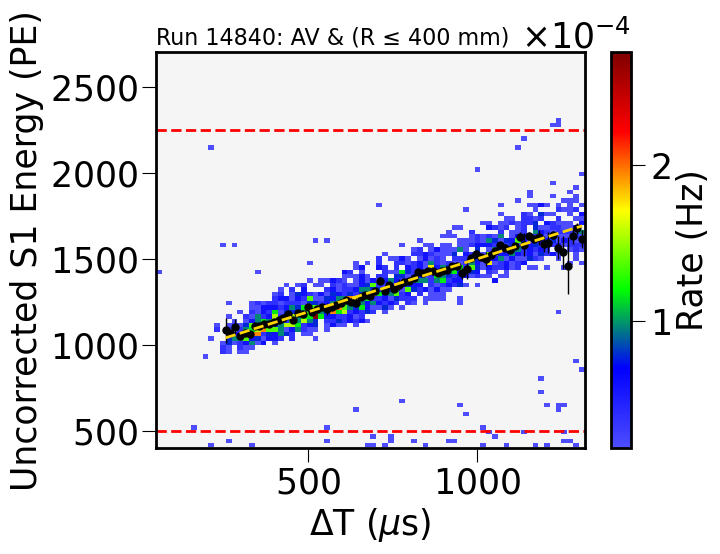

In [27]:
# Global
rad_lim = 400
n_bins  = 75

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    run_long = entry["duration"]
    run_OK   = entry["OK"]
    run_LOST = entry["LOST"]
    
    # DAQe efficiency + error
    DAQe_CV, DAQe_error = crudo.ff.efficiency(run_OK, run_LOST)

    # Variables    
    E1 = SEL_DATA[run_id]['S1e']
    DT = SEL_DATA[run_id]['DT']
    R  = SEL_DATA[run_id]['R']

    # Masking
    rad_mask = (R <= rad_lim)
    E1_mask  = E1[AV_mask[run_id] & rad_mask]
    DT_mask  = DT[AV_mask[run_id] & rad_mask]

    # 2D histogram: normalized by corrected DAQ data taking time
    S1e_DT_map, ex, ey = crudo.pt.hist_2D(DT_mask, E1_mask, x_bins=n_bins, y_bins=n_bins)
    S1e_DT_map         = S1e_DT_map / (run_long * DAQe_CV)                           
    S1e_DT_map         = np.ma.masked_where(S1e_DT_map==0, S1e_DT_map)                # Zero values masked

    # ----- Linear Fit ----- #
    # Preliminary
    DT_down = 400;    DT_up = DT_mask.max()
    E1_down = 500;    E1_up = 1750
    if run_id in {14803, 14804, 14814, 14815, 14816, 14817}:
        DT_down = 300;    DT_up = DT_mask.max()
        E1_down = 500;    E1_up = 1600
    if run_id in {14828, 14829, 14834, 14835, 14837, 14838, 14839, 14840}:
        DT_down = 250;    DT_up = DT_mask.max()
        E1_down = 500;    E1_up = 2250

    # Filter the data for the fit
    fit_region_mask = (DT_mask >= DT_down) & (DT_mask <= DT_up) & \
                      (E1_mask >= E1_down) & (E1_mask <= E1_up)
    DT_fit = DT_mask[fit_region_mask]
    E1_fit = E1_mask[fit_region_mask]

    # Compute representative values for the fit
    DT_centers, DT_errors, S1e_means, S1e_errors = crudo.ff.prefit_2D(DT_fit, E1_fit, bins=n_bins)
    # Filter out points with zero error (bins with 1 event)
    valid_points = S1e_errors > 0
    DT_centers = DT_centers[valid_points];      DT_errors  = DT_errors[valid_points]
    S1e_means  = S1e_means[valid_points];       S1e_errors = S1e_errors[valid_points]

    # Definte the cost function + initial guess
    least_squares = LeastSquares(DT_centers, S1e_means, S1e_errors, crudo.ff.linear_func)
    init_guess = [10, S1e_means.min()]
    # print(f'\nInitial guess: m = {init_guess[0]:.4f} PE/μs, b = {init_guess[1]:.4f} PE')

    # Define the Minuit object
    m = Minuit(least_squares, *init_guess)

    # Minimization process of the cost function and error estimation
    m.migrad()
    m.hesse()

    # Results
    popt = m.values;  perr = m.errors
    print(f'Run {run_id} Fit: m = ({popt[0]:.2f} ± {perr[0]:.2f}) PE/μs, b = ({popt[1]:.2f} ± {perr[1]:.2f}) PE')    
    FIT_PARAMETERS[run_id]["S1e"] = {"m_CV": popt[0], "m_err": perr[0], "b_CV": popt[1], "b_err": perr[1]}

    # Reduced chi-square
    chi2 = m.fval
    ndof = len(DT_centers) - m.nfit
    print(f"χ² / ndof = {chi2 / ndof:.4f}")

    # ----- Plotting ----- #
    plt.figure(figsize=(8, 6))

    # Data
    plt.pcolormesh(ex, ey, S1e_DT_map.T, cmap=crudo.pt.custom_hsv, shading='auto')    
    cbar = plt.colorbar(label='Rate (Hz)', shrink=1.0)
    # cbar.formatter.set_powerlimits((-3, -3))

    # Fit
    fit_y = crudo.ff.linear_func(DT_centers, *popt)
    plt.errorbar(DT_centers, S1e_means, xerr=DT_errors, yerr=S1e_errors, fmt='o', c='black', ecolor='black', lw=1.0, markersize=5)
    plt.plot(DT_centers, fit_y, c='gold', ls='--', zorder=3)
    plt.axhline(y=E1_up, c='red', ls='--')
    plt.axhline(y=E1_down, c='red', ls='--')

    # ----- Styling ----- #
    plt.xlabel('$\Delta$T ($\mu$s)')
    plt.ylabel('Uncorrected S1 Energy (PE)')
    plt.ylim(0.8*E1_down, 1.2*E1_up)
    plt.title(f'Run {run_id}: AV & (R ≤ {rad_lim} mm)', fontsize=16, loc='left')

    plt.gca().set_facecolor("whitesmoke")
    # plt.savefig(f'/lhome/ific/c/ccortesp/Analysis/NEXT-100/Rn_analysis/images/S1e_DT_fit_run{run_id}.pdf')
    plt.tight_layout()
    plt.show() 

### $S2e$ vs DT: Lifetime

Run 14714 fit: N0 = (826859.27 ± 708.86) PE, τ = (48.32 ± 2.32) ms
χ² / ndof = 1.7875


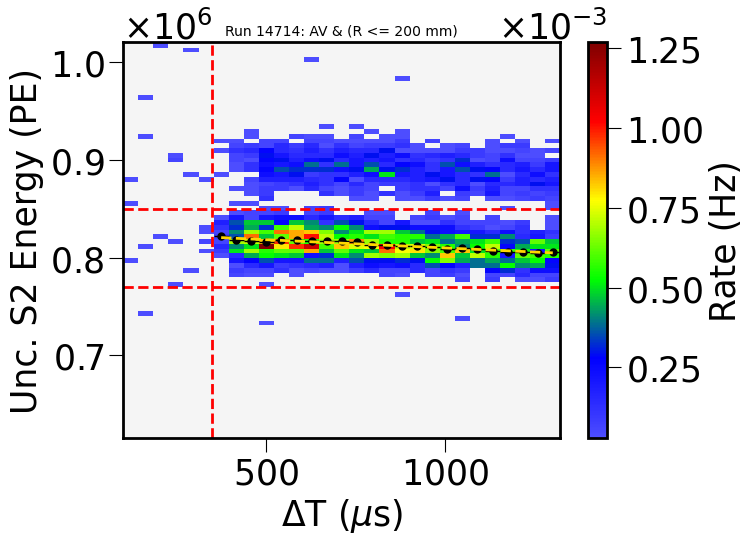

Run 14716 fit: N0 = (834447.92 ± 2163.16) PE, τ = (39.09 ± 4.45) ms
χ² / ndof = 1.2932


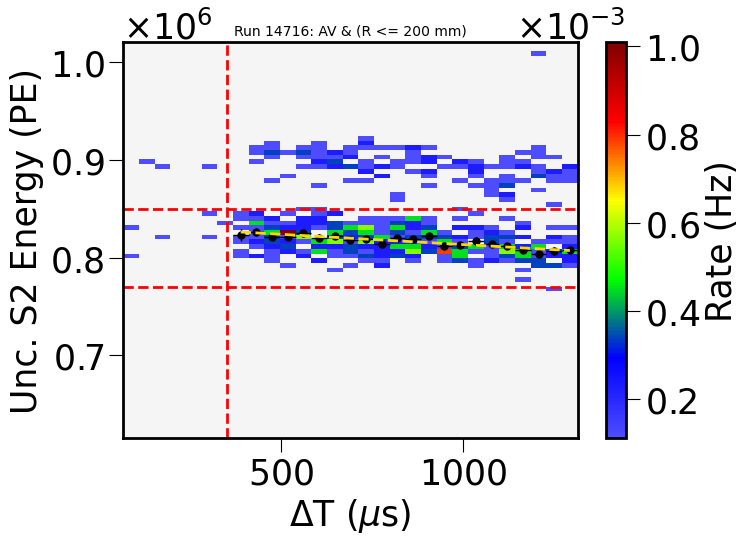

Run 14720 fit: N0 = (827570.08 ± 1259.98) PE, τ = (57.50 ± 5.79) ms
χ² / ndof = 1.3491


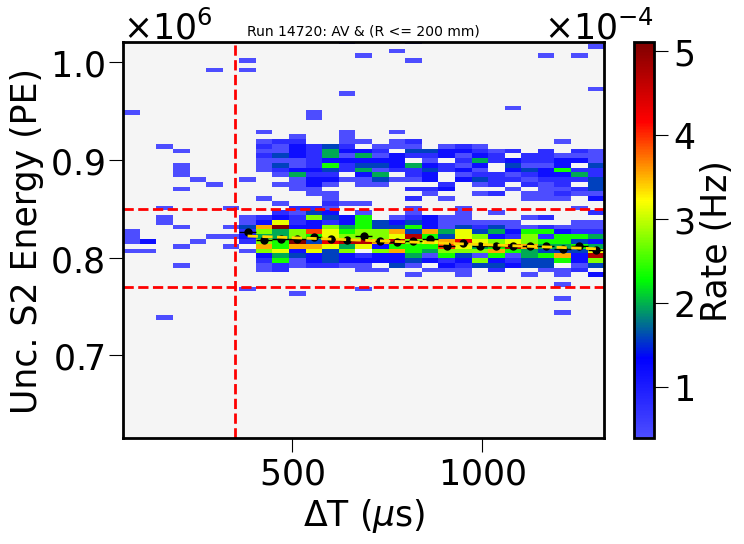

Run 14733 fit: N0 = (824808.94 ± 871.94) PE, τ = (61.65 ± 4.80) ms
χ² / ndof = 1.4519


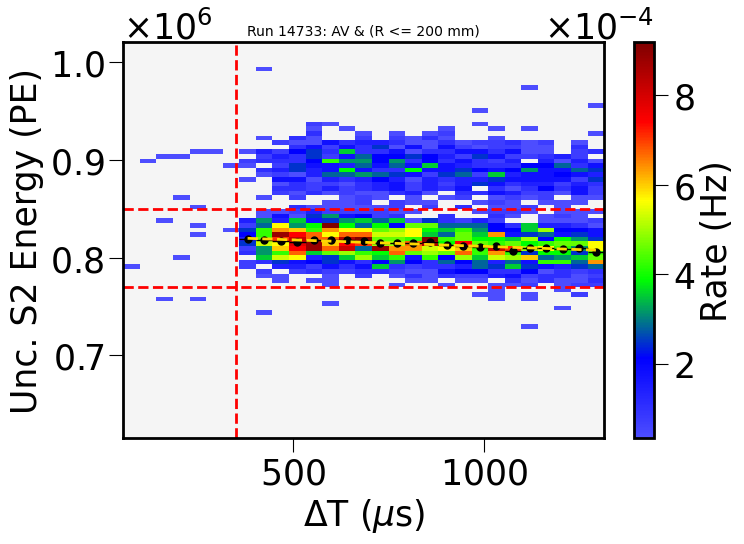

Run 14735 fit: N0 = (826717.99 ± 672.75) PE, τ = (50.26 ± 2.44) ms
χ² / ndof = 3.1107


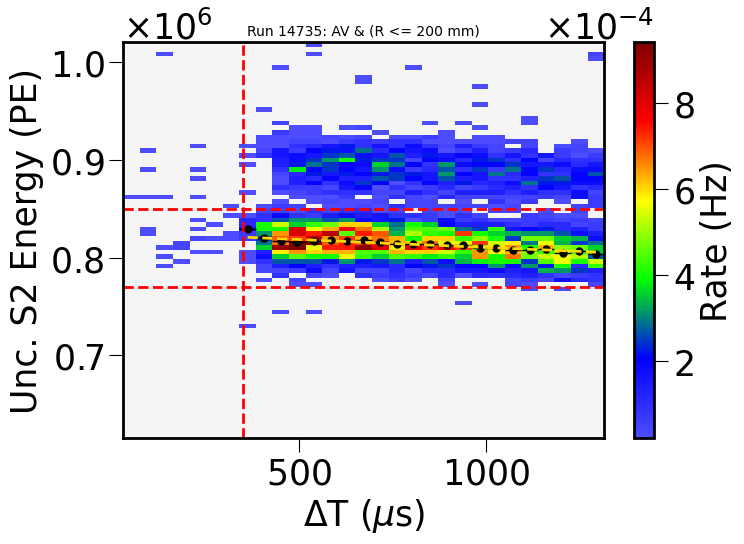

Run 14737 fit: N0 = (830405.09 ± 649.49) PE, τ = (59.22 ± 3.14) ms
χ² / ndof = 1.5849


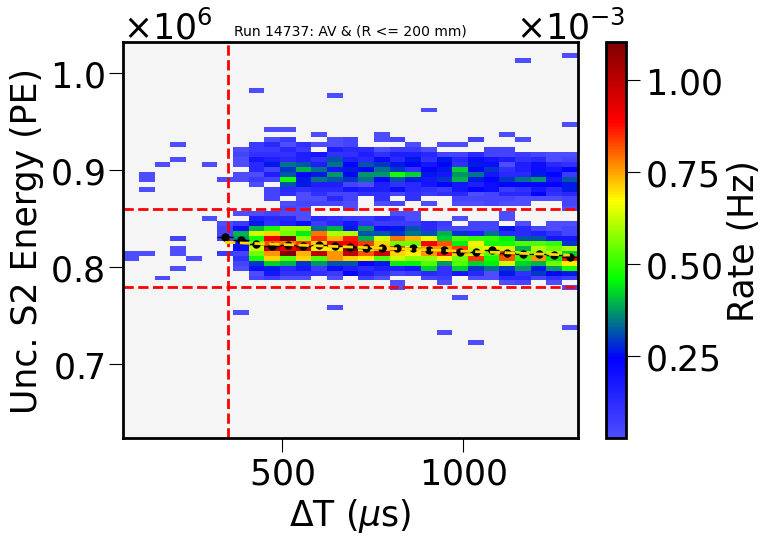

Run 14739 fit: N0 = (831950.76 ± 618.15) PE, τ = (55.77 ± 2.63) ms
χ² / ndof = 2.5716


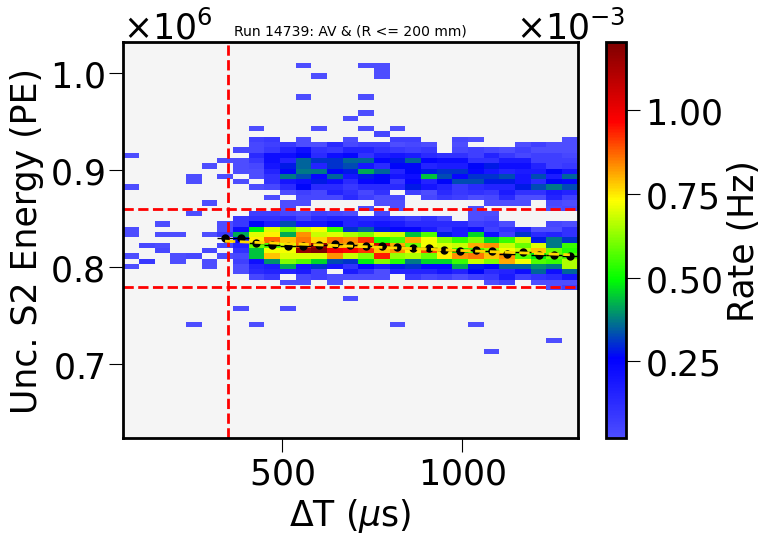

Run 14741 fit: N0 = (831307.76 ± 601.70) PE, τ = (59.00 ± 2.90) ms
χ² / ndof = 2.4020


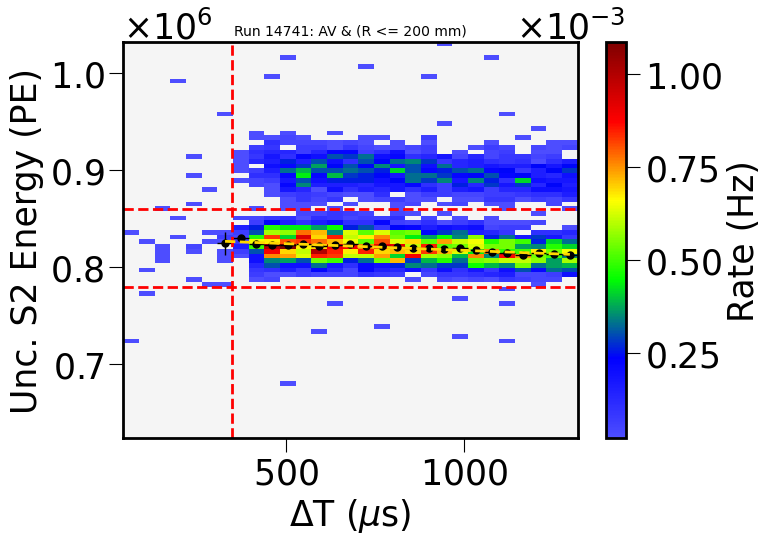

Run 14743 fit: N0 = (830964.25 ± 617.87) PE, τ = (63.14 ± 3.34) ms
χ² / ndof = 2.5796


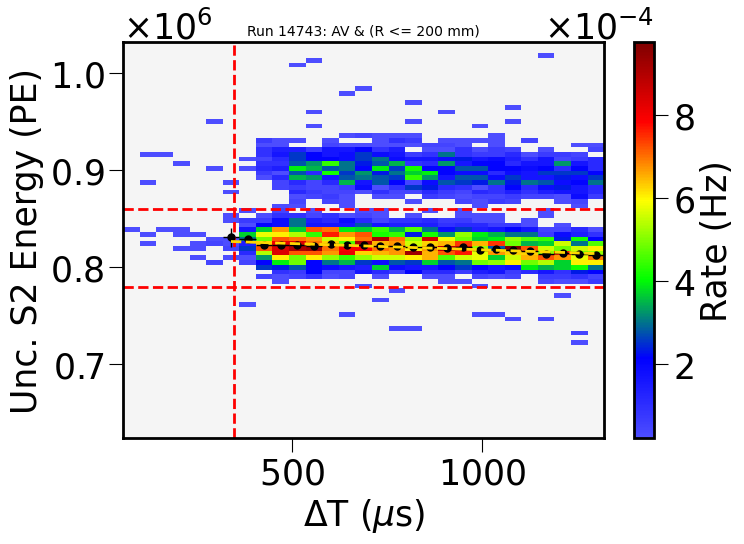

Run 14745 fit: N0 = (832503.57 ± 716.07) PE, τ = (56.95 ± 3.14) ms
χ² / ndof = 0.9857


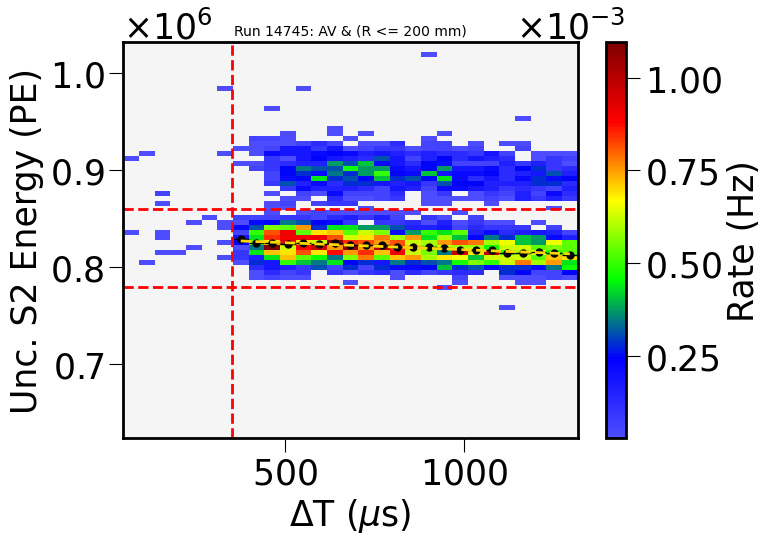

Run 14753 fit: N0 = (832588.15 ± 777.58) PE, τ = (50.41 ± 2.82) ms
χ² / ndof = 1.9809


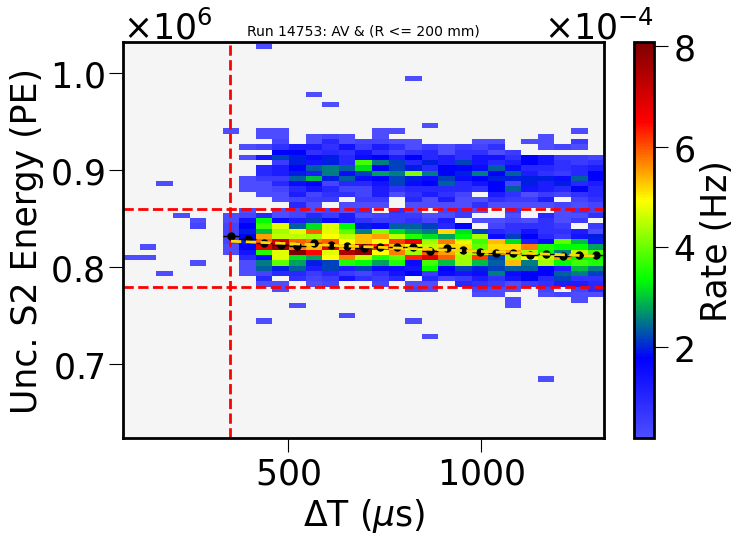

Run 14765 fit: N0 = (835751.57 ± 1264.86) PE, τ = (45.75 ± 3.65) ms
χ² / ndof = 0.7365


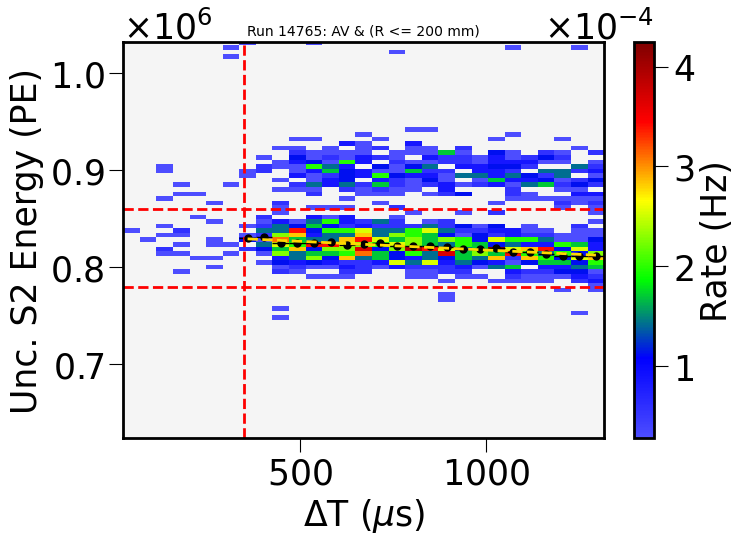

Run 14780 fit: N0 = (838290.62 ± 1043.68) PE, τ = (45.51 ± 2.92) ms
χ² / ndof = 1.7822


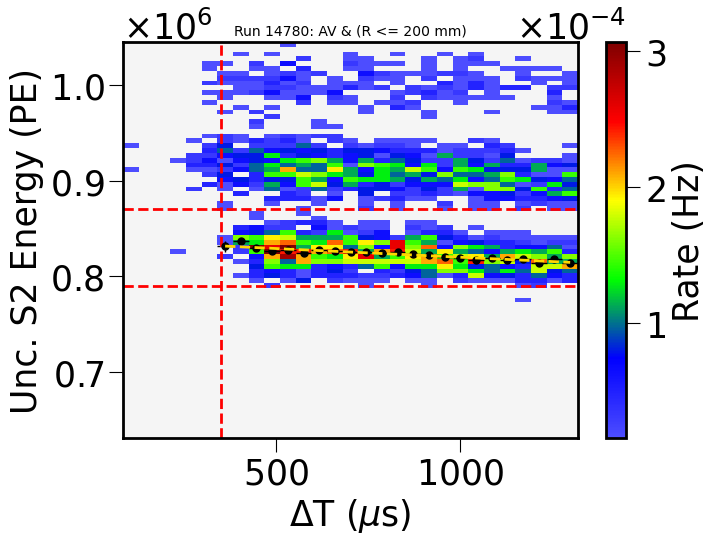

Run 14782 fit: N0 = (839496.22 ± 829.55) PE, τ = (50.14 ± 2.87) ms
χ² / ndof = 1.5512


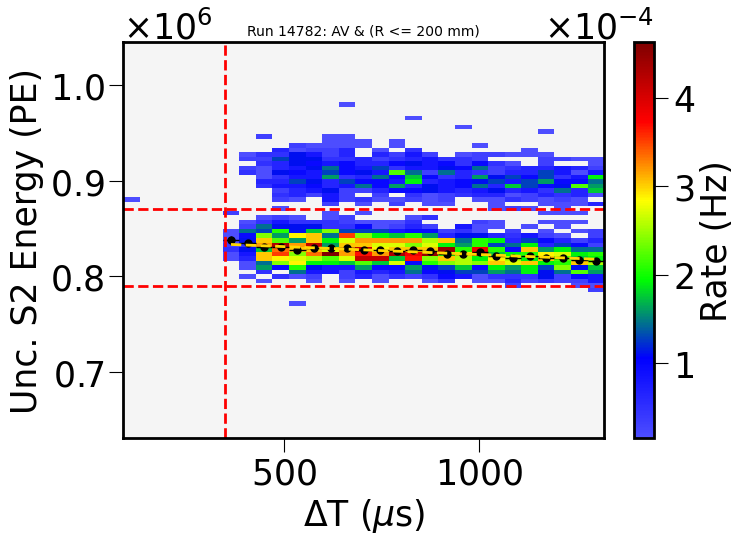

Run 14784 fit: N0 = (840941.13 ± 1016.57) PE, τ = (43.24 ± 2.56) ms
χ² / ndof = 1.3611


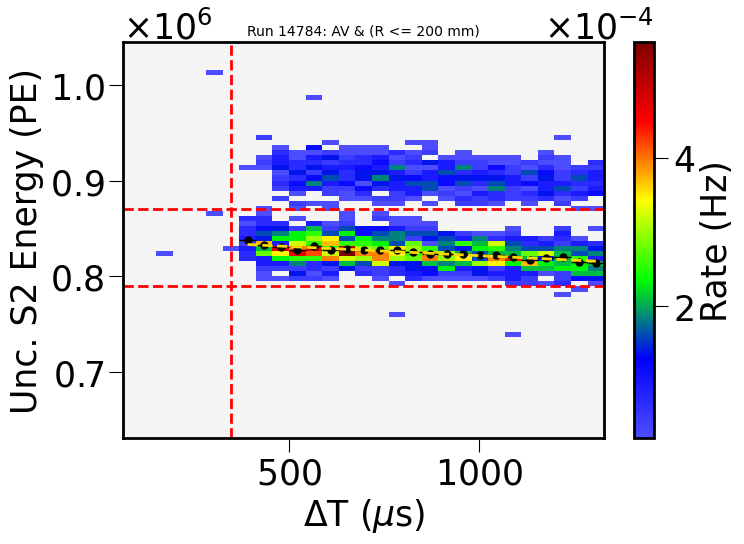

Run 14789 fit: N0 = (838799.02 ± 1032.17) PE, τ = (46.42 ± 3.02) ms
χ² / ndof = 0.7195


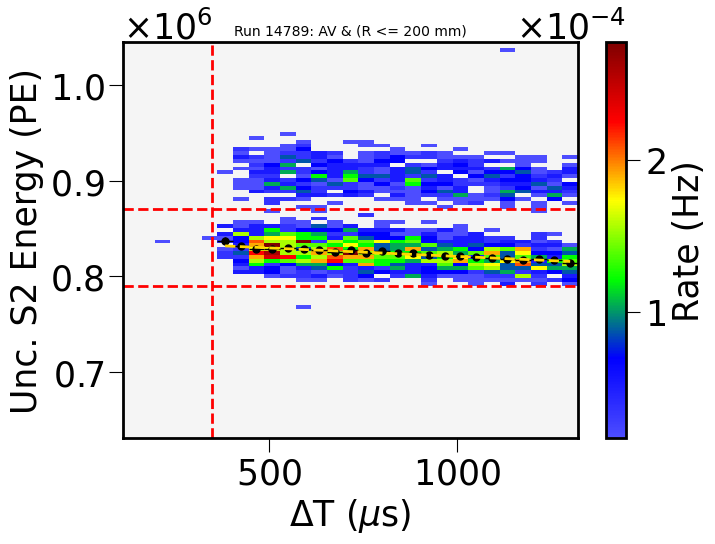

Run 14803 fit: N0 = (730928.90 ± 476.54) PE, τ = (78.51 ± 5.08) ms
χ² / ndof = 7.8092


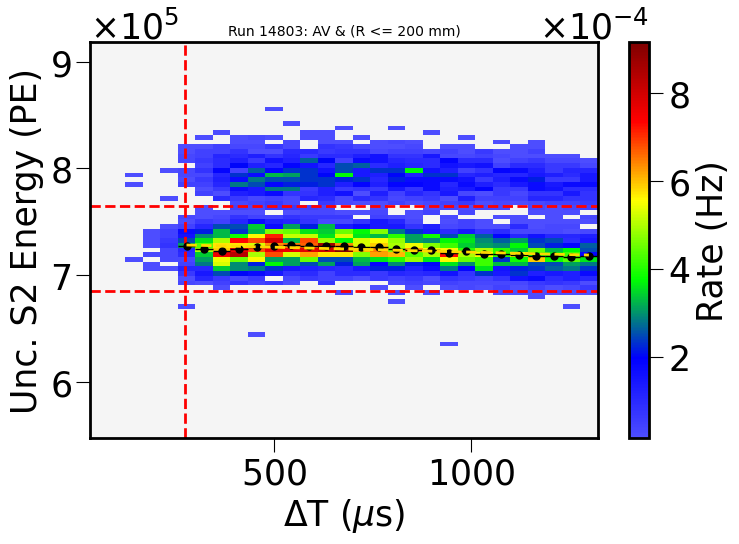

Run 14804 fit: N0 = (731339.42 ± 541.67) PE, τ = (84.20 ± 6.49) ms
χ² / ndof = 10.0409


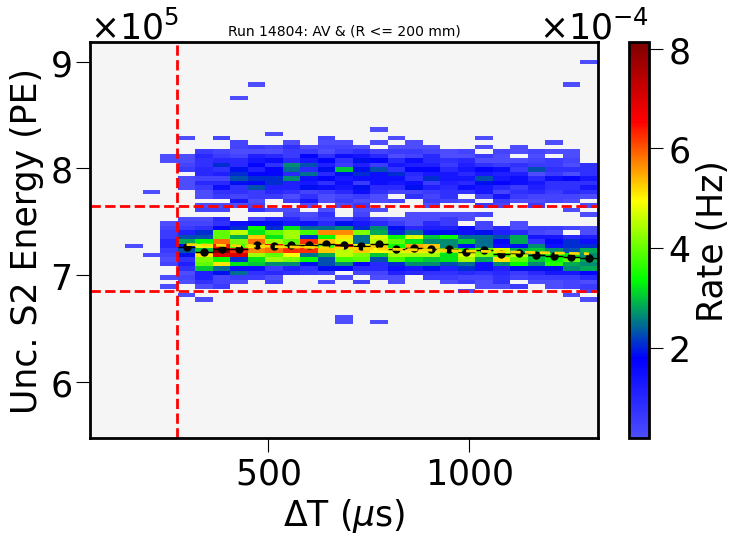

Run 14811 fit: N0 = (731006.00 ± 489.61) PE, τ = (102.02 ± 8.52) ms
χ² / ndof = 6.7507


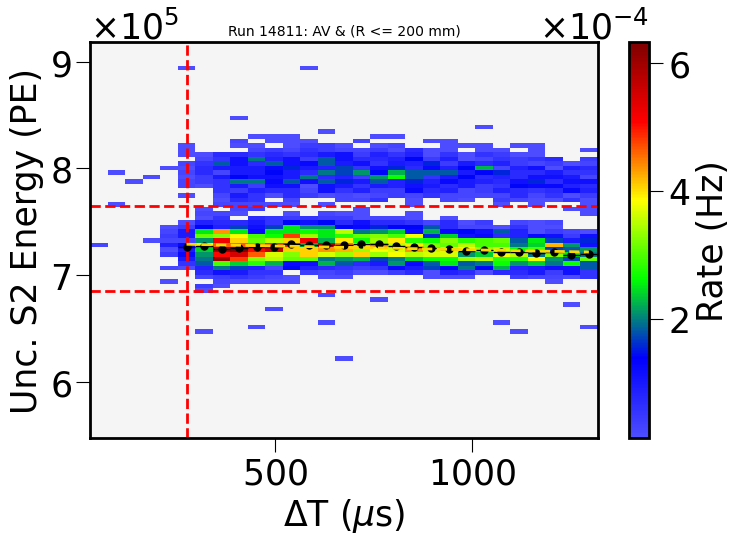

Run 14814 fit: N0 = (729476.29 ± 1934.35) PE, τ = (101.86 ± 32.07) ms
χ² / ndof = 1.6447


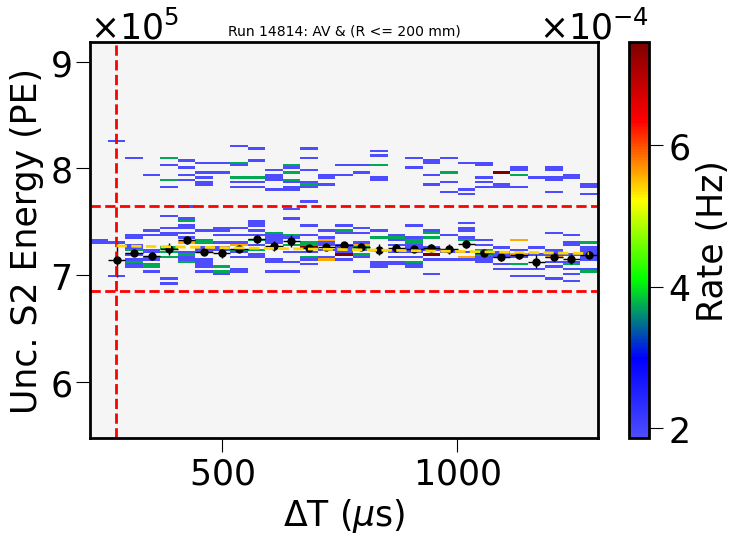

Run 14815 fit: N0 = (731420.51 ± 534.69) PE, τ = (97.58 ± 8.43) ms
χ² / ndof = 8.9329


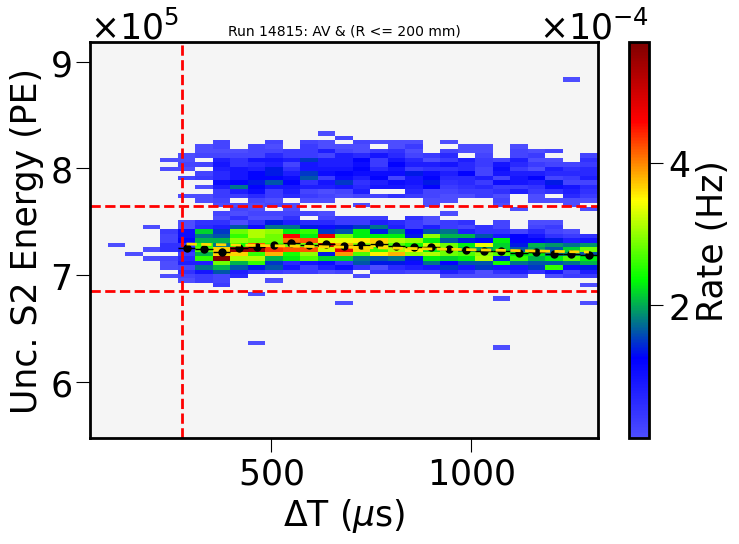

Run 14816 fit: N0 = (731008.12 ± 587.60) PE, τ = (115.66 ± 13.02) ms
χ² / ndof = 4.5645


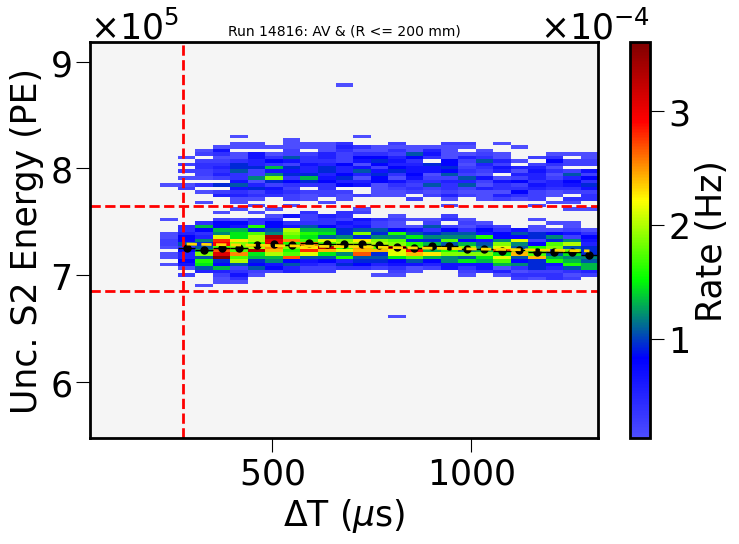

Run 14817 fit: N0 = (732025.68 ± 816.22) PE, τ = (102.60 ± 14.27) ms
χ² / ndof = 3.9897


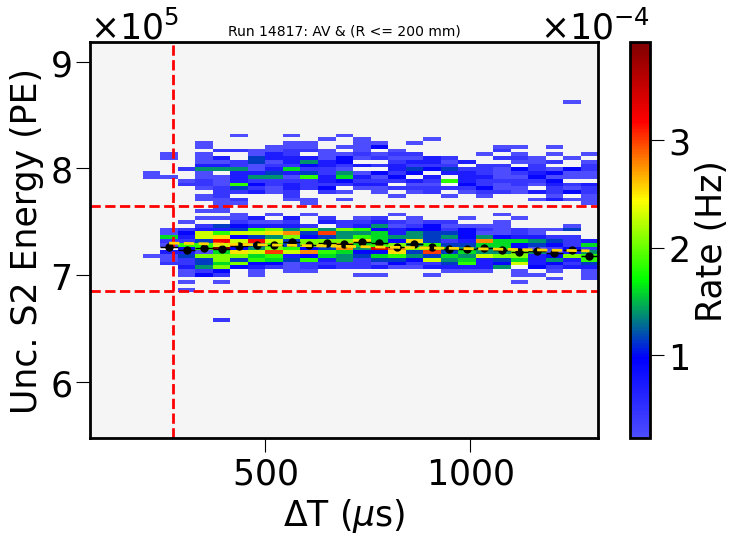

Run 14828 fit: N0 = (731280.55 ± 2204.67) PE, τ = (76.48 ± 20.50) ms
χ² / ndof = 1.5172


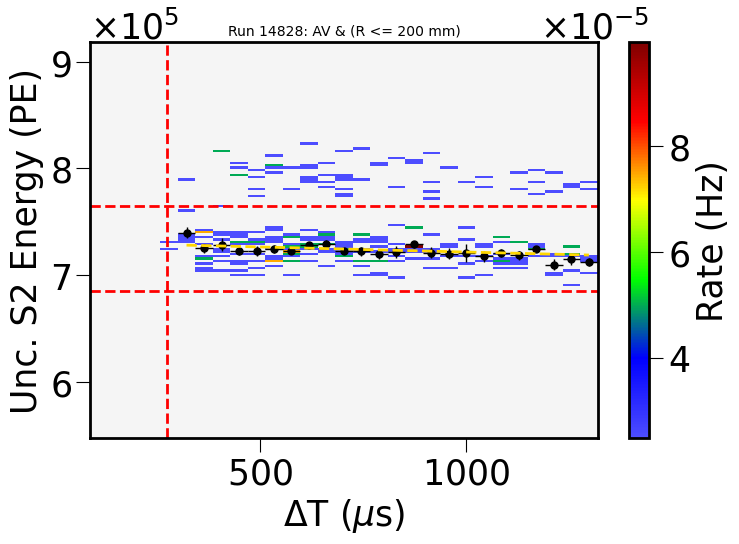

Run 14829 fit: N0 = (943712.01 ± 2482.36) PE, τ = (37.25 ± 4.37) ms
χ² / ndof = 7.2553


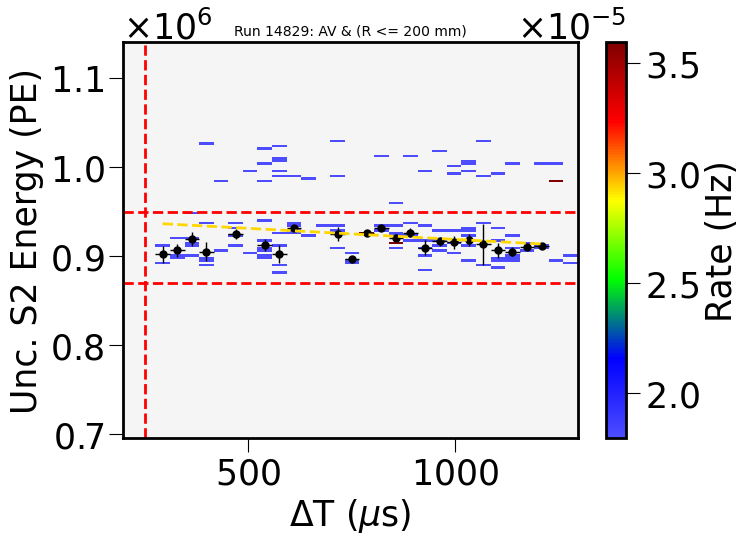

Run 14834 fit: N0 = (933636.55 ± 3795.62) PE, τ = (101.85 ± 39.80) ms
χ² / ndof = 7.3479


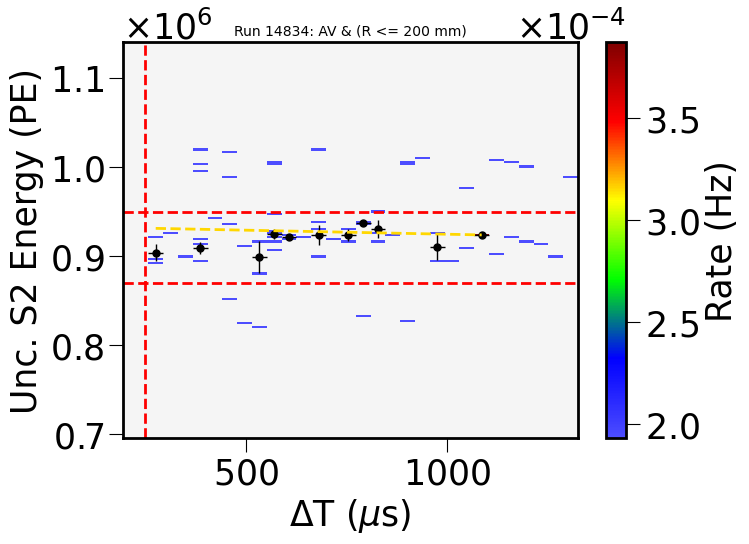

Run 14835 fit: N0 = (933004.75 ± 2976.39) PE, τ = (40.26 ± 5.13) ms
χ² / ndof = 2.5494


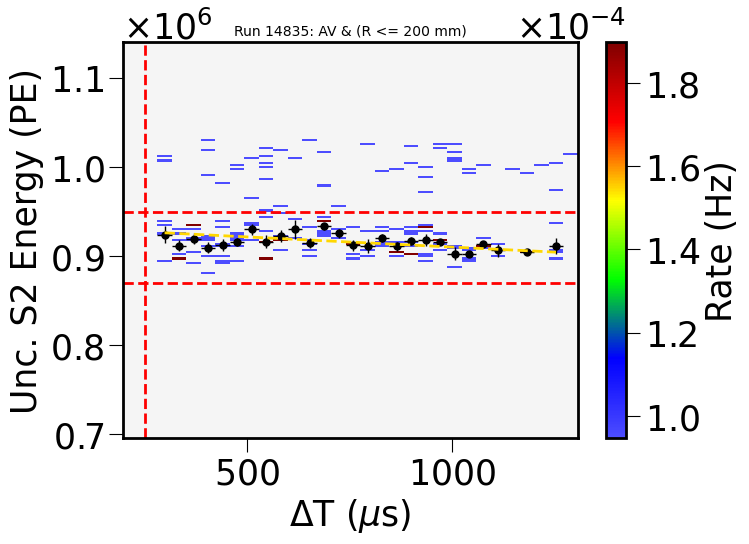

Run 14837 fit: N0 = (921855.05 ± 1852.06) PE, τ = (64.21 ± 10.13) ms
χ² / ndof = 1.4313


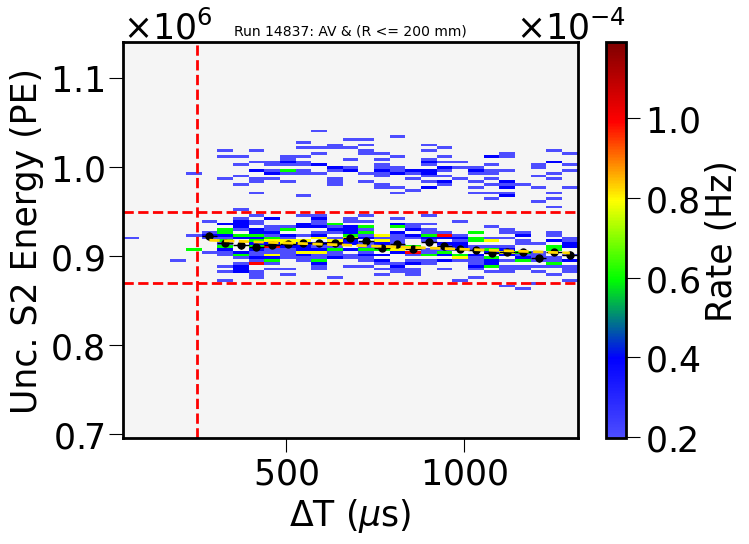

Run 14838 fit: N0 = (920062.33 ± 1512.21) PE, τ = (103.29 ± 20.73) ms
χ² / ndof = 2.2270


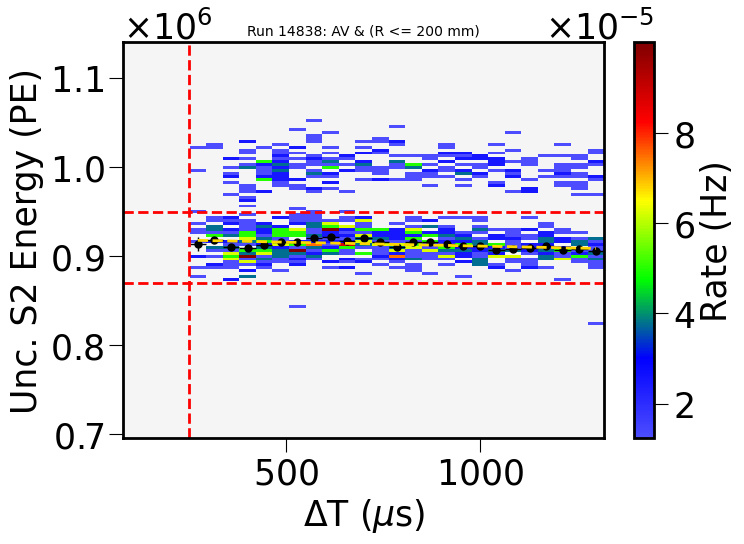

Run 14839 fit: N0 = (924914.90 ± 1509.67) PE, τ = (70.30 ± 9.67) ms
χ² / ndof = 2.6974


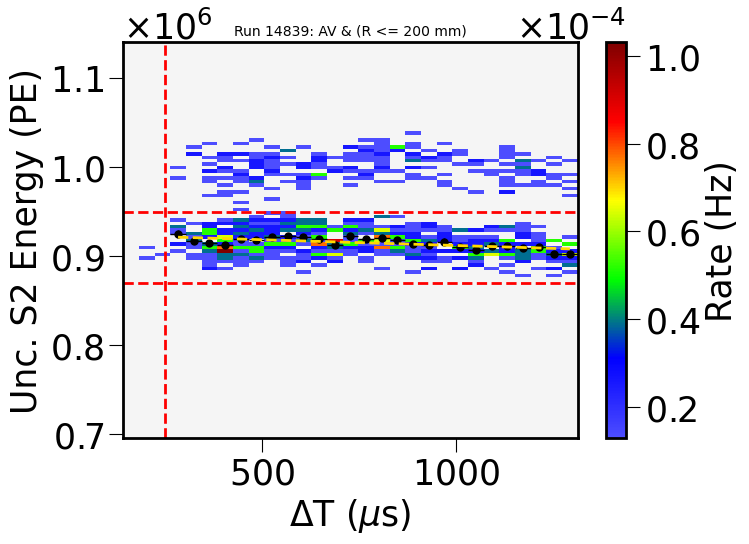

Run 14840 fit: N0 = (921111.11 ± 1752.67) PE, τ = (104.80 ± 27.19) ms
χ² / ndof = 1.7997


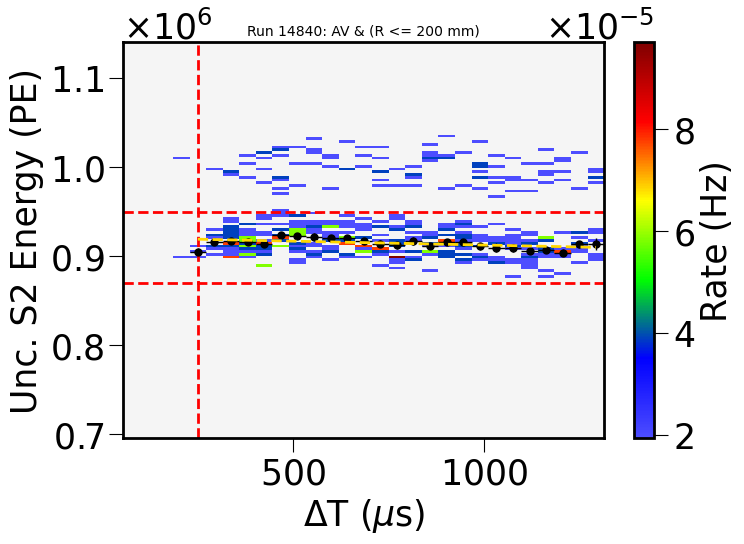

In [28]:
# Global
rad_lim = 200
x_bins  = 30
y_bins  = 400

# Use exponential decay function with b = 0
def exp_bfixed(x, N0, tau):
    return crudo.ff.exponential_decay(x, N0, tau, 0)

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    run_long = entry["duration"]
    run_OK   = entry["OK"]
    run_LOST = entry["LOST"]
    
    # DAQe efficiency + error
    DAQe_CV, DAQe_error = crudo.ff.efficiency(run_OK, run_LOST)
        
    # Variables    
    E2 = SEL_DATA[run_id]['S2e']
    DT = SEL_DATA[run_id]['DT']
    R  = SEL_DATA[run_id]['R']

    # Masking
    rad_mask = (R <= rad_lim)
    E2_mask  = E2[AV_mask[run_id] & rad_mask]
    DT_mask  = DT[AV_mask[run_id] & rad_mask]

    # 2D histogram: normalized by corrected DAQ data taking time
    S2e_DT_map, ex, ey = crudo.pt.hist_2D(DT_mask, E2_mask, x_bins=x_bins, y_bins=y_bins)
    S2e_DT_map         = S2e_DT_map / (run_long * DAQe_CV)                           
    S2e_DT_map         = np.ma.masked_where(S2e_DT_map==0, S2e_DT_map)                # Zero values masked
    
    # ---- Exponential Fit ----- #
    # Preliminary
    DT_down = 350;    DT_up = DT_mask.max()
    E2_down = 770e3;  E2_up = 850e3
    if run_id in {14737, 14739, 14741, 14743, 14745, 14753, 14765}:
        E2_down = 780e3;  E2_up = 860e3
    if run_id in {14780, 14782, 14784, 14789}:
        E2_down = 790e3;  E2_up = 870e3
    if run_id in {14803, 14804, 14811, 14814, 14815, 14816, 14817, 14828}:
        DT_down = 275;    DT_up = DT_mask.max()
        E2_down = 685e3;  E2_up = 765e3
    elif run_id in {14829, 14834, 14835, 14837, 14838, 14839, 14840}:
        DT_down = 250;    DT_up = DT_mask.max()
        E2_down = 870e3;  E2_up = 950e3

    # Filter the data for the fit
    fit_region_mask = (DT_mask >= DT_down) & (DT_mask <= DT_up) & \
                      (E2_mask >= E2_down) & (E2_mask <= E2_up)
    DT_fit = DT_mask[fit_region_mask]
    E2_fit = E2_mask[fit_region_mask]

    # Compute representative values for the fit
    DT_centers, DT_errors, S2e_means, S2e_errors = crudo.ff.prefit_2D(DT_fit, E2_fit, bins=ex)
    # Filter out points with zero error (bins with 1 event)
    valid_points = S2e_errors > 0
    DT_centers = DT_centers[valid_points];      DT_errors  = DT_errors[valid_points]
    S2e_means  = S2e_means[valid_points];       S2e_errors = S2e_errors[valid_points]

    # Definte the cost function + initial guess
    least_squares = LeastSquares(DT_centers, S2e_means, S2e_errors, exp_bfixed)
    init_guess = [S2e_means.max(), (DT_centers.max() - DT_centers.min()) / 2]
    # print(f'\nInitial guess: N0 = {init_guess[0]:.4f} PE, tau = {init_guess[1]:.4f} μs')

    # Define the Minuit object
    m = Minuit(least_squares, *init_guess)

    # Minimization process of the cost function and error estimation
    m.migrad()
    m.hesse()

    # Results
    popt = m.values;  perr = m.errors
    print(f'Run {run_id} fit: N0 = ({popt[0]:.2f} ± {perr[0]:.2f}) PE, τ = ({popt[1] / 1e3:.2f} ± {perr[1] / 1e3:.2f}) ms')
    FIT_PARAMETERS[run_id]["S2e"] = {"N0_CV": popt[0], "N0_err": perr[0], "tau_CV": popt[1], "tau_err": perr[1]}
    
    # Reduced chi-square
    chi2 = m.fval
    ndof = len(DT_centers) - m.nfit
    print(f"χ² / ndof = {chi2 / ndof:.4f}")

    # ----- Plotting ----- #
    plt.figure(figsize=(8, 6))

    # Data
    plt.pcolormesh(ex, ey, S2e_DT_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
    cbar = plt.colorbar(label='Rate (Hz)', shrink=1.0)
    # cbar.formatter.set_powerlimits((-3, -3))

    # Fit
    fit_y = exp_bfixed(DT_centers, *popt)
    plt.errorbar(DT_centers, S2e_means, xerr=DT_errors, yerr=S2e_errors, fmt='o', c='black', ecolor='black', lw=1.0, markersize=5)
    plt.plot(DT_centers, fit_y, c='gold', ls='--', zorder=3)
    plt.axvline(x=DT_down, c='red', ls='--')
    plt.axhline(y=E2_down, c='red', ls='--')
    plt.axhline(y=E2_up, c='red', ls='--')

    # ----- Styling ----- #
    plt.xlabel('$\Delta$T ($\mu$s)')
    # plt.xlim(0, DT_mask.max())
    plt.ylabel('Unc. S2 Energy (PE)') 
    plt.ylim(0.8*E2_down, 1.2*E2_up)
    # plt.ticklabel_format(axis='y', style='sci', scilimits=(3, 3))
    plt.title(f'Run {run_id}: AV & (R <= {rad_lim} mm)', fontsize=10, loc='center')

    plt.gca().set_facecolor("whitesmoke")
    # plt.savefig(f'/lhome/ific/c/ccortesp/Analysis/NEXT-100/Rn_analysis/images/S2e_DT_fit_run{run_id}.pdf')
    plt.tight_layout()
    plt.show() 

### Lifetime Evolution

In [29]:
# Global
Date      = []
Date_err  = []
Lifet     = []
Lifet_err = []
Run_number = []

def const_func(x, b):
    return crudo.ff.linear_func(x, 0, b)

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    
    # Skip runs with low stats < 10k events
    if run_id in {14716, 14814, 14828, 14829, 14834, 14835, 14837, 14838, 14839, 14840}:  
        print(f"Skipping run {run_id}: What a bad fit! (low stat)")  
        continue

    # Skip weirdos
    if run_id in {14803, 14804, 14811, 14815, 14816, 14817}:  
        print(f"Skipping run {run_id}: What is that bend?")  
        continue

    Run_number.append(run_id)
    
    # Variables    
    Time = SEL_DATA[run_id]['time']
    
    # Mean date + error for each run
    date_CV    = Time.mean()
    Date.append(date_CV)
    date_error = Time.std() / np.sqrt(len(Time))
    Date_err.append(date_error)

    # Retrieve lifetime fit value   
    LT_CV    = FIT_PARAMETERS[run_id]['S2e']['tau_CV']  / 1e3     # In [ms]
    Lifet.append(LT_CV)
    LT_error = FIT_PARAMETERS[run_id]['S2e']['tau_err'] / 1e3
    Lifet_err.append(LT_error)

Skipping run 14716: What a bad fit! (low stat)
Skipping run 14803: What is that bend?
Skipping run 14804: What is that bend?
Skipping run 14811: What is that bend?
Skipping run 14814: What a bad fit! (low stat)
Skipping run 14815: What is that bend?
Skipping run 14816: What is that bend?
Skipping run 14817: What is that bend?
Skipping run 14828: What a bad fit! (low stat)
Skipping run 14829: What a bad fit! (low stat)
Skipping run 14834: What a bad fit! (low stat)
Skipping run 14835: What a bad fit! (low stat)
Skipping run 14837: What a bad fit! (low stat)
Skipping run 14838: What a bad fit! (low stat)
Skipping run 14839: What a bad fit! (low stat)
Skipping run 14840: What a bad fit! (low stat)


In [31]:
# ----- Linear Fits ----- #
# Preliminary
Date      = np.array(Date)
Date_err  = np.array(Date_err)
Lifet     = np.array(Lifet)
Lifet_err = np.array(Lifet_err)

# Masking: select sepecific data
# HG_time = (Date >= 1737975600)
Fine_time = (Date < 1738716600)

x_data = Date[Fine_time]
y_data = Lifet[Fine_time]
y_err  = Lifet_err[Fine_time]

# Shifted time
x_shift = (x_data - x_data[0]) / 3600  # In [hr] for numeric stability

# We perform two different fits: constant and linear
models = [const_func, crudo.ff.linear_func]

x_fit = [[], []]
y_fit = [[], []]
chi2  = [[], []]
ndof  = [[], []]

for i, func in enumerate(models):

    # Define the cost function + initial guess
    least_squares = LeastSquares(x_shift, y_data, y_err, func)
    init_guess    = []

    if func == const_func:
        init_guess = [y_data.mean()]
    elif func == crudo.ff.linear_func:
        init_guess = [10.0, y_data.min()]

    print(f'Fit {i+1}:\nInitial guess: {init_guess}')

    # Define the Minuit object
    m = Minuit(least_squares, *init_guess)

    # Minimization process of the cost function and error estimation
    m.migrad()
    m.hesse()

    # Results
    popt = m.values;  perr = m.errors
    print(f"Results:")
    for param, value, error in zip(m.parameters, popt, perr):
        print(f"  {param}: {value:.4f} ± {error:.4f}")

    if func == const_func:
        LIFETIME = popt[0] * 1e3  # In [μs] for later calculations

    # Reduced chi-square
    chi2[i] = m.fval
    ndof[i] = len(x_shift) - m.nfit
    print(f"χ² / ndof = {chi2[i] / ndof[i]:.4f}\n")

    # Fits
    x_fit[i] = (x_shift * 3600) + x_data[0]  # In [s]
    y_fit[i] = func(x_shift, *popt)

Fit 1:
Initial guess: [52.8861575064065]
Results:
  b: 51.7707 ± 0.7702
χ² / ndof = 4.1707

Fit 2:
Initial guess: [10.0, 43.24440200133412]
Results:
  m: -0.0211 ± 0.0060
  b: 56.1277 ± 1.4582
χ² / ndof = 3.5390



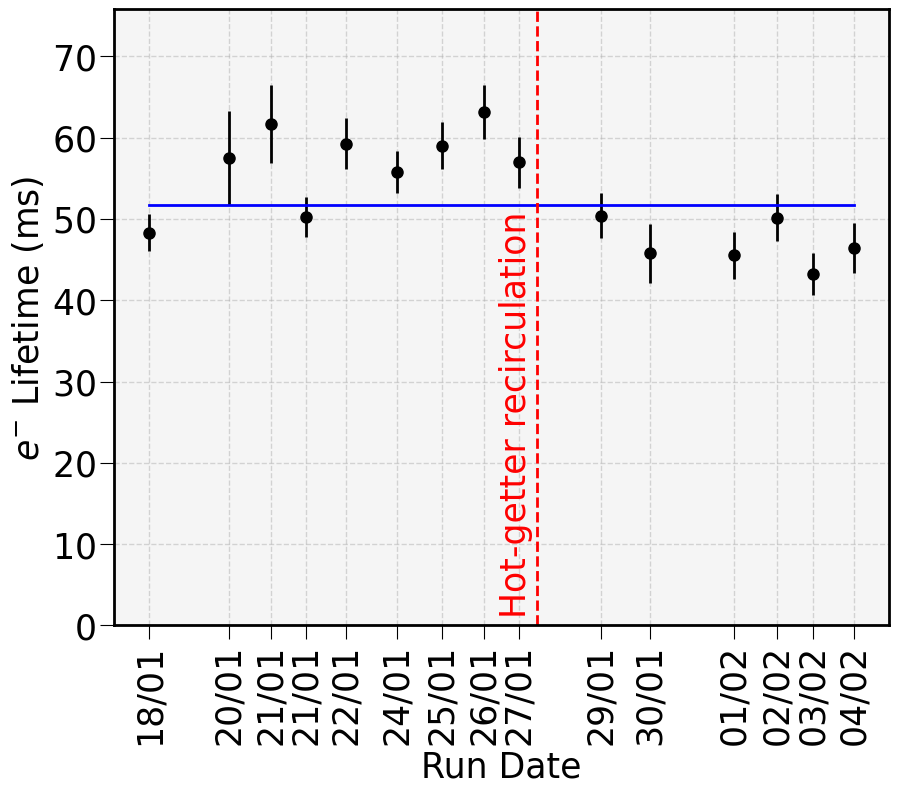

In [32]:
# ----- Plotting ----- #
# Data
plt.errorbar(Date, Lifet, xerr=Date_err, yerr=Lifet_err, fmt='o', c='black', ecolor='black')
# for x, y, run_id in zip(Date, Lifet, Run_number):
#     plt.text(x, y, str(run_id), fontsize=10, ha='left', va='bottom', color='blue')  # Run number near the point

# Fits
plt.plot(x_fit[0], y_fit[0], color='blue', ls='-', label=f'Constant Fit\nχ² / ndof = {chi2[0] / ndof[0]:.2f}')
# plt.plot(x_fit[1], y_fit[1], color='orange', ls='--', label=f'Linear Fit\nχ² / ndof = {chi2[1] / ndof[1]:.2f}')

# Important dates
plt.axvline(x=1737975600, c='red', ls='--')
plt.text(1737975600-1e4, 1.0, 'Hot-getter recirculation', c='red', va='bottom',  ha='right',  rotation=90)

# ----- Styling ----- #
plt.xlabel('Run Date')
x_labels = [crudo.ut.epoch_converter(t, h=False) for t in Date]  # Convert x-axis bin edges to readable time format
plt.xticks(Date, x_labels, rotation=90, ha='center')
plt.ylim(0, 1.2 * Lifet.max())
plt.ylabel(r'$e^{-}$ Lifetime (ms)')
# plt.title(r'$e^{-}$ Lifetime Evolution')
# plt.legend(loc='upper right', fontsize=8)

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig(f'/lhome/ific/c/ccortesp/Analysis/NEXT-100/Rn_analysis/images/Lifetime_Evolution.pdf')
plt.show()

What's the maximum factor of correction? (@ cathode)

In [33]:
# Any maximum DT value
max_DT = DT_stop[14739]
print(f"Correction by lifetime @ cathode (max. factor): {crudo.ff.exponential_decay(max_DT, 1, LIFETIME, 0):.2%}")

Correction by lifetime @ cathode (max. factor): 97.48%


# Energy Corrections

We perform energy corrections exclusively for the runs categorized as:

- **High $^{222}\text{Rn }\rightarrow$** 14739
- **Low $^{222}\text{Rn }\,\,\rightarrow$** 14834, 14835, 14837, 14838, 14839, 14840

Each run corrects its $S1$ energy by itself, while the lifetime used for $S2$ energy corrections came from the above fit.
<br> 
Geometry effects in the $S2$ are adressed by the energy map of high radon run (14739).

In [34]:
# Global
n_bins  = 50

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id = entry["run_number"]
    
    # Analysis runs
    if run_id in HIGH_RN_RUNS + LOW_RN_RUNS:
        
        if run_id in HIGH_RN_RUNS:

            # Fit parameters for energy corrections
            CV_fit = [FIT_PARAMETERS[run_id]['S1e']['m_CV'],  FIT_PARAMETERS[run_id]['S1e']['b_CV']]
            LT_fit = [FIT_PARAMETERS[run_id]['S2e']['N0_CV'], LIFETIME]

            # Apply corrections
            SEL_DATA[run_id] = crudo.ef.correct_S1e   (SEL_DATA[run_id], CV_fit, DT_stop[run_id], output_column='S1e_corr')  # S1 energy
            SEL_DATA[run_id] = crudo.ef.correct_S2e_LT(SEL_DATA[run_id], LT_fit, output_column='S2e_corr_LT')                # S2 energy by lifetime

            # Generate the reference (High-Rn) energy map
            print(f"Generating energy map of reference...\nThank you run {run_id} for your stats")

            # Variables
            X_ref  = SEL_DATA[run_id]['X']
            Y_ref  = SEL_DATA[run_id]['Y']
            E2_ref = SEL_DATA[run_id]['S2e_corr_LT']

            # Generate the energy map normalized to the center
            ref_energy_map, x_edges, y_edges = crudo.ef.pt.mapping(X_ref[AV_mask[run_id]], Y_ref[AV_mask[run_id]], wei=E2_ref[AV_mask[run_id]], 
                                                          xy_bins=n_bins, norm=True)

        if run_id in LOW_RN_RUNS:

            # Fit parameters for energy corrections
            CV_fit = [FIT_PARAMETERS[run_id]['S1e']['m_CV'],  FIT_PARAMETERS[run_id]['S1e']['b_CV']]
            LT_fit = [FIT_PARAMETERS[run_id]['S2e']['N0_CV'], LIFETIME]

            # Apply corrections
            SEL_DATA[run_id] = crudo.ef.correct_S1e   (SEL_DATA[run_id], CV_fit, DT_stop[run_id], output_column='S1e_corr')  # S1 energy
            SEL_DATA[run_id] = crudo.ef.correct_S2e_LT(SEL_DATA[run_id], LT_fit, output_column='S2e_corr_LT')                # S2 energy by lifetime

        print(f"--- Processing Run {run_id} ---")

        # Apply S2 energy correction by geometric map
        SEL_DATA[run_id] = crudo.ef.correct_S2e_map_fixed(SEL_DATA[run_id], ref_energy_map, x_edges, y_edges)

Generating energy map of reference...
Thank you run 14739 for your stats
--- Processing Run 14739 ---
--- Processing Run 14834 ---
--- Processing Run 14835 ---
--- Processing Run 14837 ---
--- Processing Run 14838 ---
--- Processing Run 14839 ---
--- Processing Run 14840 ---


### S1 Energy Corrected?

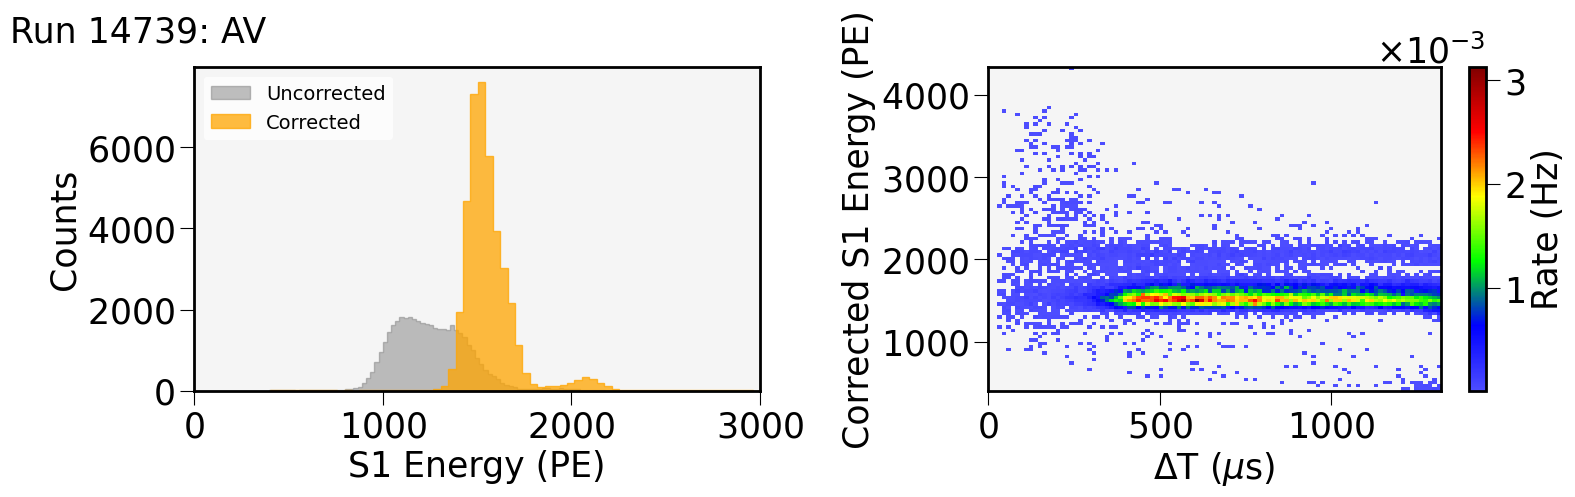

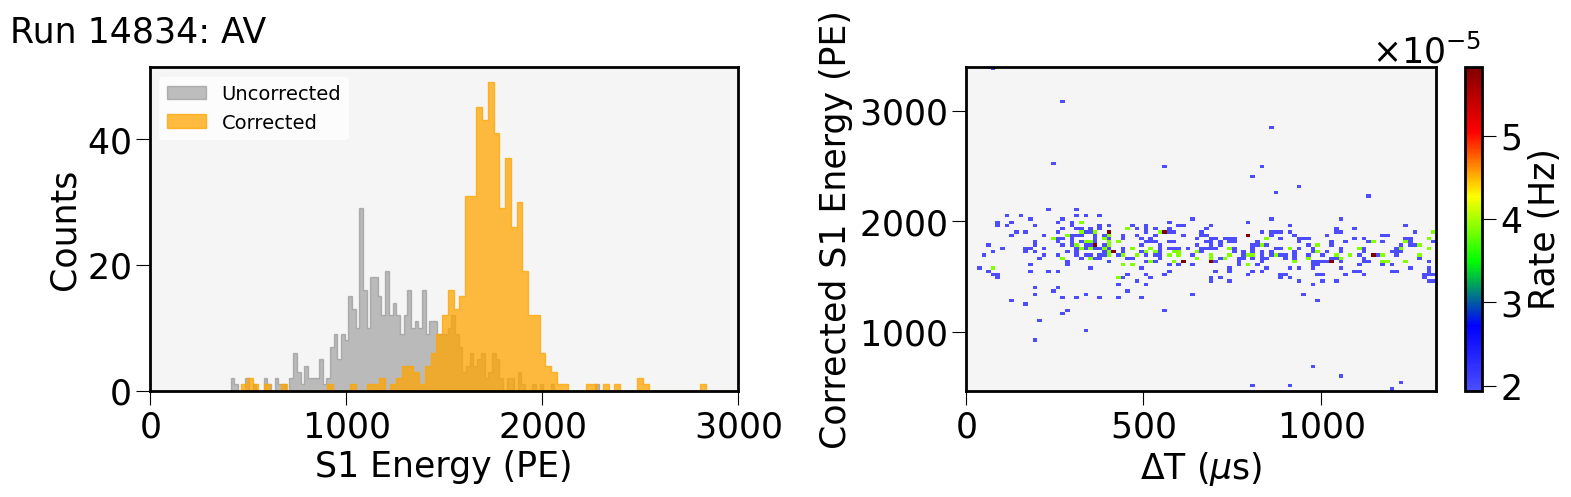

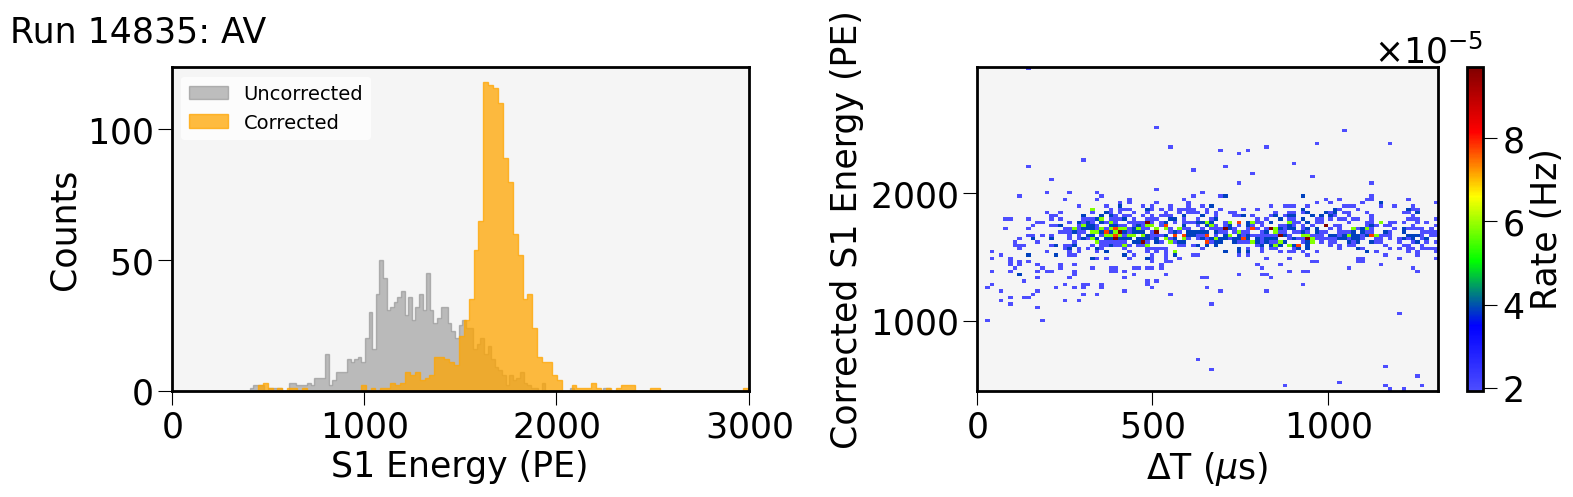

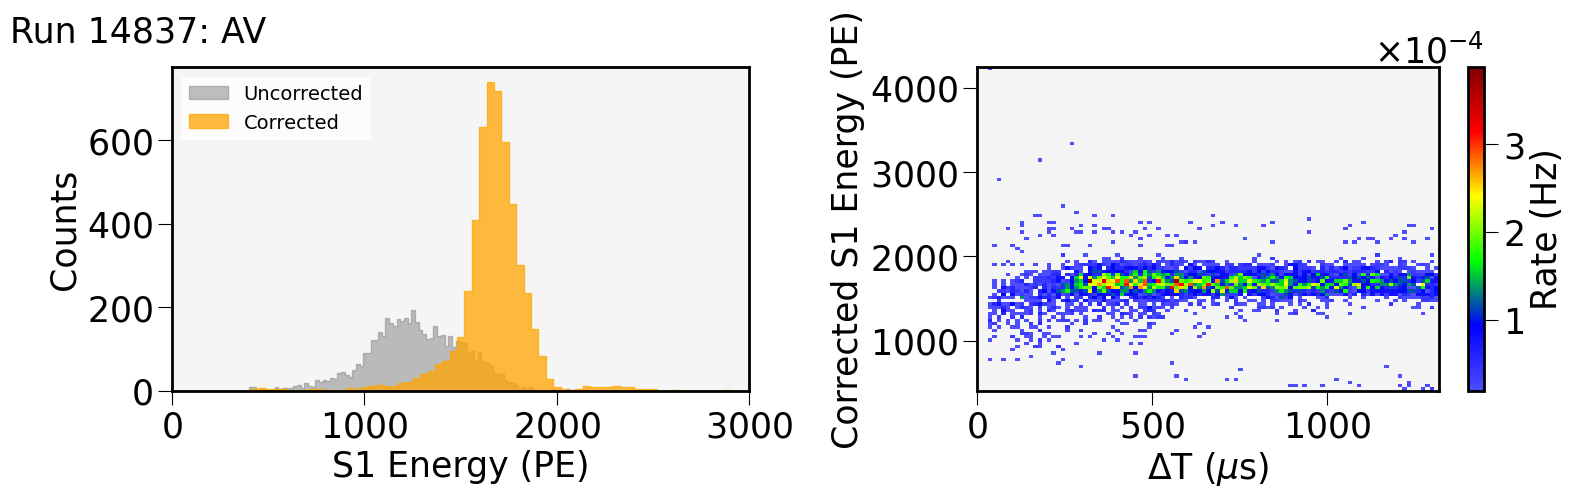

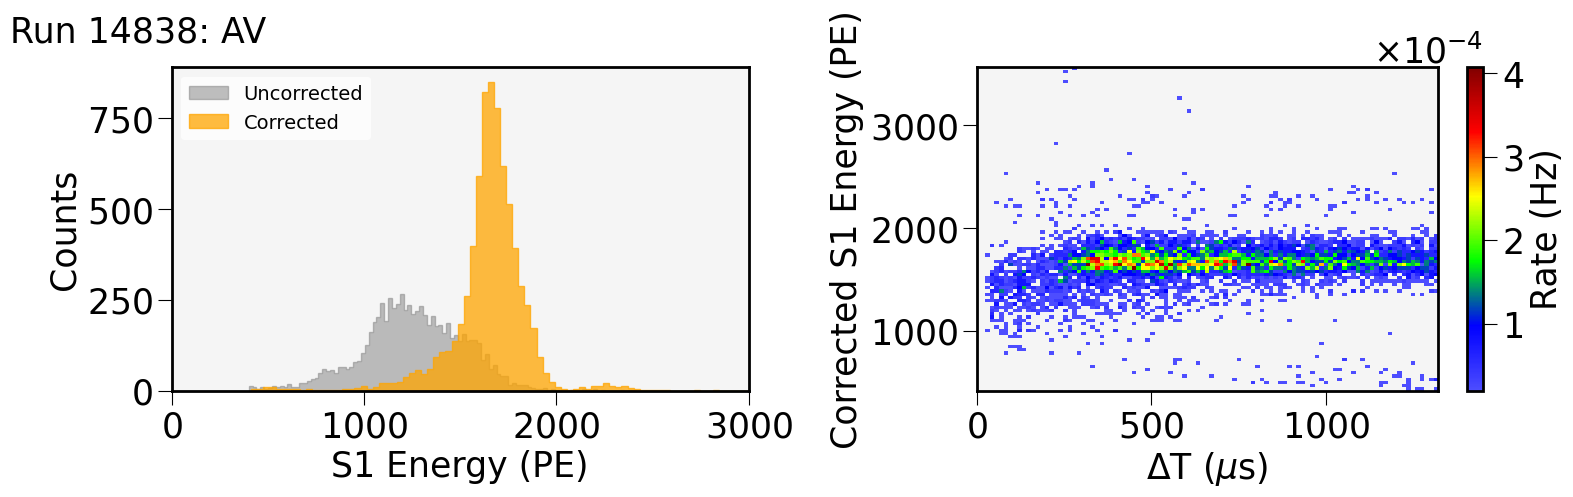

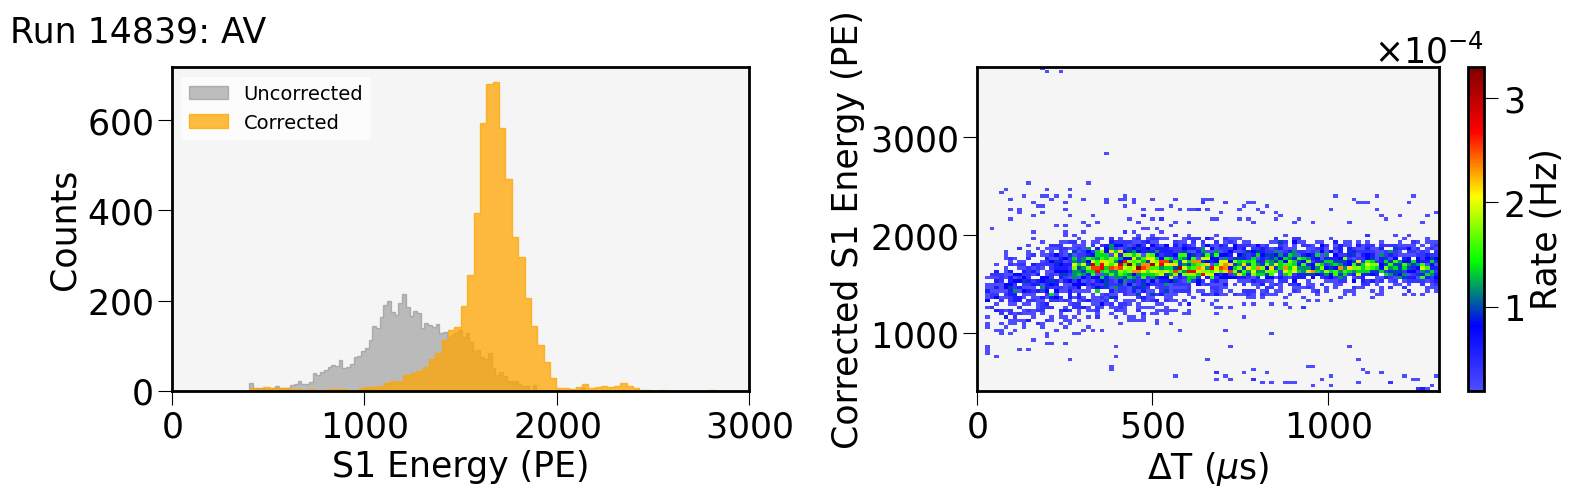

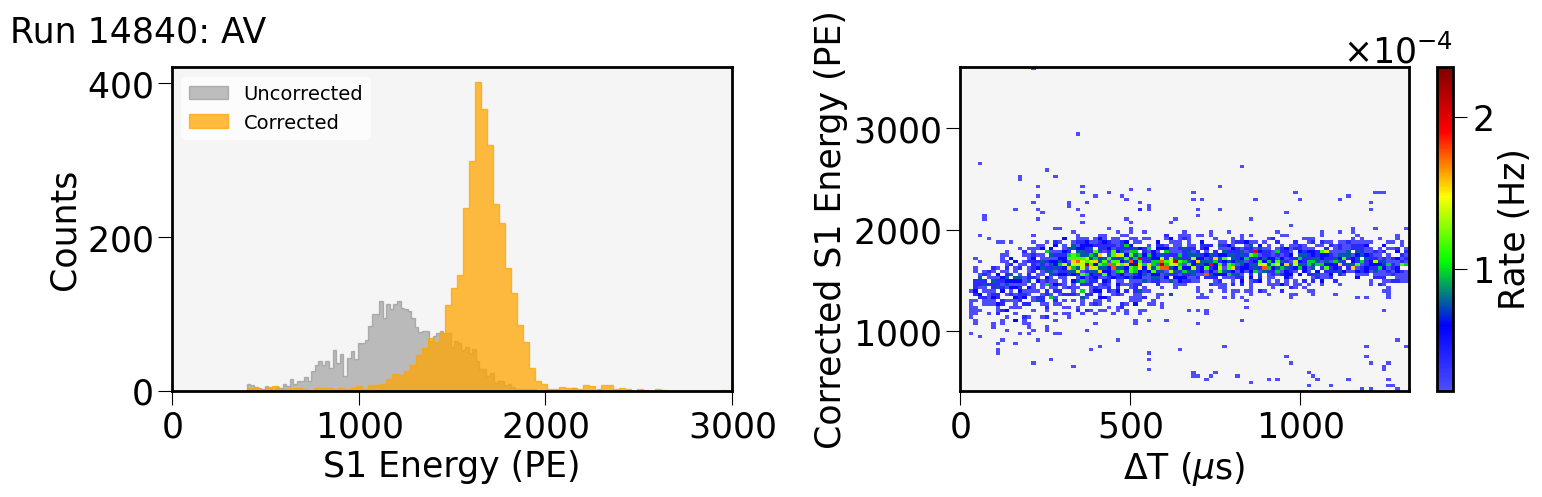

In [36]:
# Global
n_bins = 100
E1_min = 0; E1_max = 3e3

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id = entry["run_number"]
    
    # Analysis runs
    if run_id in HIGH_RN_RUNS + LOW_RN_RUNS:
    
        # Variables    
        E1      = SEL_DATA[run_id]['S1e']
        E1_corr = SEL_DATA[run_id]['S1e_corr']
        DT      = SEL_DATA[run_id]['DT']

        # Masking
        E1_mask  = E1[AV_mask[run_id]]
        E1c_mask = E1_corr[AV_mask[run_id]]
        DT_mask  = DT[AV_mask[run_id]]

        # 2D histogram: normalized by corrected DAQ data taking time
        S1e_DT_map, ex, ey = crudo.pt.hist_2D(DT_mask, E1c_mask, x_bins=n_bins, y_bins=n_bins)
        S1e_DT_map         = S1e_DT_map / (run_long * DAQe_CV)                           
        S1e_DT_map         = np.ma.masked_where(S1e_DT_map == 0, S1e_DT_map)  # Zero values masked

        # ----- Plotting ----- #
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Left
        axes[0].hist(E1_mask, bins=n_bins, histtype='stepfilled', lw=1.0, color='grey', alpha=0.50, ec='grey', label='Uncorrected')
        axes[0].hist(E1c_mask, bins=n_bins, histtype='stepfilled', lw=1.0, color='orange', alpha=0.75, ec='orange', label='Corrected')
        axes[0].set_xlabel('S1 Energy (PE)')
        axes[0].set_xlim(E1_min, E1_max)
        axes[0].set_ylabel('Counts')
        axes[0].legend(loc='upper left', fontsize=14)
        axes[0].set_facecolor('whitesmoke')

        # Right
        pcm = axes[1].pcolormesh(ex, ey, S1e_DT_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
        cbar = fig.colorbar(pcm, ax=axes[1], label='Rate (Hz)')
        axes[1].set_xlabel('$\Delta$T ($\mu$s)')
        axes[1].set_xlim(0, DT_mask.max())
        axes[1].set_ylabel('Corrected S1 Energy (PE)')
        axes[1].set_facecolor('whitesmoke')

        # Single title for the figure
        fig.suptitle(f'Run {run_id}: AV', fontsize=25, x=0, y=0.85, ha='left')

        plt.tight_layout()
        plt.show()

### S2 Energy Corrected?

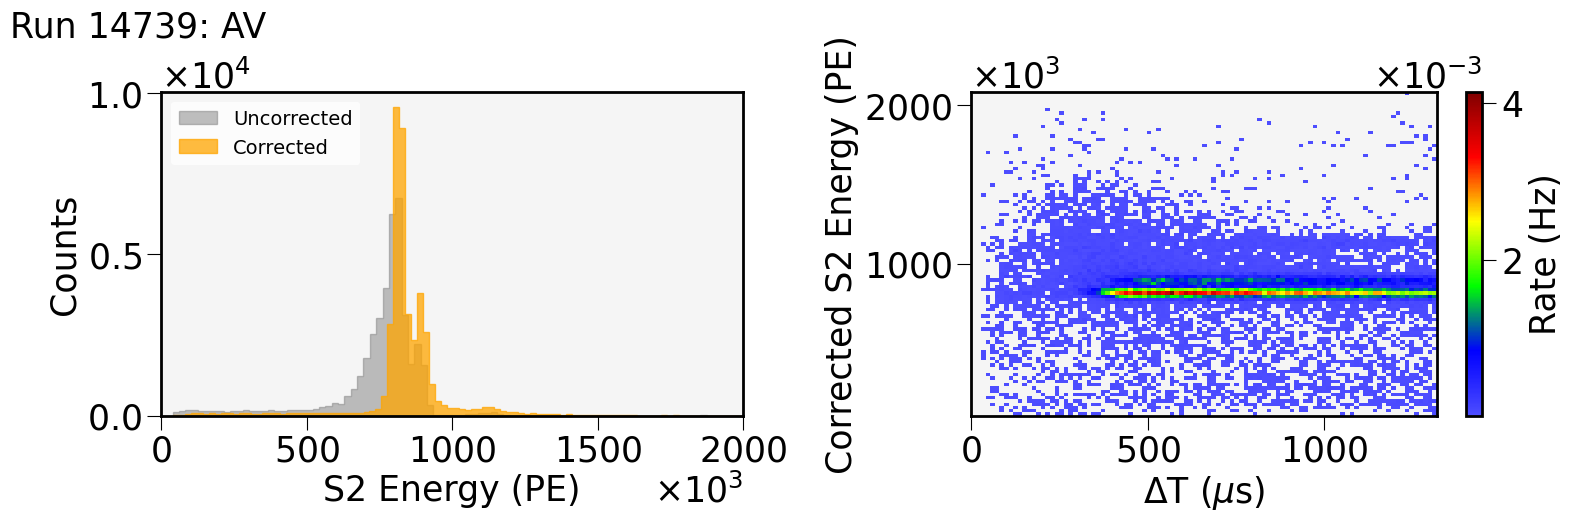

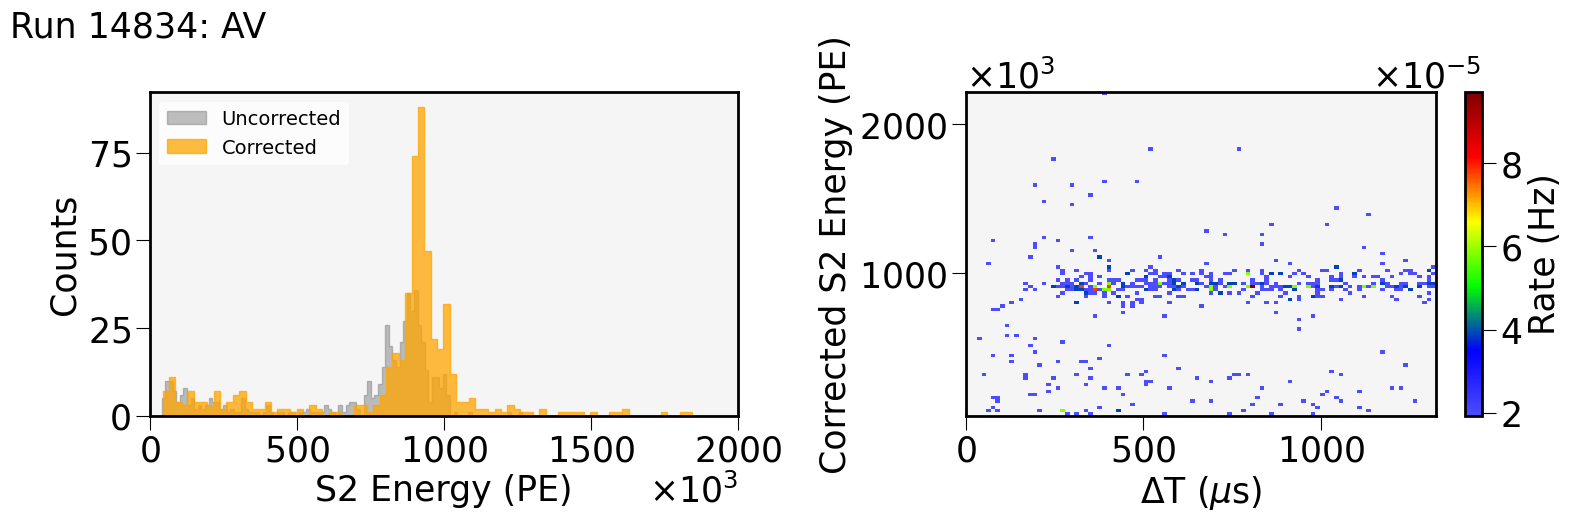

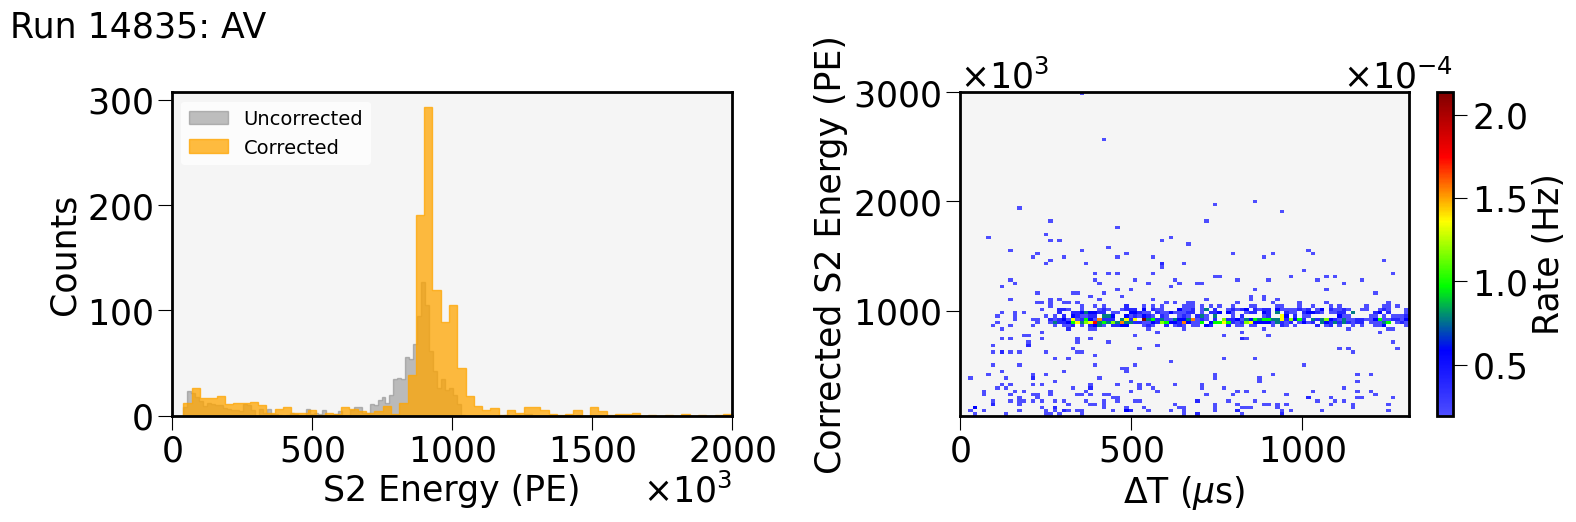

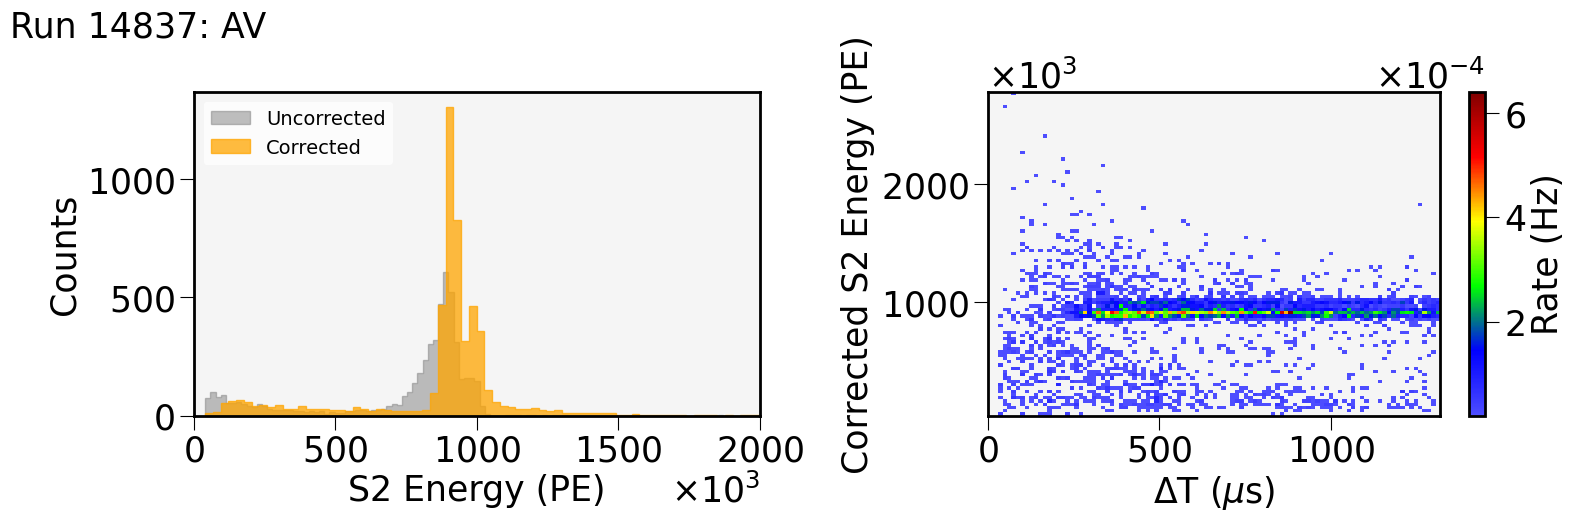

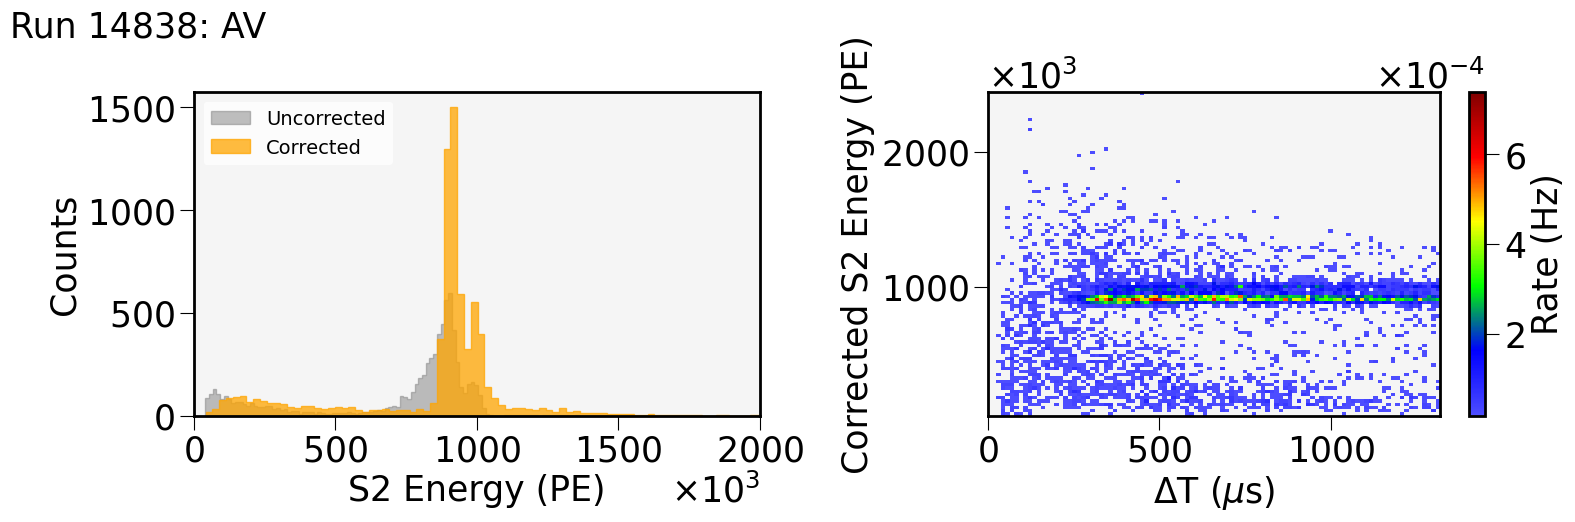

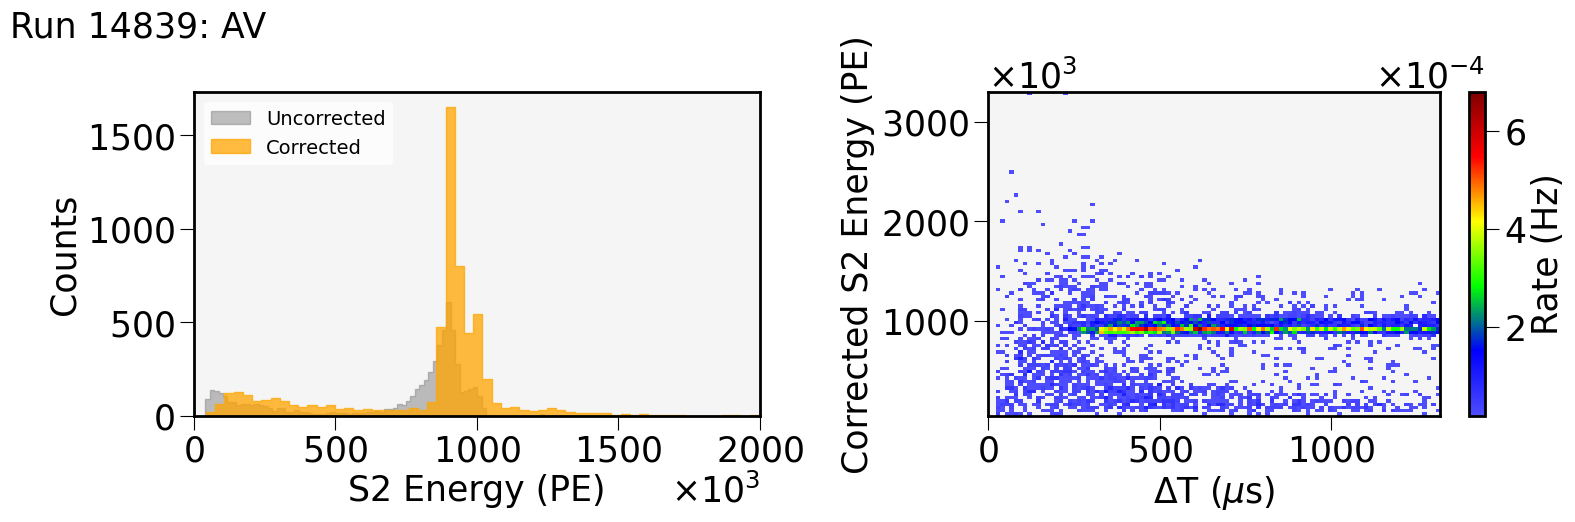

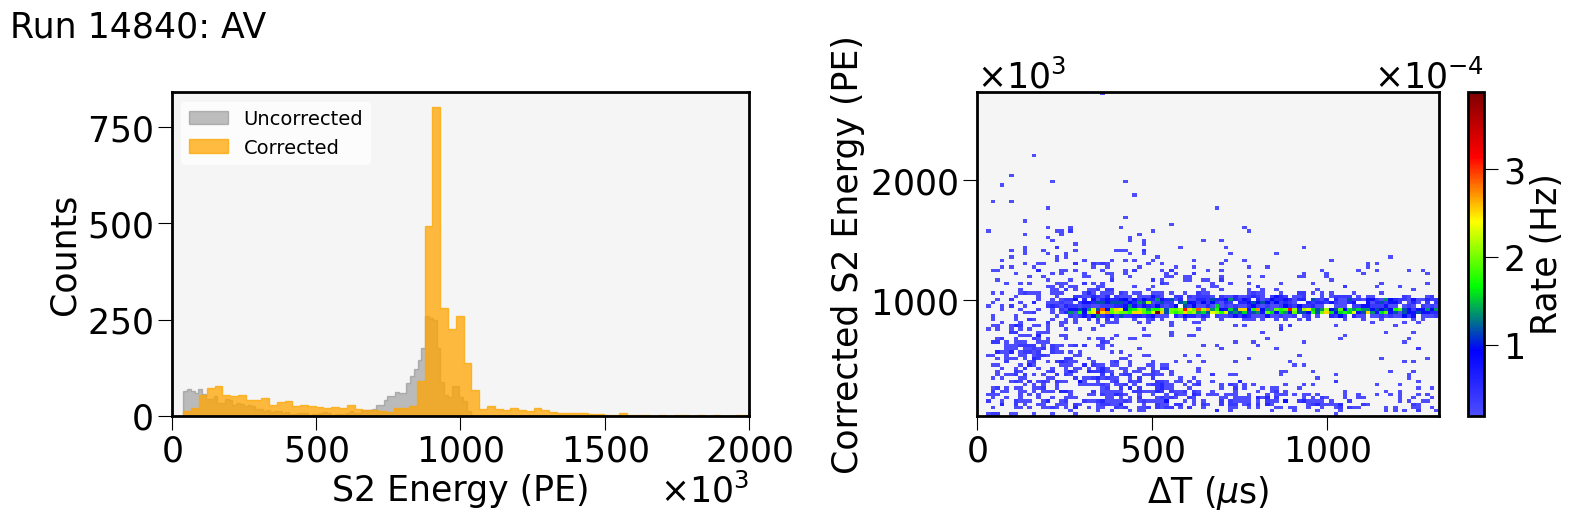

In [37]:
# Global
n_bins = 100
E2_min = 0;  E2_max = 2000e3

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    
    # Analysis runs
    if run_id in HIGH_RN_RUNS + LOW_RN_RUNS:
    
        # Variables    
        E2      = SEL_DATA[run_id]['S2e']
        E2_corr = SEL_DATA[run_id]['S2e_corr']
        DT      = SEL_DATA[run_id]['DT']

        # Masking
        E2_mask = E2[AV_mask[run_id]]
        E_mask  = E2_corr[AV_mask[run_id]]
        DT_mask = DT[AV_mask[run_id]]

        # 2D histogram: normalized by corrected DAQ data taking time
        S2e_DT_map, ex, ey = crudo.pt.hist_2D(DT_mask, E_mask, x_bins=n_bins, y_bins=n_bins)
        S2e_DT_map         = S2e_DT_map / (run_long * DAQe_CV)                           
        S2e_DT_map         = np.ma.masked_where(S2e_DT_map == 0, S2e_DT_map)  # Zero values masked

         # ----- Plotting ----- #
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Left
        axes[0].hist(E2_mask, bins=n_bins, histtype='stepfilled', lw=1.0, color='grey', alpha=0.50, ec='grey', label='Uncorrected')
        axes[0].hist(E_mask, bins=n_bins, histtype='stepfilled', lw=1.0, color='orange', alpha=0.75, ec='orange', label='Corrected')
        axes[0].set_xlabel('S2 Energy (PE)')
        axes[0].set_xlim(E2_min, E2_max)
        axes[0].set_ylabel('Counts')
        axes[0].ticklabel_format(axis='x', style='sci', scilimits=(3,3))
        axes[0].legend(loc='upper left', fontsize=14)
        axes[0].set_facecolor('whitesmoke')

        # Right
        pcm = axes[1].pcolormesh(ex, ey, S2e_DT_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
        cbar = fig.colorbar(pcm, ax=axes[1], label='Rate (Hz)')
        axes[1].set_xlabel('$\Delta$T ($\mu$s)')
        axes[1].set_xlim(0, DT_mask.max())
        axes[1].set_ylabel('Corrected S2 Energy (PE)')
        axes[1].ticklabel_format(axis='y', style='sci', scilimits=(3,3))
        axes[1].set_facecolor('whitesmoke')

        # Single title for the figure
        fig.suptitle(f'Run {run_id}: AV', fontsize=25, x=0, y=0.9, ha='left')

        plt.tight_layout()
        plt.show()

## Alphas Selection

An $\alpha$ threshold can be applied to analyze just $\alpha$-like candidates.
<br>
These data do not include significant portion of electron-like candidates, though.

In [38]:
for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id = entry["run_number"]

    # Event counters
    evts_prior, evts_post = 0, 0
    
    # Analysis runs
    if run_id in HIGH_RN_RUNS + LOW_RN_RUNS:

        print(f"--- Run {run_id} (threshold: {ALPHA_THRESHOLD if ALPHA_THRESHOLD is not None else 'none'} PE) ---")

        # Dataframe
        df = SEL_DATA[run_id]
        evts_prior = df['event'].nunique()

        # --- Alpha-like Selection Logic --- #
        if ALPHA_THRESHOLD is not None:
            alpha_mask  = (df['S1e_corr'] >= ALPHA_THRESHOLD)
            df_alpha = df[alpha_mask].copy()
        else:
            df_alpha = df.copy()

        # Updated dataframes and counters
        SEL_DATA[run_id] = df_alpha
        evts_post = df_alpha['event'].nunique()

        print(f"  Selection efficiency: {evts_post / evts_prior:.2%} ({evts_post}/{evts_prior} events)\n")

--- Run 14739 (threshold: none PE) ---
  Selection efficiency: 100.00% (72968/72968 events)

--- Run 14834 (threshold: none PE) ---
  Selection efficiency: 100.00% (720/720 events)

--- Run 14835 (threshold: none PE) ---
  Selection efficiency: 100.00% (1597/1597 events)

--- Run 14837 (threshold: none PE) ---
  Selection efficiency: 100.00% (6902/6902 events)

--- Run 14838 (threshold: none PE) ---
  Selection efficiency: 100.00% (9367/9367 events)

--- Run 14839 (threshold: none PE) ---
  Selection efficiency: 100.00% (7805/7805 events)

--- Run 14840 (threshold: none PE) ---
  Selection efficiency: 100.00% (4618/4618 events)



# High & Low-Rn Information

Not all the OK triggers correspond to alpha events.
<br>
Pau estimated the percentage of these triggers that are alphas through a discrimination in the $S1$ pulse. This value is what we call __alphas triggers__.


In [39]:
# Storage of Low_Rn dataframes
dfs = []          
# Low_Rn values: CV + error calculations
low_long = 0
low_trigg_CV = 0;  low_trigg_err = 0
low_reco_CV  = 0;  low_reco_err  = 0
low_sel_CV   = 0;  low_sel_err   = 0

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    run_long = entry["duration"]    
    run_OK   = entry["OK"] 
    run_LOST = entry["LOST"]
    
    if run_id in HIGH_RN_RUNS:

        # DAQe efficiency + error
        DAQe_CV, DAQe_error = crudo.ff.efficiency(run_OK, run_LOST)
        
        ANA_DATA['High_Rn']['df']            = SEL_DATA[run_id]
        ANA_DATA['High_Rn']['duration_CV']   = run_long * DAQe_CV
        # Alpha trigger rate + error
        alpha_evt_cv  = run_OK * ALPHA_TRG_EFF_HIGH
        alpha_evt_err = alpha_evt_cv * np.sqrt((np.sqrt(run_OK) / run_OK)**2 + (TRG_EFF_ERR)**2)
        ANA_DATA['High_Rn']['alpha_rate_CV']  = alpha_evt_cv / (run_long * DAQe_CV)
        ANA_DATA['High_Rn']['alpha_rate_err'] = alpha_evt_err / (run_long * DAQe_CV)

    if run_id in LOW_RN_RUNS:

        # DAQe efficiency + error
        DAQe_CV, DAQe_error = crudo.ff.efficiency(run_OK, run_LOST)
        
        dfs.append(SEL_DATA[run_id])
        low_long     += run_long * DAQe_CV

# Low-Rn complete information
ANA_DATA['Low_Rn']['df']             = pd.concat(dfs, ignore_index=True)
ANA_DATA['Low_Rn']['duration_CV']    = low_long
ANA_DATA['Low_Rn']['alpha_rate_CV']  = TRG_RATE_LOW_RN_CV * ALPHA_TRG_EFF_LOW
ANA_DATA['Low_Rn']['alpha_rate_err'] = (TRG_RATE_LOW_RN_CV * ALPHA_TRG_EFF_LOW) * np.sqrt((TRG_RATE_LOW_RN_ERR / TRG_RATE_LOW_RN_CV)**2 + (TRG_EFF_ERR)**2)

In [40]:
print("\n--- Summary of Analysis Data ---")
for key in ANA_DATA.keys():
    print(f"\n{key.upper()}:")
    for subkey in ANA_DATA[key].keys():
        if subkey == 'df':
            continue
        print(f" {subkey} = {ANA_DATA[key][subkey]:.2f}")


--- Summary of Analysis Data ---

HIGH_RN:
 duration_CV = 45718.51
 alpha_rate_CV = 42.51
 alpha_rate_err = 4.25

LOW_RN:
 duration_CV = 275250.92
 alpha_rate_CV = 1.19
 alpha_rate_err = 0.13


#### Masking again!

In [41]:
# Global
n_bins = 80
step_back = 2       # To avoid completely the cathode

for i, entry in enumerate(ANA_DATA):
    
    Rn_data = ANA_DATA[entry]['df']
    
    # Variables
    DT = Rn_data['DT']
    # Compute histogram avoiding negative values of DT (just in case)
    counts, bins = np.histogram(DT, bins=n_bins, range=(0, DT.max()))
    # Find the index of the bin with the highest count (cathode peak)
    cath_index = np.argmax(counts)
    
    # Ensure step_back is valid
    if cath_index - step_back < 0:
        raise ValueError(f"Warning: Invalid step back for {entry}.")
    else:
        # Compute DT_stop by stepping back from the cathode peak
        ANA_DATA[entry]['DTstop_CV']  = (bins[cath_index - step_back] + bins[cath_index - step_back + 1]) / 2
        ANA_DATA[entry]['DTstop_err'] = (bins[cath_index - step_back + 1] - bins[cath_index - step_back]) / 2
        
    print(f"{entry}:\n  DT stop = ({ANA_DATA[entry]['DTstop_CV']:.2f} ± {ANA_DATA[entry]['DTstop_err']:.2f}) μs")
    
    # Active volume
    ANA_DATA[entry]['AV_mask'] = (DT >= 0) & (DT < ANA_DATA[entry]['DTstop_CV'])
    # Cathode surroundings
    ANA_DATA[entry]['cath_mask'] = (DT >= ANA_DATA[entry]['DTstop_CV'])

High_Rn:
  DT stop = (1311.44 ± 9.17) μs
Low_Rn:
  DT stop = (1310.82 ± 9.17) μs


# Spatial Distributions

### Drift Time

High_Rn:
Cathode time position = (1332.36 +/- 9.00) μs
Drift velocity = (0.88 +/- 0.01) mm/μs 

Low_Rn:
Cathode time position = (1350.36 +/- 9.00) μs
Drift velocity = (0.87 +/- 0.01) mm/μs 



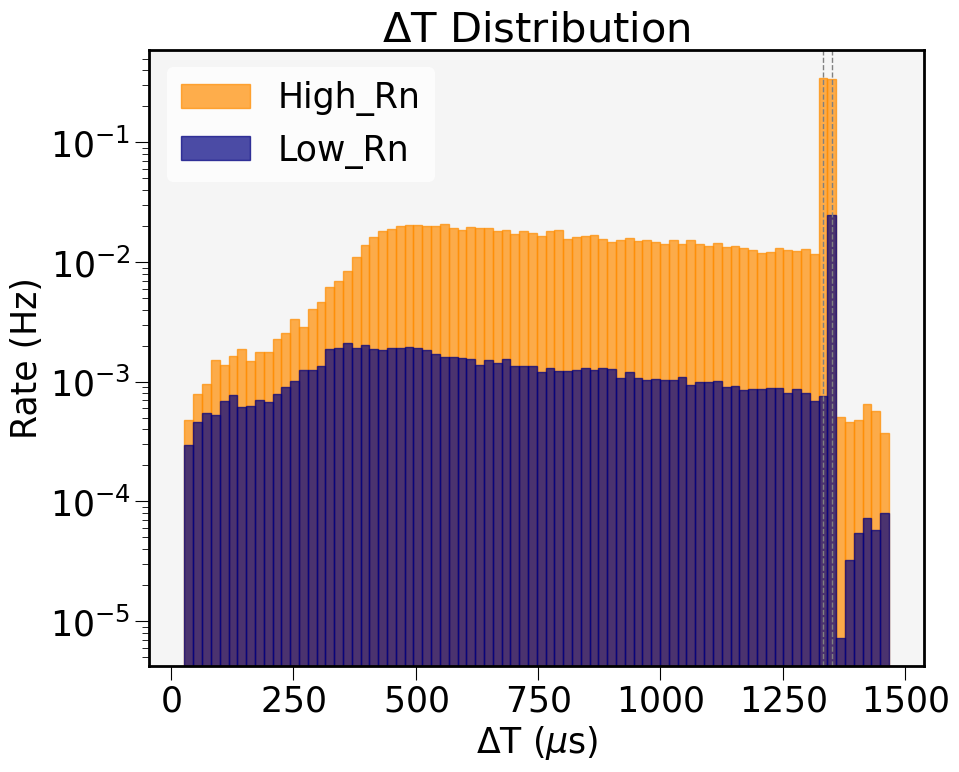

In [44]:
# Store important information
m_DT = {"High_Rn":{}, "Low_Rn":{}}  # Slopes from linear fit

# Global
n_bins = 80
DT_min = 400        # Lower limit for linear fit
color_index = 0     # Histogram color counter

# ----- Binning ----- #
data_std = ANA_DATA['High_Rn']['df']
_, DT_edges = np.histogram(data_std['DT'], bins=n_bins)

for i, entry in enumerate(ANA_DATA):
    
    Rn_data = ANA_DATA[entry]['df']
    Rn_long = ANA_DATA[entry]['duration_CV']
    
    # Variables
    DT = Rn_data['DT']

    # Histogram: normalized by corrected DAQ data taking time
    DT_counts, _ = np.histogram(DT, bins=DT_edges,  range=(0, DT.max()), density=False)
    DT_rate   = DT_counts / Rn_long
    bin_width = np.diff(DT_edges).mean()
    
    # Estimated cathode time position + error
    cath_index   = np.argmax(DT_counts)         # Index of the bin with the highest count
    cath_central = (DT_edges[cath_index] + DT_edges[cath_index + 1]) / 2      # Central value of the bin
    cath_error   = bin_width / 2

    # Drift velocity + error
    drift_vel      = (crudo.pt.N100_hei - crudo.pt.EL_gap) / cath_central
    drift_error    = drift_vel * (cath_error / cath_central)
    ANA_DATA[entry]['drift_vel_CV']  = drift_vel
    ANA_DATA[entry]['drift_vel_err'] = drift_error

    print(f'{entry}:')
    print(f'Cathode time position = ({cath_central:.2f} +/- {cath_error:.2f}) μs')
    print(f'Drift velocity = ({drift_vel:.2f} +/- {drift_error:.2f}) mm/μs \n')

    # Plot the normalized histogram + cathode line
    plt.bar(DT_edges[:-1], DT_rate, width=bin_width, align='edge', 
            color=crudo.pt.hist_colors[(3*i+2) % len(crudo.pt.hist_colors)], ec=crudo.pt.hist_colors[(3*i+2) % len(crudo.pt.hist_colors)],
            alpha=0.7, lw=1.0 , label=f'{entry}')         
    plt.axvline(x=cath_central, c='gray', ls='--', lw=1)  # Cathode line

    # ----- Linear fit ----- #
    # Preliminary
    DT_max = ANA_DATA[entry]['DTstop_CV']
    fit_region_mask = (DT >= DT_min) & (DT <= DT_max)
    DT_fit = DT[fit_region_mask]

    # Compute representative values for the fit
    fit_centers, _, fit_values, y_errors = crudo.ff.prefit_1D(DT_fit, DT_edges)
    # Filter out points with zero error (bins with 1 event)
    valid_points = y_errors > 0
    fit_centers = fit_centers[valid_points]
    fit_values  = fit_values[valid_points]

    popt, pcov = curve_fit(crudo.ff.linear_func, fit_centers, fit_values)
    m_DT[entry] = {'CV': popt[0], 'Error': np.sqrt(pcov[0, 0])}

    # Plot fit
    fit_y = crudo.ff.linear_func(fit_centers, *popt)
    # plt.plot(fit_centers, fit_y, c='red', ls='--', lw=1.5)

    color_index += 1
        
# ----- Styling ----- #
plt.xlabel('$\Delta$T ($\mu$s)')
plt.ylabel('Rate (Hz)')
plt.yscale('log')
plt.title(f'$\Delta$T Distribution')
plt.legend(loc='upper left')

plt.gca().set_facecolor("whitesmoke")
plt.show()

### Z Distribution

Z limit (High Rn): 1158.81 mm


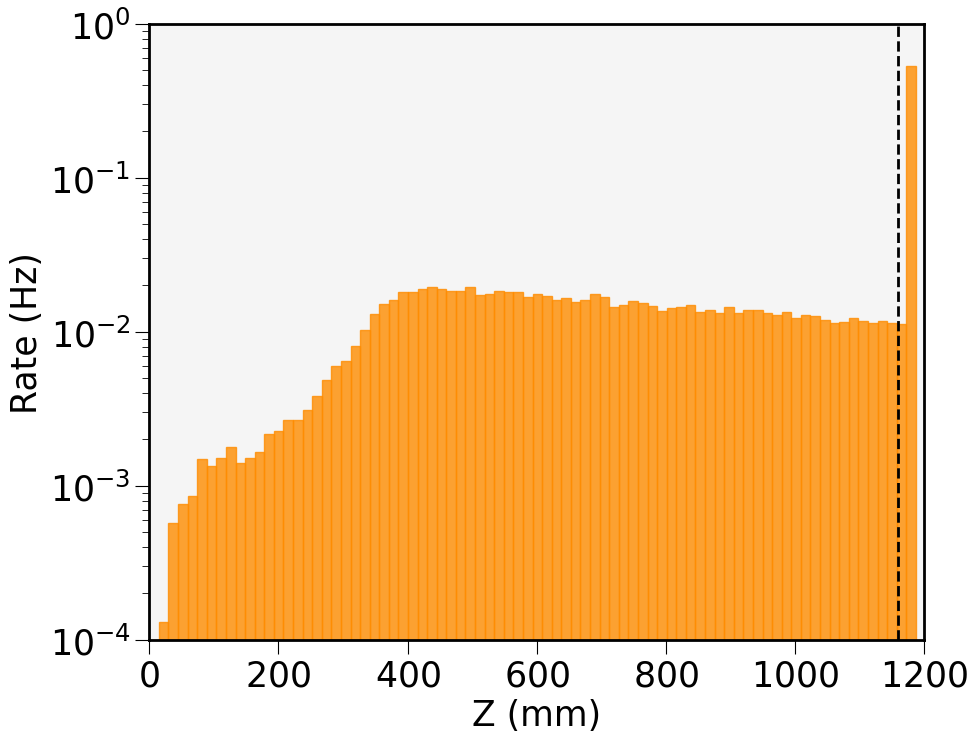

In [45]:
# Global
n_bins = 80

# Data
Rn_data = ANA_DATA['High_Rn']['df']
Rn_long = ANA_DATA['High_Rn']['duration_CV']

# Variables
DT = Rn_data['DT']

# Compute corrected Z
Z = ANA_DATA['High_Rn']['drift_vel_CV'] * DT

# Histogram: normalized by corrected DAQ data taking time
Z_counts, Z_edges = np.histogram(Z, bins=n_bins,  range=(0, crudo.pt.N100_hei))
Z_rate = Z_counts / Rn_long
bin_width = np.diff(Z_edges).mean()

# ----- Plotting ----- #
fig, ax = plt.subplots()

# Data
plt.bar(Z_edges[:-1], Z_rate, width=bin_width, align='edge', 
        color=crudo.pt.hist_colors[2], ec=crudo.pt.hist_colors[2],
        alpha=0.8, lw=1.0)

# Z-limit
Z_lim = ANA_DATA['High_Rn']['drift_vel_CV'] * ANA_DATA['High_Rn']['DTstop_CV']
print(f'Z limit (High Rn): {Z_lim:.2f} mm')
plt.axvline(x=Z_lim, c='black', ls='--')
        
# ----- Styling ----- #
# Important text
# plt.text(1125, 3.5e-1, 'Active Volume', va='center', ha='right')
# ax.annotate('', xytext=(1125, 5e-1), xy=(1000, 5e-1), arrowprops=dict(arrowstyle='->',  ec='black', fc='black'))
# plt.text(1185, 1e-4, 'Cathode', va='bottom', ha='right', rotation=90)

# # Preliminary logo
# LOGO_BOX = OffsetImage(PRELIM_LOGO, zoom=0.1)
# xy = (200, 5e-1)
# ab = AnnotationBbox(LOGO_BOX, xy, xybox=(0, 0), xycoords='data', boxcoords="offset points", frameon=False)
# ax.add_artist(ab)

plt.xlabel('Z (mm)')
plt.xlim(0, 1200)
plt.ylabel('Rate (Hz)')
plt.ylim(1e-4, 1e0)
plt.yscale('log')

plt.gca().set_facecolor("whitesmoke")
# plt.savefig(f'/lhome/ific/c/ccortesp/Analysis/NEXT-100/Rn_analysis/images/Z_Dist.pdf')
plt.show()

### XY Map

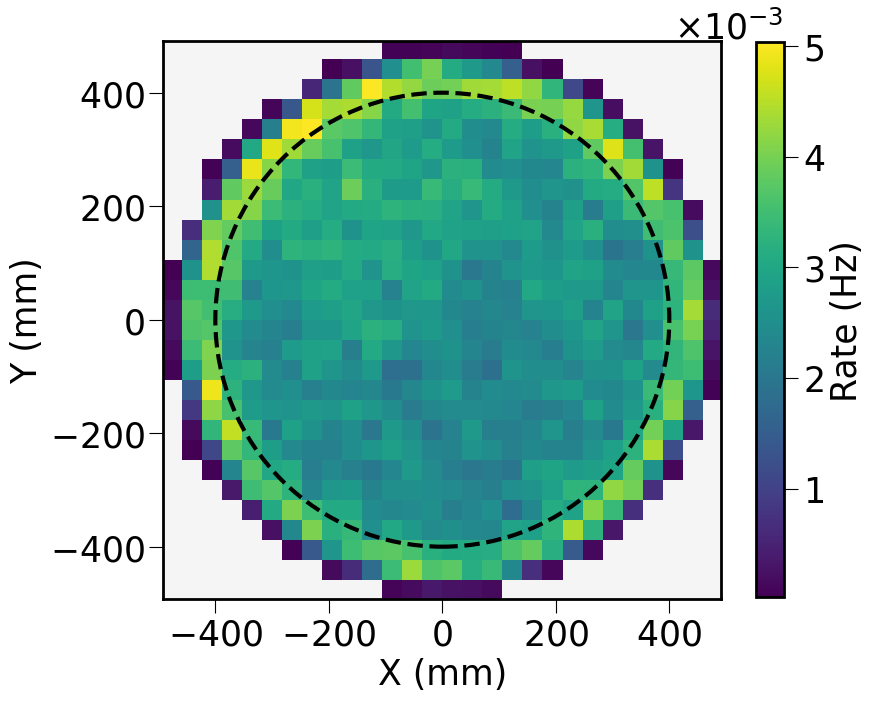

In [47]:
# Global
n_bins = 35

# Data
Rn_data = ANA_DATA['High_Rn']['df']
Rn_long = ANA_DATA['High_Rn']['duration_CV']

# Variables
X = Rn_data['X']
Y = Rn_data['Y']

# 2D histogram: normalized by corrected DAQ data taking time
XY_hit_map, ex, ey = crudo.pt.mapping(X, Y, xy_bins=n_bins, pos=True)
XY_rate            = XY_hit_map / Rn_long                          # Normalized to rate      
XY_rate            = np.ma.masked_where(XY_rate == 0, XY_rate)      # Zero values masked

# ----- Plotting ----- #
fig, ax = plt.subplots(figsize=(9, 9))
# Data
im = plt.pcolormesh(ex, ey, XY_rate.T, cmap='viridis', shading='auto')
# R-lim
plt.gca().add_patch(crudo.pt.plot_circle(400, LINESTYLE ='--'))

# ----- Styling ----- #
# # Important text
# plt.text(0, 0, 'Active Volume', va='center', ha='center')
# ax.annotate('', xytext=(-375, 0), xy=(-300, 0), arrowprops=dict(arrowstyle='->',  ec='black', fc='black'))
# ax.annotate('', xytext=(375, 0), xy=(300, 0), arrowprops=dict(arrowstyle='->',  ec='black', fc='black'))

# # Preliminary logo
# LOGO_BOX = OffsetImage(PRELIM_LOGO, zoom=0.1)
# xy = (-275, 400)
# ab = AnnotationBbox(LOGO_BOX, xy, xybox=(0, 42), xycoords='data', boxcoords="offset points", frameon=False)
# ax.add_artist(ab)

cbar = plt.colorbar(im, label='Rate (Hz)', shrink=0.8)
# cbar.formatter.set_powerlimits((-3, 3))
plt.xlabel('X (mm)')
plt.xlim(-crudo.pt.N100_rad, crudo.pt.N100_rad)
plt.ylabel('Y (mm)')
plt.ylim(-crudo.pt.N100_rad, crudo.pt.N100_rad)

plt.gca().set_aspect('equal', adjustable='box')
plt.gca().set_facecolor("whitesmoke")
# plt.tight_layout()
# plt.savefig(f'/lhome/ific/c/ccortesp/Analysis/NEXT-100/Rn_analysis/images/XY_Dist.pdf')
plt.show()

# Energy Estimator

We need to determine the optimum weight factor $\eta$ and the scale factor $\lambda$ for the new energy estimator using the $S1$ and $S2$ energy values.

In [33]:
# Parameters for the final energy estimator
Best_eta    = 0
High_lambda = 0
Low_lambda  = 0

## $\eta$ Determination

Because of statistics, we use the High-Rn run 14739.

Initial values: [2000, 1500.0, 4.572534285224828, 50, 2000.0, 4.572534285224828]
Final values: [ 639.48209139 1506.72515413   55.99928571  224.90360439 1641.96021745
  -61.23198319]
Energy resolution: 8.7526%


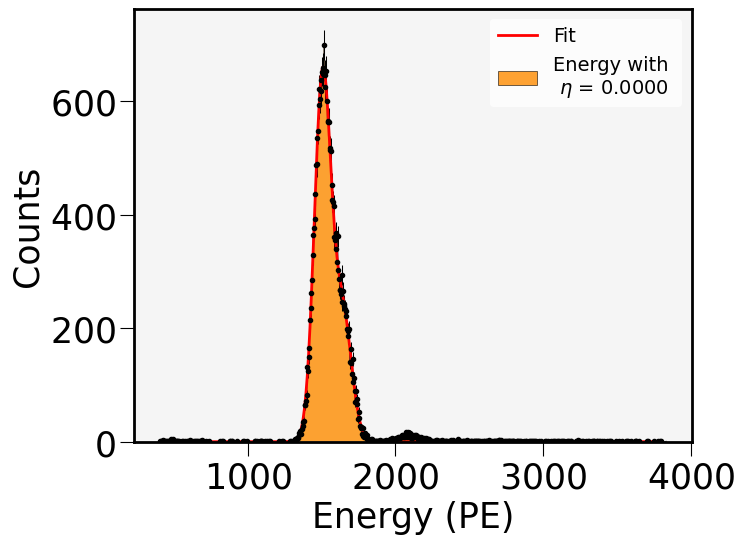

Initial values: [2000, 1923.4693877551022, 5.159228582332491, 50, 2474.4897959183672, 5.159228582332491]
Final values: [ 742.30430222 1923.65517184   54.38529815  255.61045084 2098.26243121
  -60.10729609]
Energy resolution: 6.6580%


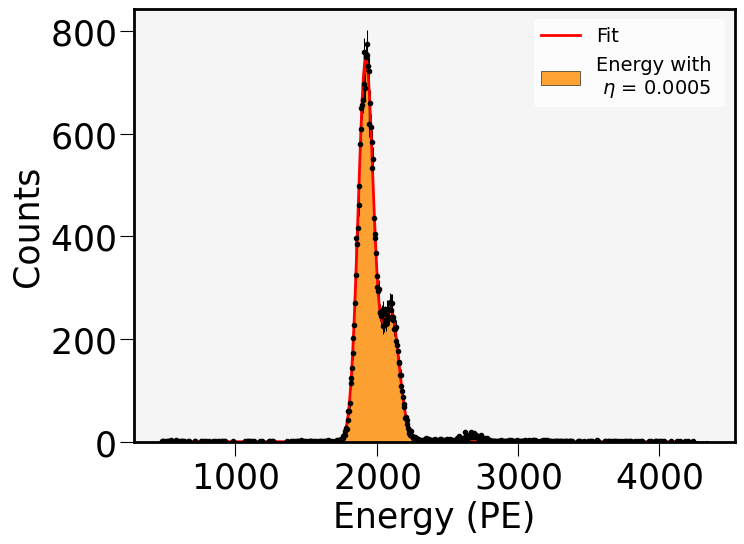

Initial values: [2000, 2346.9387755102043, 5.814274987165046, 50, 2948.979591836735, 5.814274987165046]
Final values: [ 831.60610568 2340.81373461   54.98015789  281.98323633 2554.13499846
  -60.27311933]
Energy resolution: 5.5313%


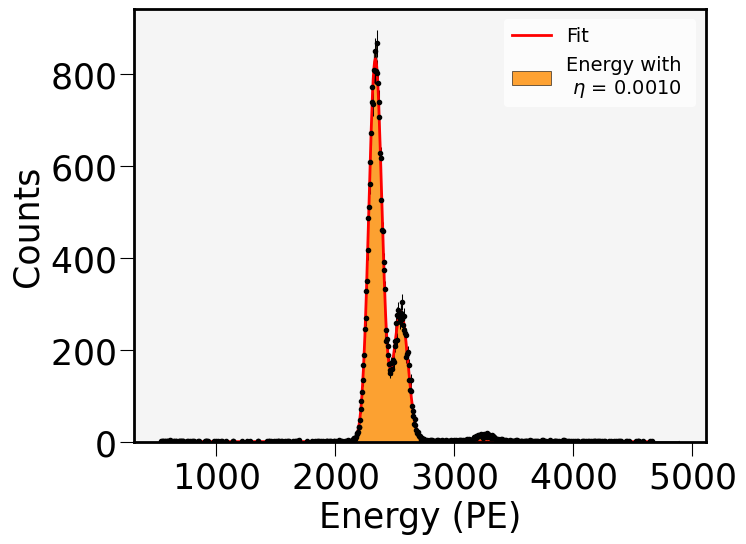

Initial values: [2000, 2770.408163265306, 6.47414775429343, 50, 3423.469387755102, 6.47414775429343]
Final values: [ 891.34106397 2757.91374919   57.22173191  300.9681944  3009.86768902
  -62.20437799]
Energy resolution: 4.8862%


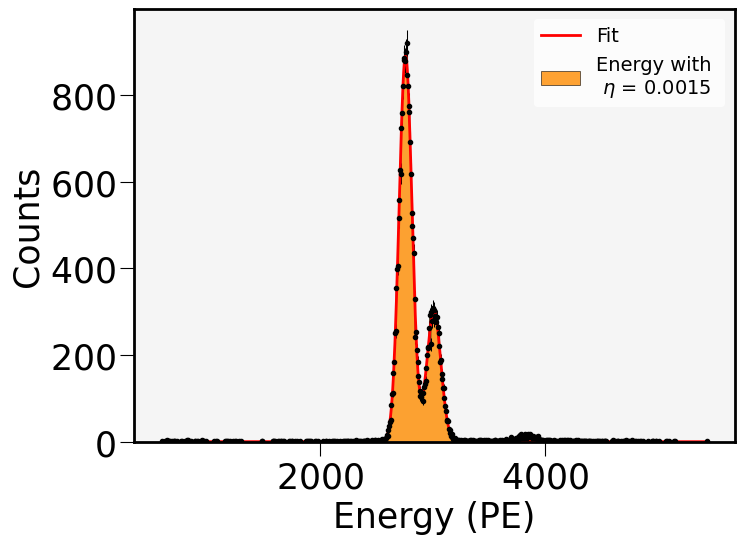

Initial values: [2000, 3193.8775510204086, 7.80965576912721, 50, 3897.95918367347, 7.80965576912721]
Final values: [1013.05657708 3174.83231996   60.75802313  342.75777369 3465.26307049
   65.52912414]
Energy resolution: 4.5069%


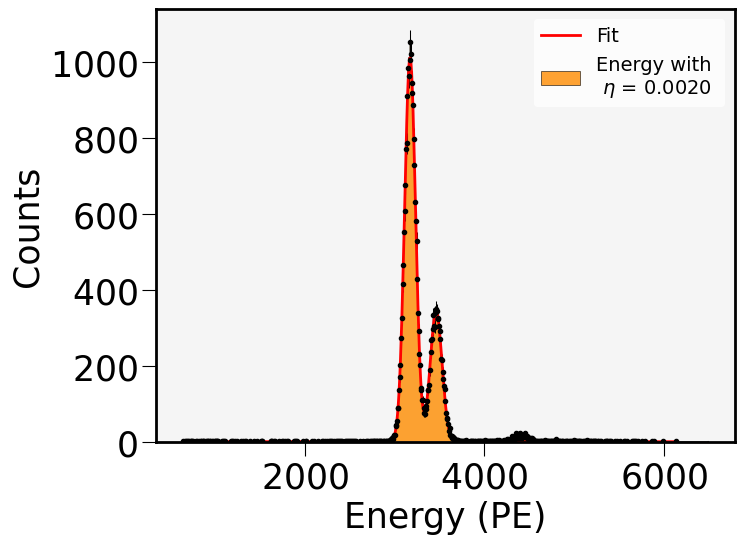

Initial values: [2000, 3617.3469387755104, 9.155614823228852, 50, 4372.448979591837, 9.155614823228852]
Final values: [1107.14645271 3591.60086068   65.08915431  374.53974931 3920.86793
  -69.91570096]
Energy resolution: 4.2679%


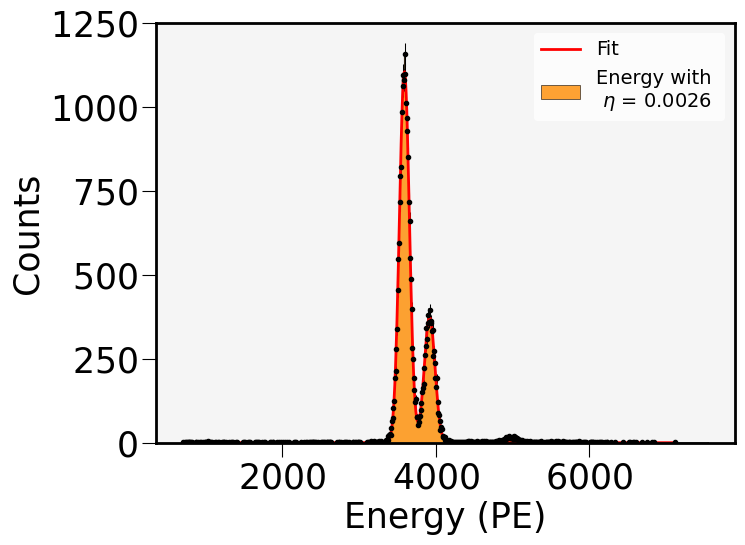

Initial values: [2000, 4040.8163265306125, 10.501573877330493, 50, 4846.938775510204, 10.501573877330493]
Final values: [1177.95214095 4008.23100931   69.92584159  398.04068214 4376.43382887
   75.18881386]
Energy resolution: 4.1084%


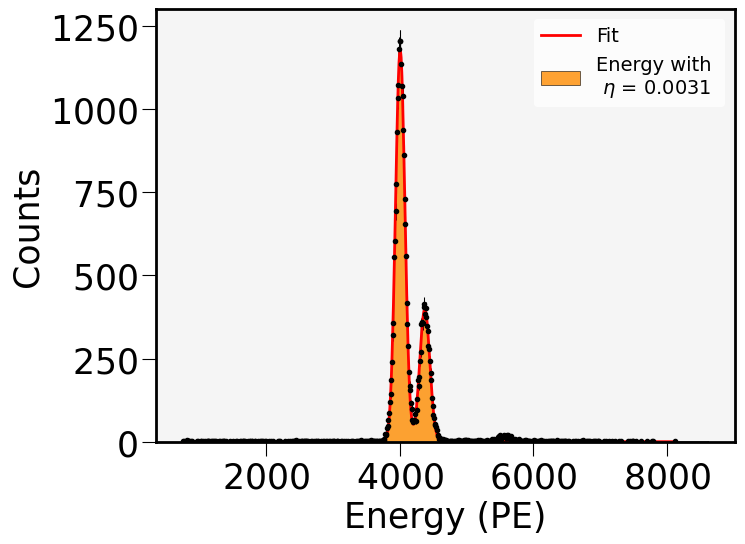

Initial values: [2000, 4464.285714285715, 11.847532931432132, 50, 5321.428571428572, 11.847532931432132]
Final values: [1230.84570106 4424.86924763   75.21010435  415.2022138  4832.0328657
   81.07790079]
Energy resolution: 4.0028%


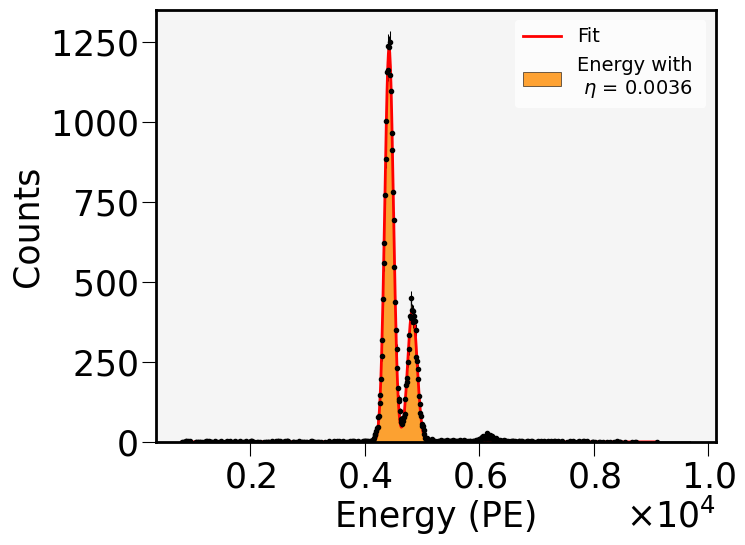

Initial values: [2000, 4887.755102040817, 13.193491985533775, 50, 5795.91836734694, 13.193491985533775]
Final values: [1271.82476448 4841.40666856   80.71593991  427.32510984 5287.58548157
   87.569632  ]
Energy resolution: 3.9263%


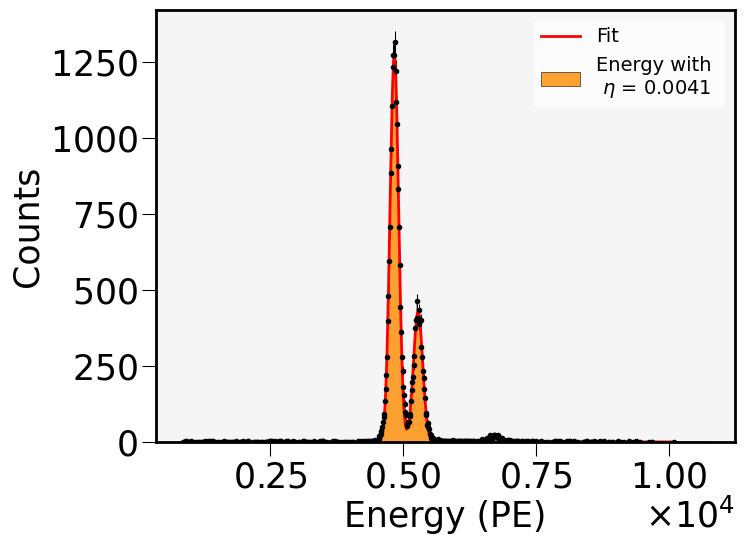

Initial values: [2000, 5311.224489795919, 14.546922498069138, 50, 6270.408163265307, 14.546922498069138]
Final values: [1303.05023233 5258.04975577   86.48989923  436.88006249 5742.97324773
  -94.22162616]
Energy resolution: 3.8738%


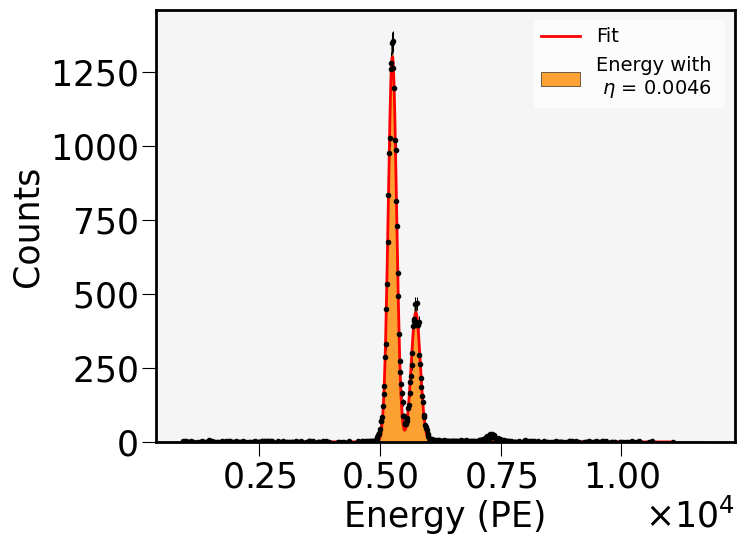

Initial values: [2000, 5734.693877551021, 15.924623715136253, 50, 6744.897959183674, 15.924623715136253]
Final values: [1325.22505216 5674.5943767    92.8407062   444.02025299 6198.4147759
  101.3272125 ]
Energy resolution: 3.8530%


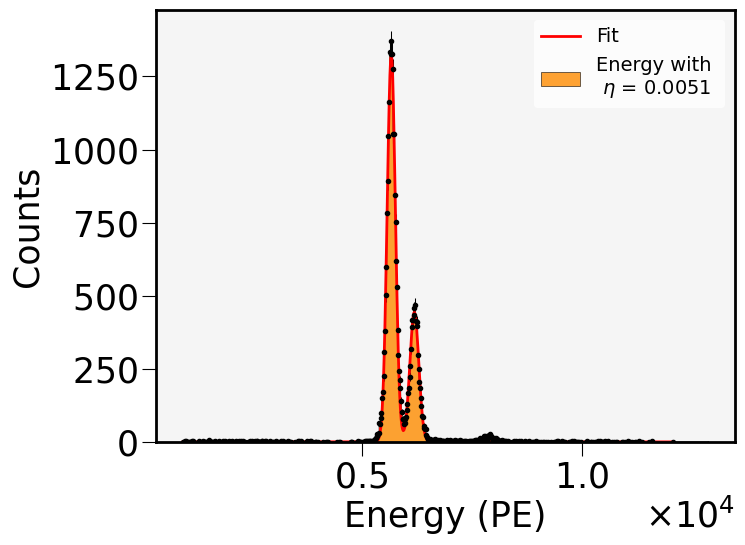

Initial values: [2000, 6158.163265306123, 17.302324932203366, 50, 7219.387755102041, 17.302324932203366]
Final values: [1342.96646656 6091.22762345   99.27147103  447.73772831 6653.64136809
  109.21642471]
Energy resolution: 3.8380%


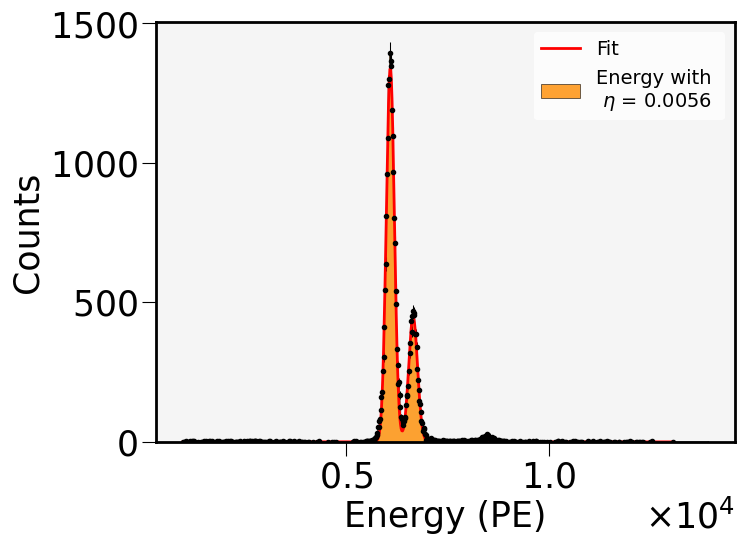

Initial values: [2000, 6581.632653061225, 18.68002614927048, 50, 7693.877551020409, 18.68002614927048]
Final values: [1355.58071693 6507.78865778  105.91686716  450.62052267 7108.73520144
 -117.26691733]
Energy resolution: 3.8329%


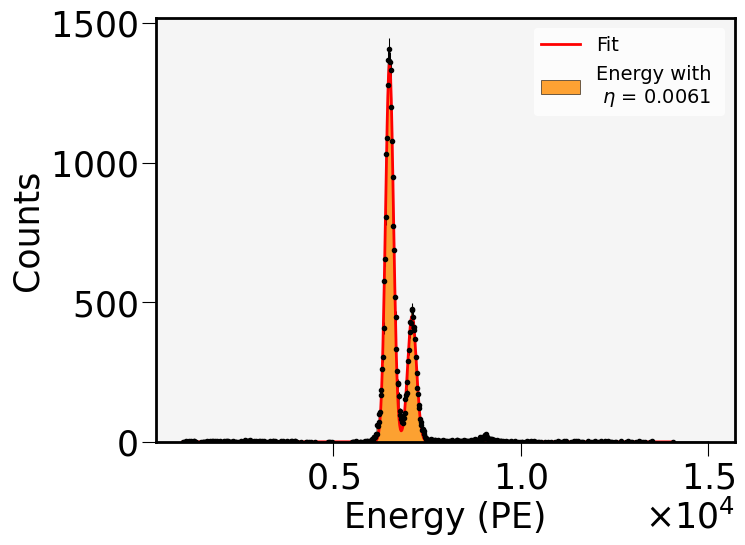

Initial values: [2000, 7005.102040816327, 20.057727366337588, 50, 8168.367346938776, 20.057727366337588]
Final values: [1364.27788873 6924.46049906  112.8324968   451.41669712 7563.88372481
 -125.97127779]
Energy resolution: 3.8374%


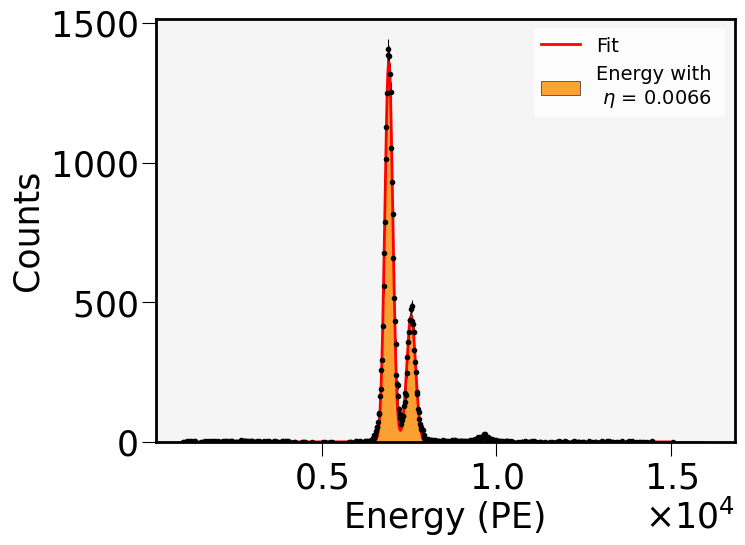

Initial values: [2000, 7428.571428571429, 21.4354285834047, 50, 8642.857142857143, 21.4354285834047]
Final values: [1369.81705607 7341.05860777  119.96672192  452.32507884 8018.98607162
  134.56690136]
Energy resolution: 3.8485%


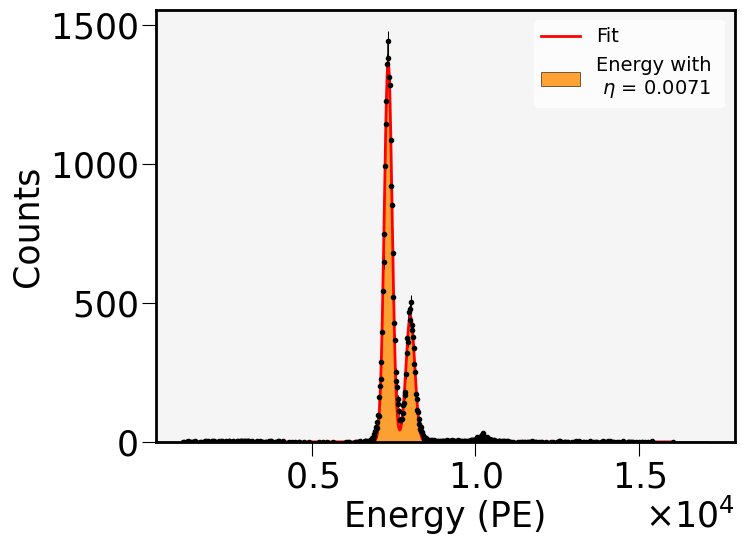

Initial values: [2000, 7852.040816326531, 22.813129800471817, 50, 9117.34693877551, 22.813129800471817]
Final values: [1371.81139183 7757.90880315  127.40619132  452.15054275 8474.20646697
 -143.61168609]
Energy resolution: 3.8676%


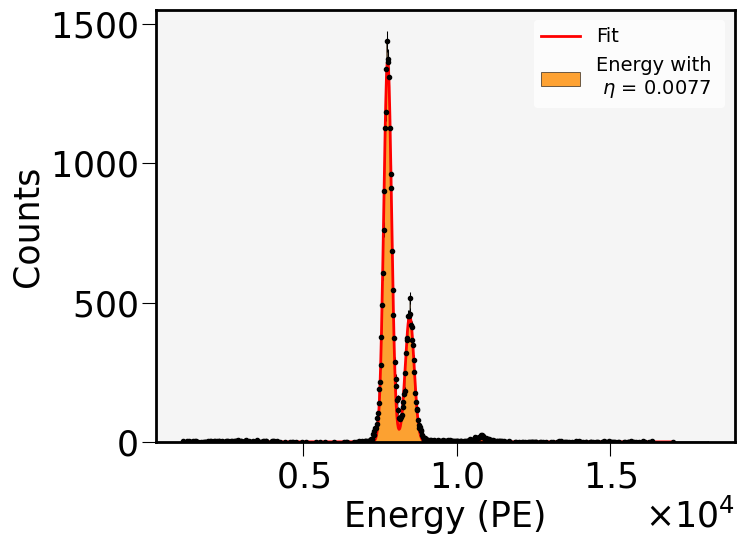

Initial values: [2000, 8275.510204081635, 24.190831017538926, 50, 9591.83673469388, 24.190831017538926]
Final values: [1374.10735826 8174.31612654  134.74132395  452.07411094 8929.19685093
 -152.71432203]
Energy resolution: 3.8819%


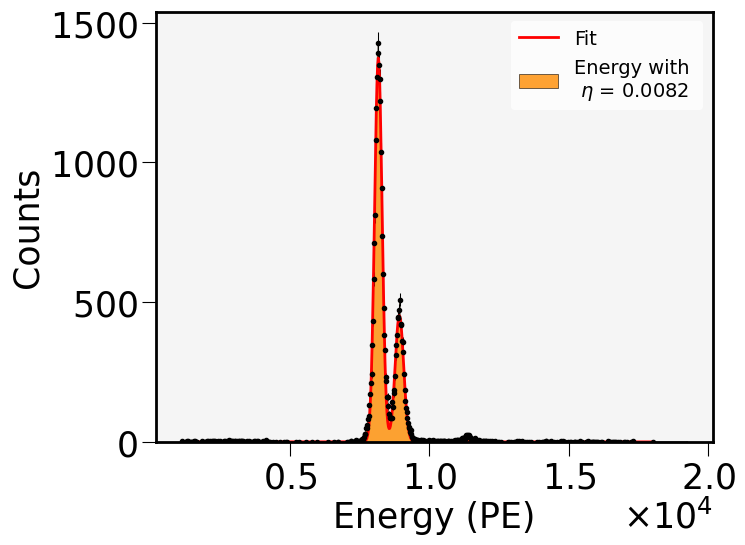

Initial values: [2000, 8698.979591836734, 25.56853223460603, 50, 10066.326530612245, 25.56853223460603]
Final values: [1375.61167063 8591.1637948   142.14500098  451.71561571 9384.26709797
  161.84576806]
Energy resolution: 3.8965%


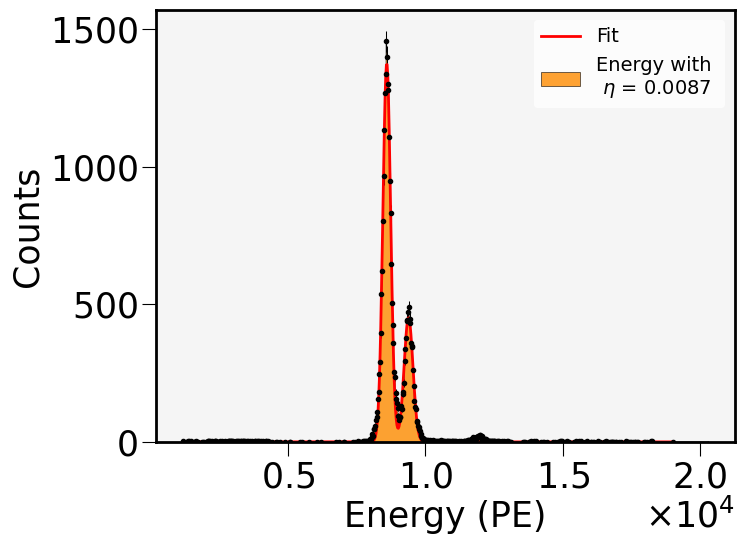

Initial values: [2000, 9122.448979591838, 26.946233451673148, 50, 10540.816326530614, 26.946233451673148]
Final values: [1374.5150968  9007.7283247   149.97295942  451.72397395 9838.9038378
  170.81220243]
Energy resolution: 3.9209%


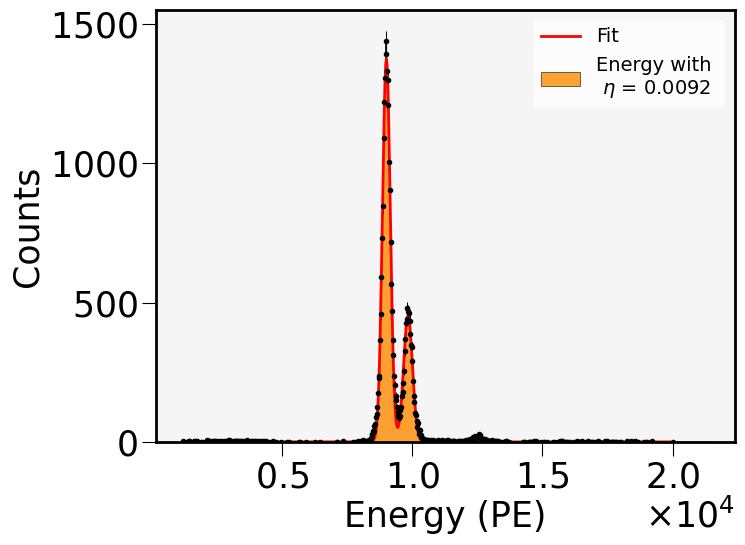

Initial values: [2000, 9545.918367346942, 28.32393466874026, 50, 11015.306122448981, 28.32393466874026]
Final values: [ 1374.05735189  9424.42083029   157.61903882   450.53756327
 10293.58197726   180.6341834 ]
Energy resolution: 3.9386%


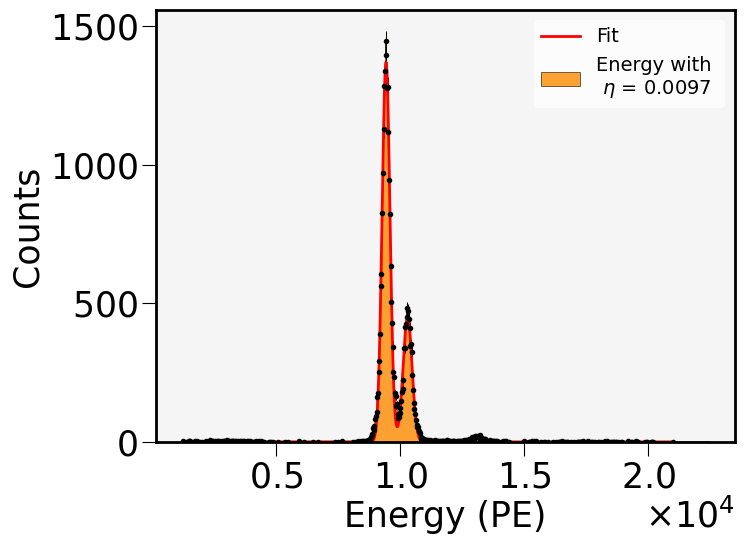

Initial values: [2000, 9969.387755102041, 29.708277835944397, 50, 11489.795918367348, 29.708277835944397]
Final values: [ 1372.18087803  9840.88420746   165.50868415   449.41232528
 10748.20995351   190.39249661]
Energy resolution: 3.9608%


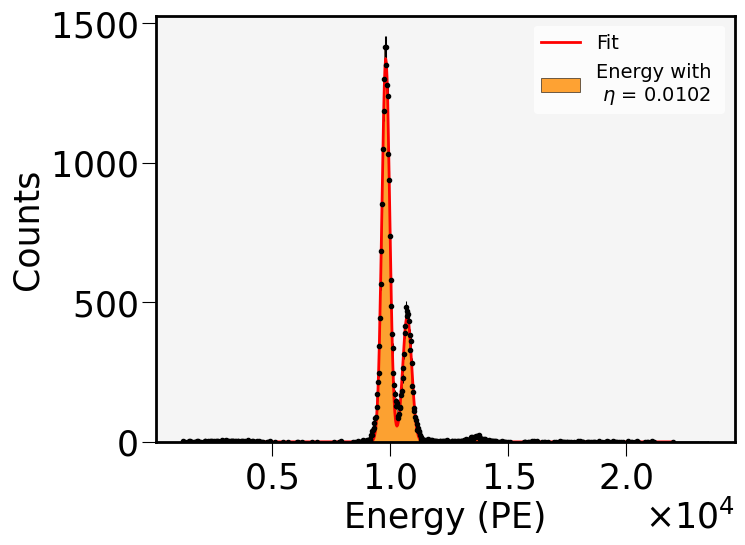

Initial values: [2000, 10392.857142857143, 31.09328498098521, 50, 11964.285714285714, 31.09328498098521]
Final values: [ 1371.04380429 10257.75956871   173.38652972   448.93884484
 11203.11500653   199.74916631]
Energy resolution: 3.9806%


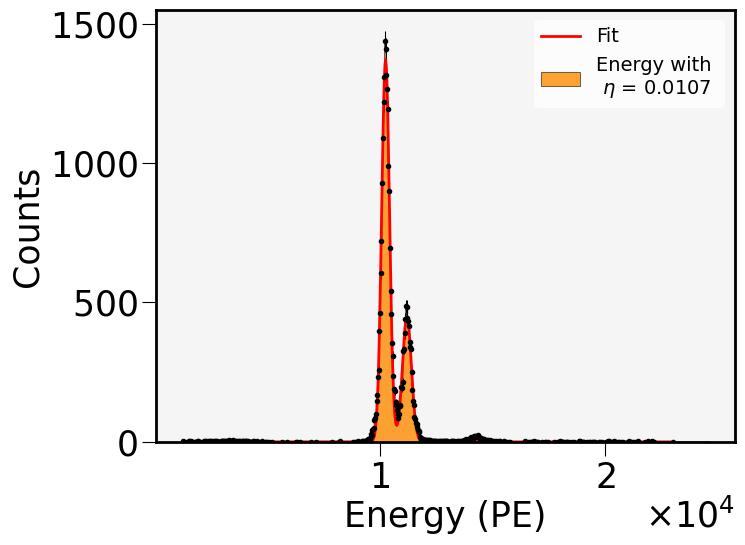

Initial values: [2000, 10816.326530612247, 32.47829212602603, 50, 12438.775510204083, 32.47829212602603]
Final values: [ 1371.07791791 10674.30050701   180.98262988   446.57274164
 11657.79508666   210.45097765]
Energy resolution: 3.9929%


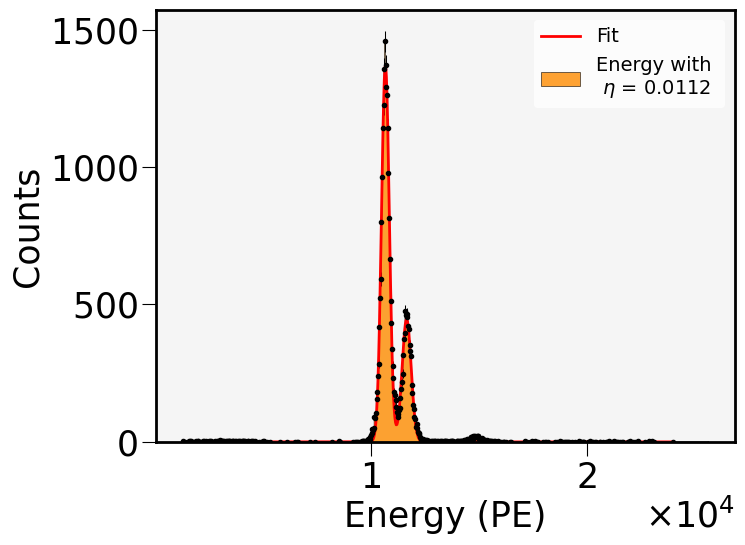

Initial values: [2000, 11239.795918367348, 33.86329927106684, 50, 12913.26530612245, 33.86329927106684]
Final values: [ 1368.5485261  11091.19549301   189.05716918   445.90554212
 12112.64867514   220.04131638]
Energy resolution: 4.0143%


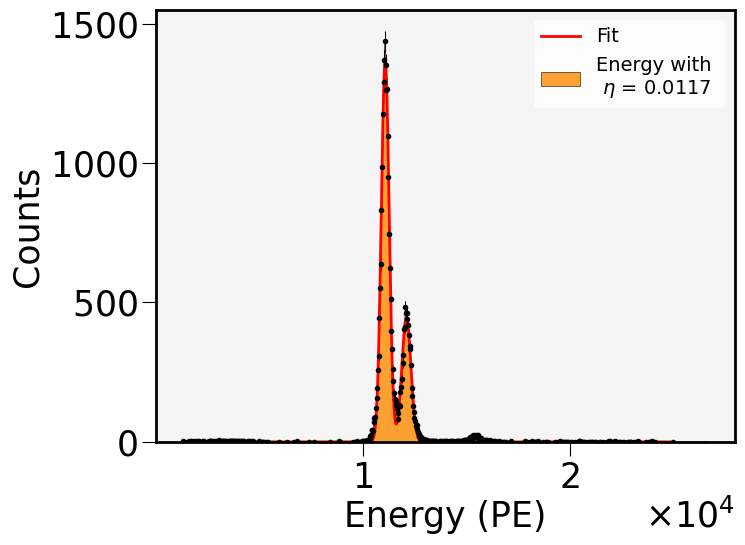

Initial values: [2000, 11663.26530612245, 35.24830641610765, 50, 13387.755102040817, 35.24830641610765]
Final values: [ 1365.22291581 11507.86799934   197.39645024   445.76843127
 12567.45715932   229.22276254]
Energy resolution: 4.0396%


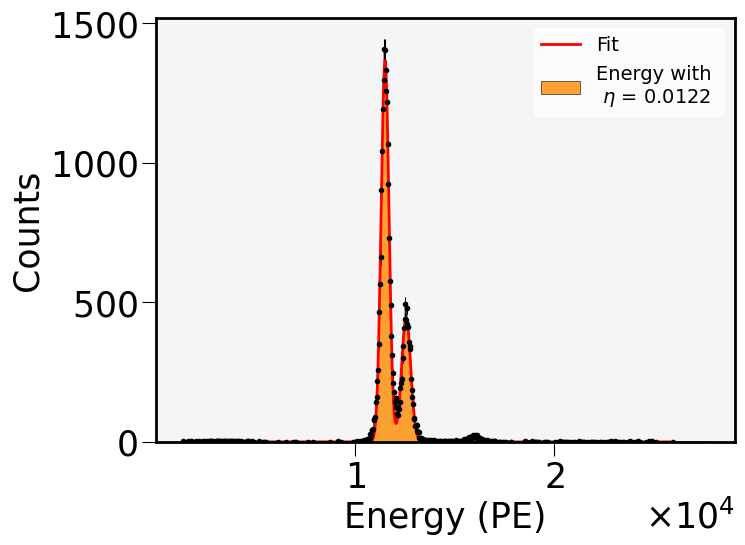

Initial values: [2000, 12086.734693877552, 36.63331356114847, 50, 13862.244897959185, 36.63331356114847]
Final values: [ 1363.53658155 11924.25029744   205.37198135   442.78127769
 13022.04167622   240.8951783 ]
Energy resolution: 4.0560%


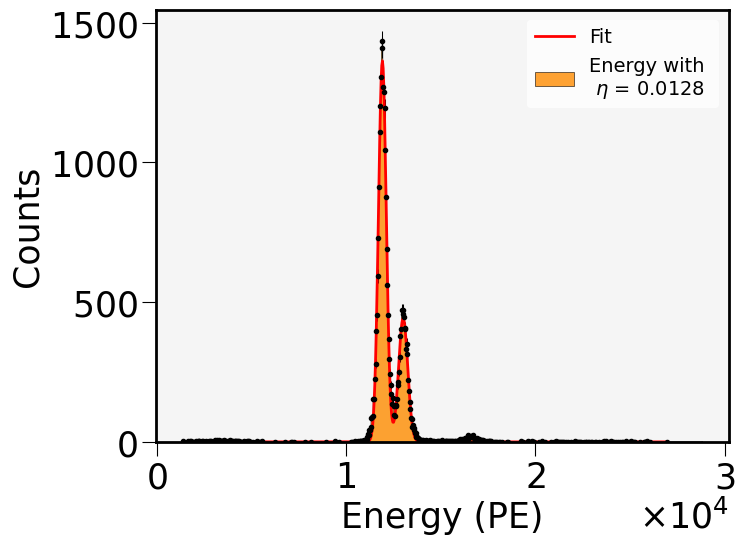

Initial values: [2000, 12510.204081632653, 38.01832070618929, 50, 14336.734693877552, 38.01832070618929]
Final values: [ 1362.28326874 12341.05948647   213.29500899   443.33749162
 13476.76270184   249.61380177]
Energy resolution: 4.0702%


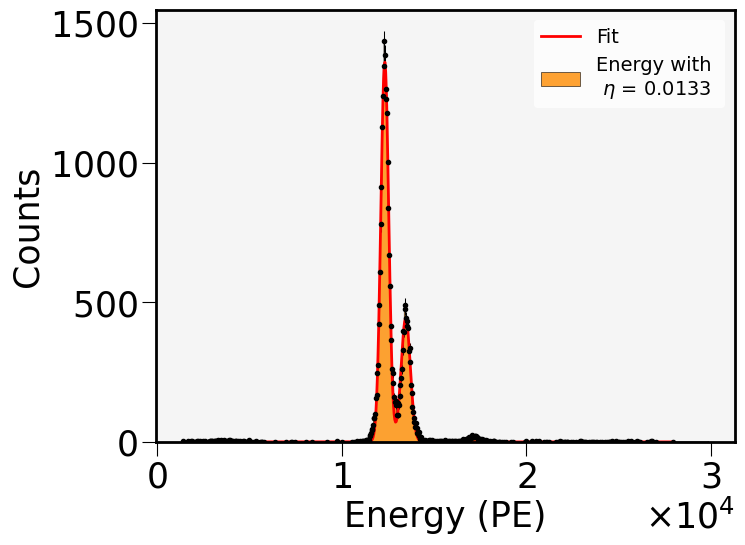

Initial values: [2000, 12933.673469387757, 39.4033278512301, 50, 14811.22448979592, 39.4033278512301]
Final values: [ 1358.43281527 12757.80526131   221.79105563   443.09828824
 13931.41430163  -258.87835045]
Energy resolution: 4.0941%


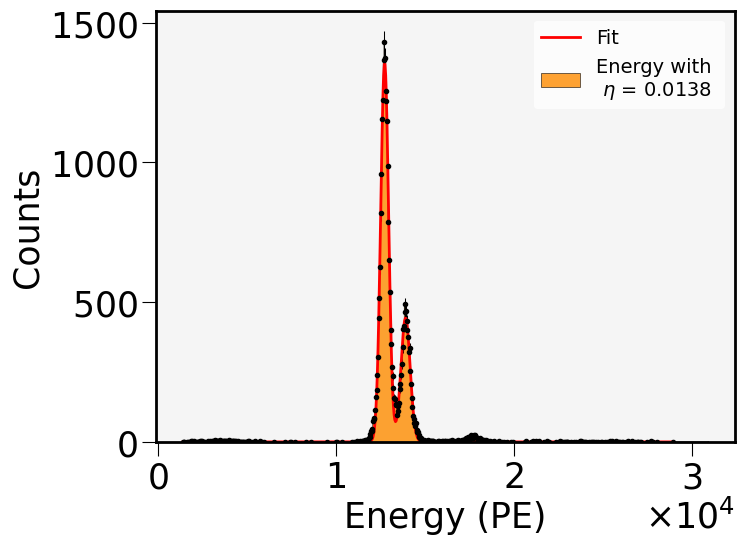

Initial values: [2000, 13357.142857142859, 40.78833499627092, 50, 15285.714285714286, 40.78833499627092]
Final values: [ 1356.78935512 13174.22672056   229.92885339   441.86837325
 14386.57269727   269.16105176]
Energy resolution: 4.1102%


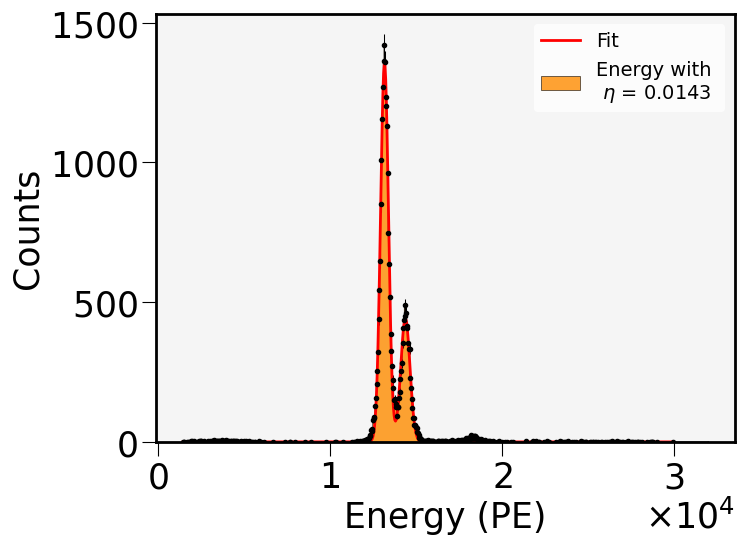

Initial values: [2000, 13780.61224489796, 42.17334214131173, 50, 15760.204081632653, 42.17334214131173]
Final values: [ 1356.48323021 13590.93328792   237.61763033   439.52545623
 14840.88244501  -280.90684101]
Energy resolution: 4.1174%


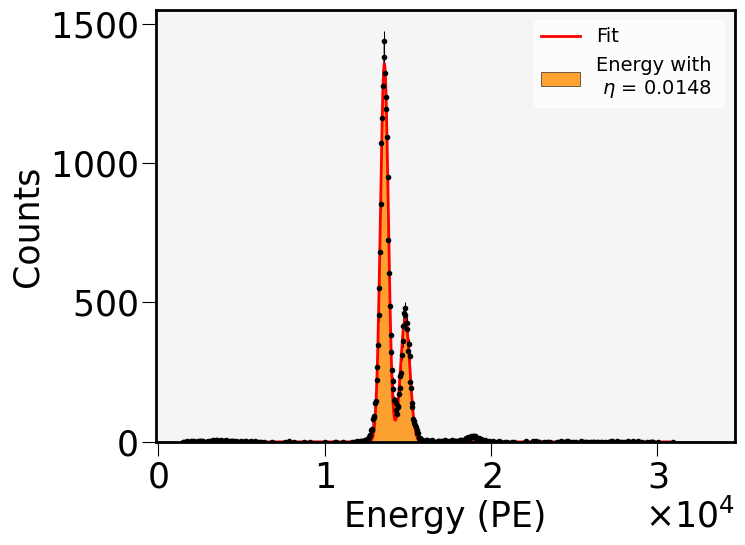

Initial values: [2000, 14204.081632653062, 43.55834928635256, 50, 16234.693877551023, 43.55834928635256]
Final values: [ 1355.71863402 14007.35919318   245.49445723   438.33911283
 15295.2890425    291.50781546]
Energy resolution: 4.1274%


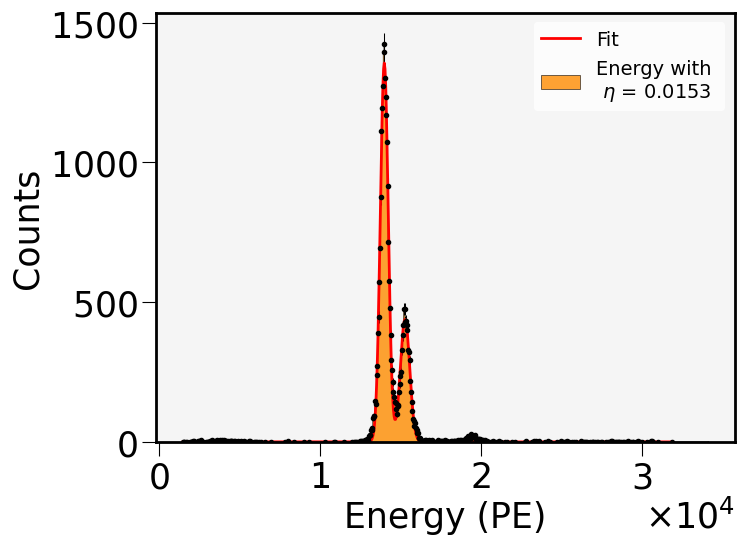

Initial values: [2000, 14627.551020408166, 44.94335643139337, 50, 16709.18367346939, 44.94335643139337]
Final values: [ 1353.52639958 14423.94605749   253.79679856   437.9820912
 15750.37938449   301.25628979]
Energy resolution: 4.1437%


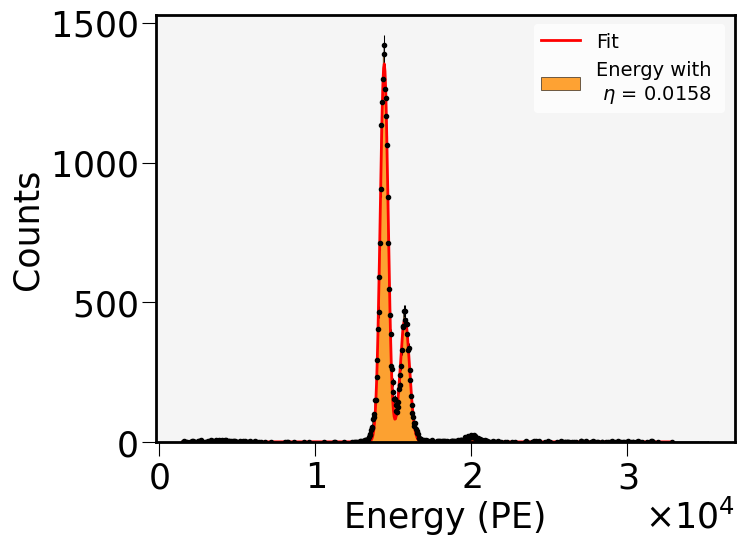

Initial values: [2000, 15051.020408163267, 46.328363576434185, 50, 17183.67346938776, 46.328363576434185]
Final values: [ 1350.29546371 14840.76668958   262.35619066   438.17421444
 16205.78602379  -310.23324595]
Energy resolution: 4.1632%


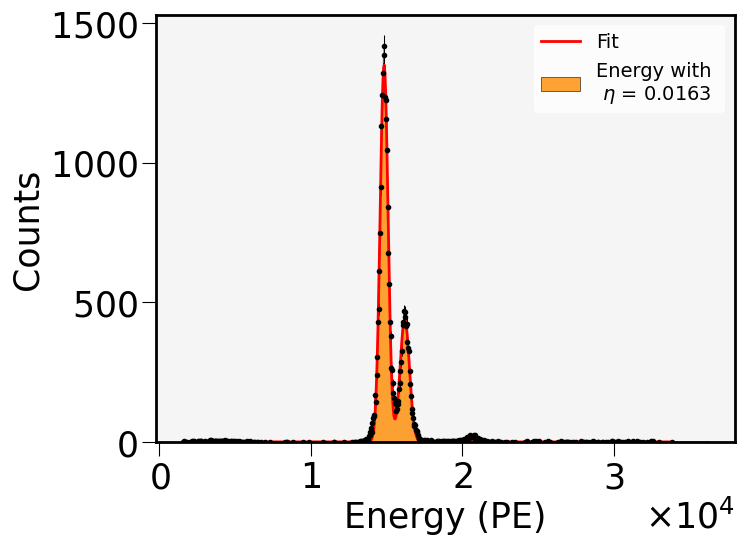

Initial values: [2000, 15474.489795918367, 47.713370721474995, 50, 17658.163265306124, 47.713370721474995]
Final values: [ 1348.47159675 15257.71595344   270.62800837   437.12502567
 16660.62852968  -320.6400465 ]
Energy resolution: 4.1771%


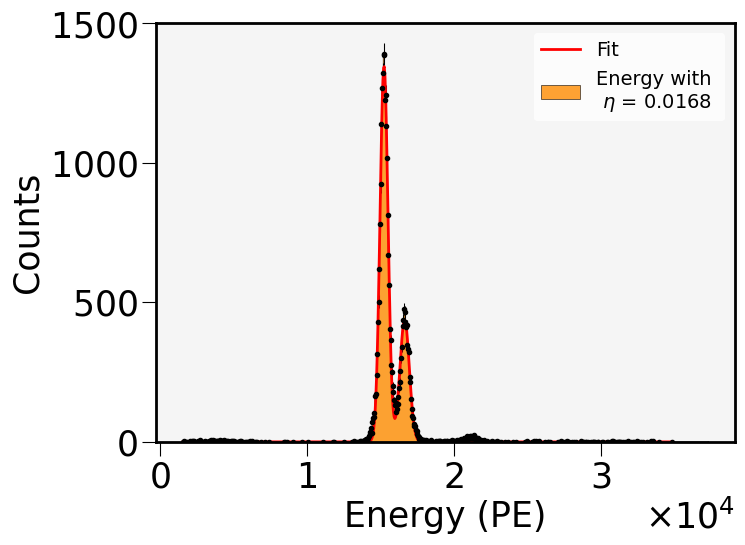

Initial values: [2000, 15897.959183673469, 49.09837786651581, 50, 18132.65306122449, 49.09837786651581]
Final values: [ 1346.97197896 15674.47267626   278.77238257   436.76020586
 17115.35222646  -330.41613074]
Energy resolution: 4.1884%


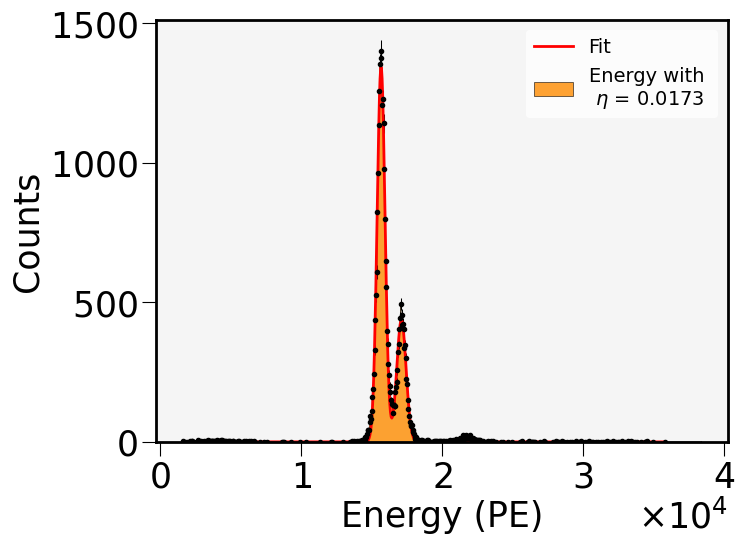

Initial values: [2000, 16321.428571428574, 50.483385011556635, 50, 18607.14285714286, 50.483385011556635]
Final values: [ 1344.29291737 16091.20948563   287.27308617   436.4083631
 17570.29306687   340.12938094]
Energy resolution: 4.2043%


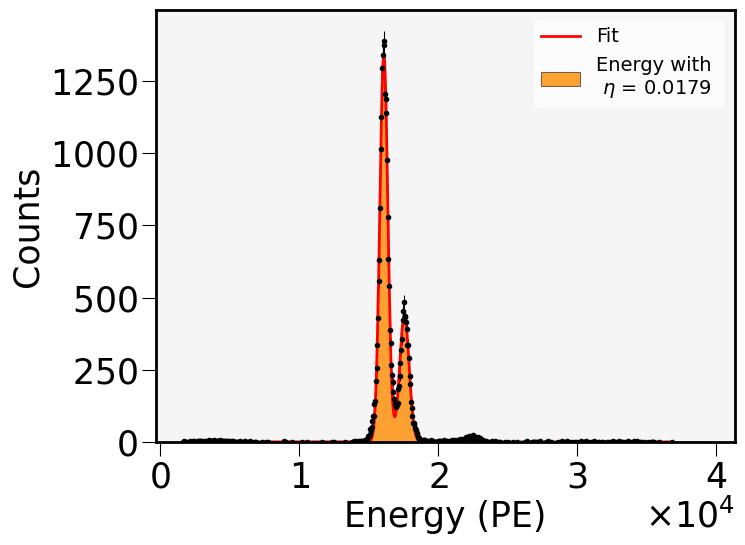

Initial values: [2000, 16744.897959183676, 51.86839215659744, 50, 19081.632653061228, 51.86839215659744]
Final values: [ 1.33261222e+03  1.65100325e+04  3.00806969e+02 -3.88645158e+00
 -4.26280626e+03  2.72733538e+02]
Energy resolution: 4.2907%


/lhome/ific/c/ccortesp/.local/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


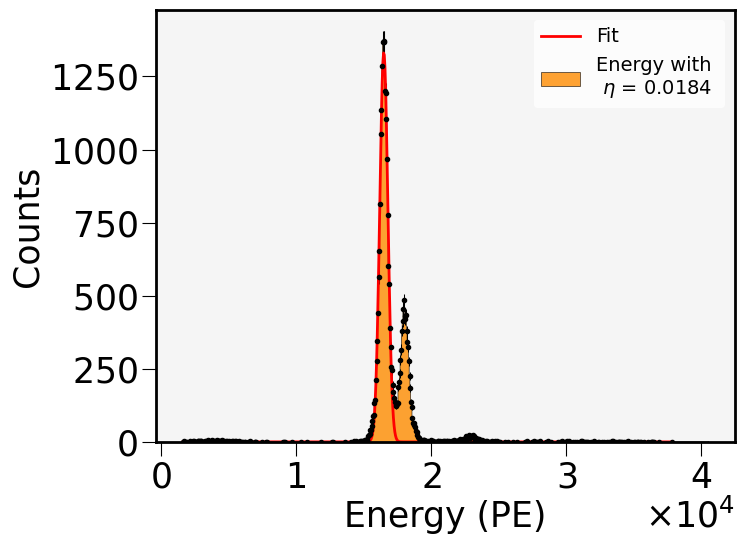

Initial values: [2000, 17168.367346938776, 53.25339930163826, 50, 19556.122448979593, 53.25339930163826]
Final values: [ 1331.56776988 16926.34133474   309.15661974   231.53352926
 -2391.55493233   -86.26471228]
Energy resolution: 4.3014%


/lhome/ific/c/ccortesp/.local/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


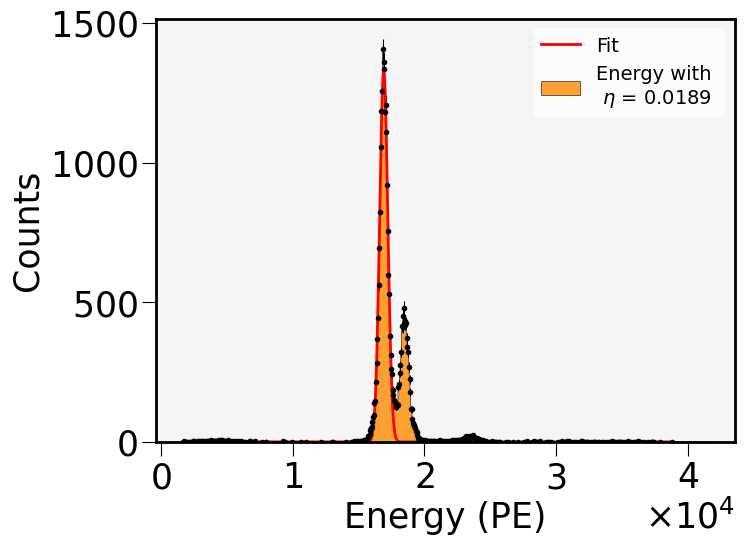

Initial values: [2000, 17591.836734693883, 54.63840644667908, 50, 20030.612244897962, 54.63840644667908]
Final values: [ 1340.23272924 17340.62499963   311.88142376   434.73188327
 18933.32460419   370.28472433]
Energy resolution: 4.2356%


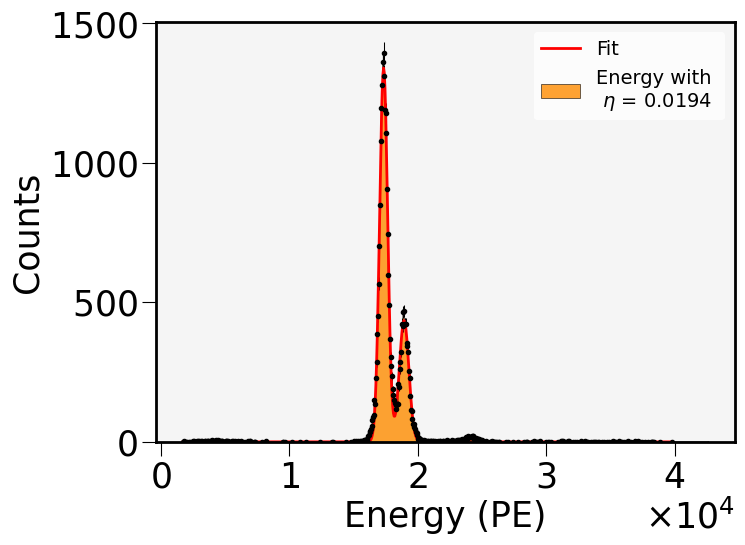

Initial values: [2000, 18015.306122448983, 56.023413591719894, 50, 20505.102040816328, 56.023413591719894]
Final values: [ 1.32914734e+03  1.77597981e+04  3.26066641e+02 -1.38115322e+00
  1.36365406e+04 -2.34229545e+00]
Energy resolution: 4.3237%


/lhome/ific/c/ccortesp/.local/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


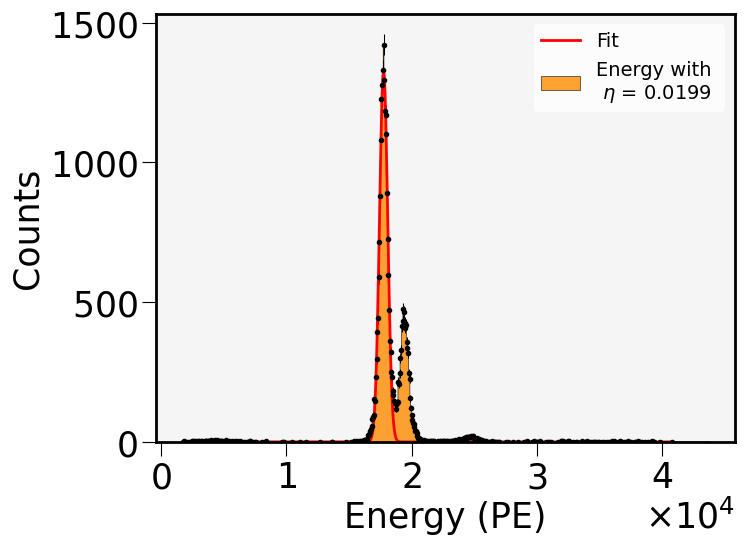

Initial values: [2000, 18438.775510204083, 57.40842073676072, 50, 20979.591836734697, 57.40842073676072]
Final values: [ 1337.93861609 18173.52463113   328.31691462   434.38123745
 19842.73064264   389.61803017]
Energy resolution: 4.2545%


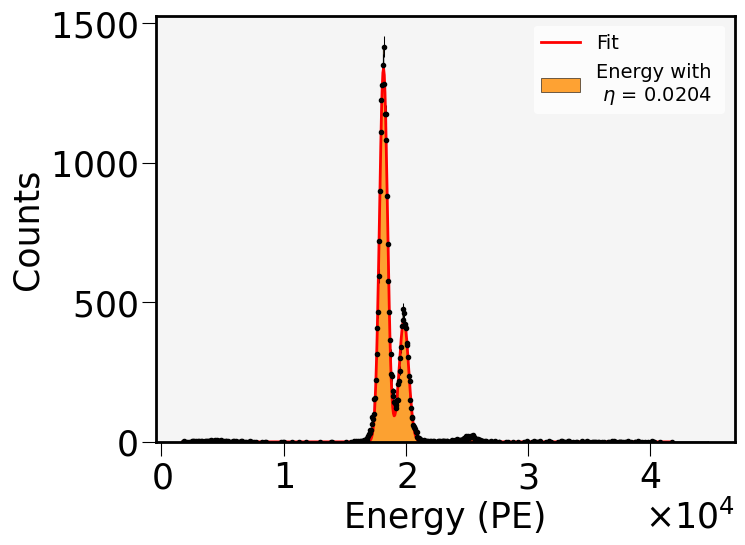

Initial values: [2000, 18862.244897959183, 58.79342788180152, 50, 21454.081632653062, 58.79342788180152]
Final values: [ 1336.38339091 18590.65247754   336.74441509   434.35106301
 20298.13462577   398.69128856]
Energy resolution: 4.2658%


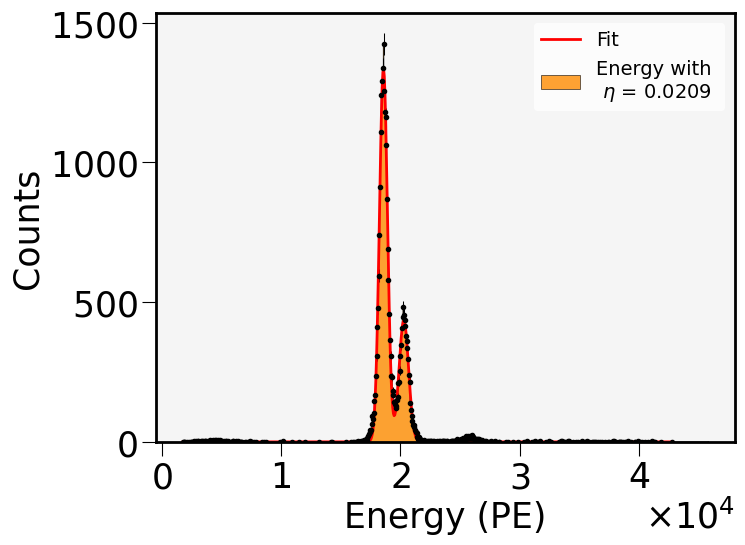

Initial values: [2000, 19285.714285714286, 60.178435026842344, 50, 21928.571428571428, 60.178435026842344]
Final values: [ 1335.88887892 19007.42224354   344.71951053   434.09590203
 20752.83453427  -408.56053784]
Energy resolution: 4.2710%


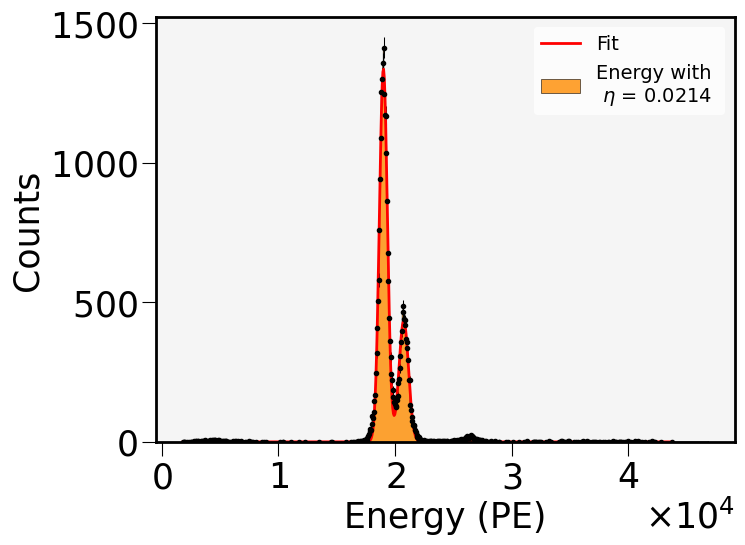

Initial values: [2000, 19709.18367346939, 61.563442171883146, 50, 22403.0612244898, 61.563442171883146]
Final values: [ 1334.5195715  19424.29035222   353.07642638   433.74101225
 21207.36845703   418.25884401]
Energy resolution: 4.2807%


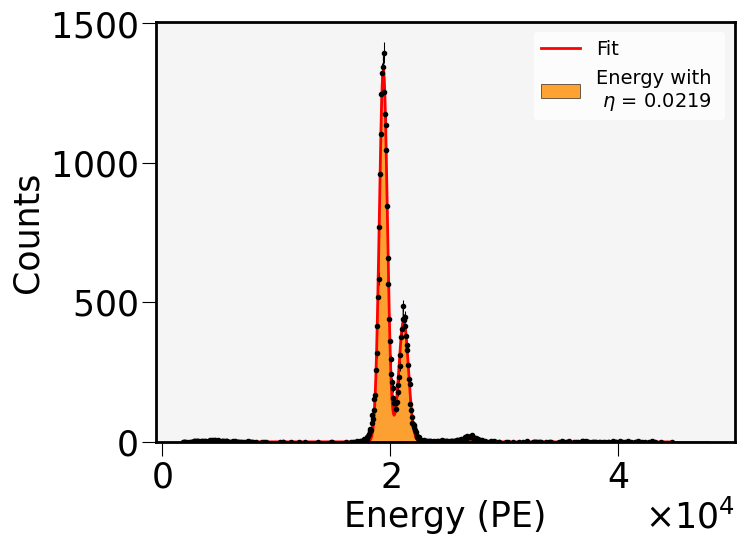

Initial values: [2000, 20132.653061224493, 62.94844931692397, 50, 22877.551020408166, 62.94844931692397]
Final values: [ 1332.8010388  19841.03695754   361.56110729   433.43781519
 21661.66799414   428.04547553]
Energy resolution: 4.2915%


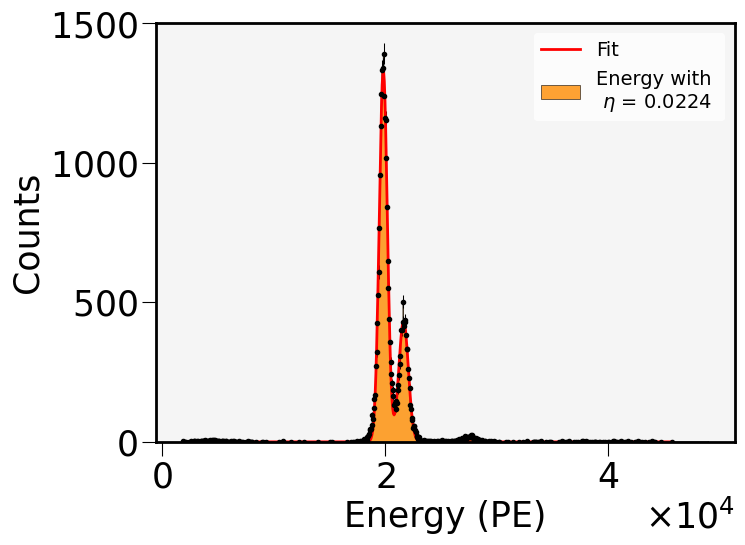

Initial values: [2000, 20556.122448979593, 64.33345646196477, 50, 23352.04081632653, 64.33345646196477]
Final values: [ 1330.96483128 20257.6688332    370.18450805   433.51050278
 22116.05729499   437.19421266]
Energy resolution: 4.3035%


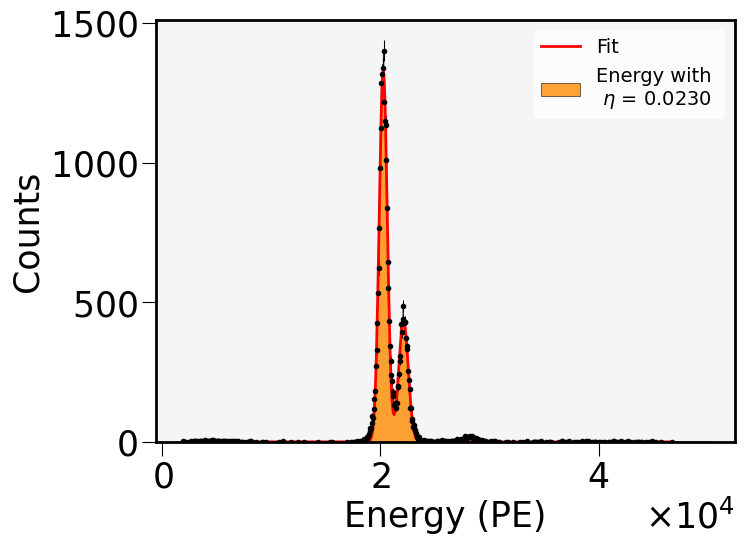

Initial values: [2000, 20979.591836734697, 65.7184636070056, 50, 23826.5306122449, 65.7184636070056]
Final values: [ 1328.9693531  20674.53918162   378.86947299   433.32421303
 22570.42734853   446.59277453]
Energy resolution: 4.3156%


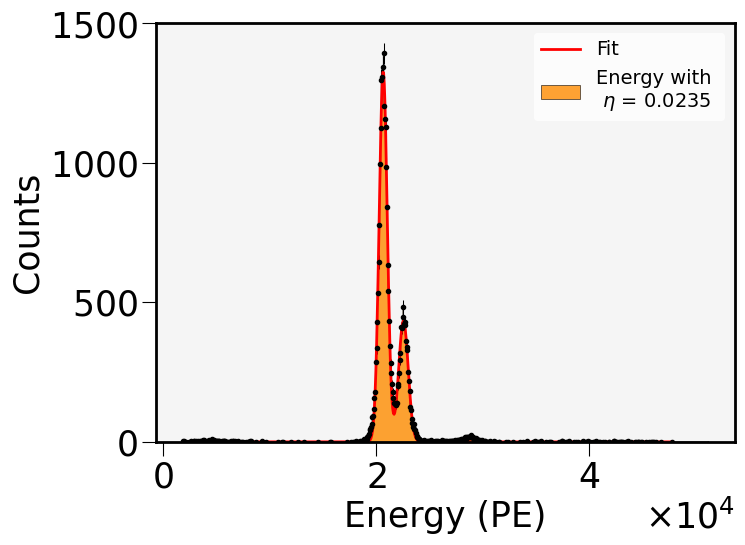

Initial values: [2000, 21403.0612244898, 67.10347075204642, 50, 24301.02040816327, 67.10347075204642]
Final values: [ 1329.17286965 21090.84726315   386.59493974   432.46273689
 23024.64894329   457.57989301]
Energy resolution: 4.3167%


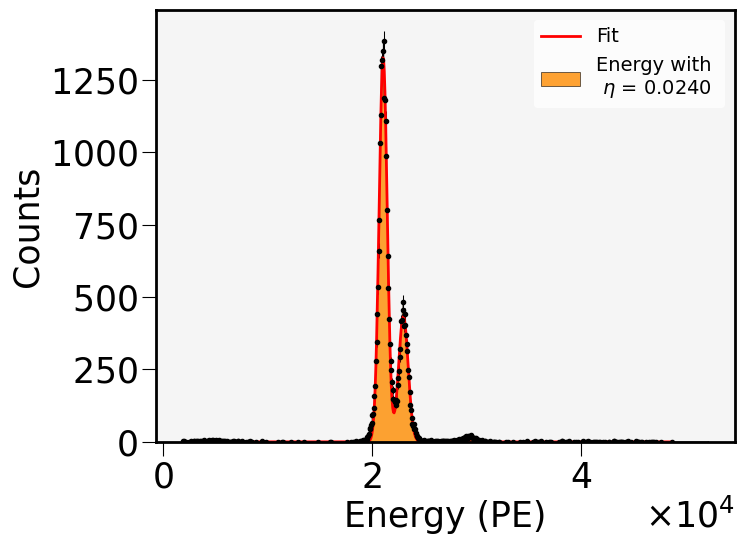

Initial values: [2000, 21826.5306122449, 68.48847789708722, 50, 24775.510204081635, 68.48847789708722]
Final values: [ 1327.96262422 21507.40938254   394.91997787   431.45794991
 23478.82392816   468.53083233]
Energy resolution: 4.3243%


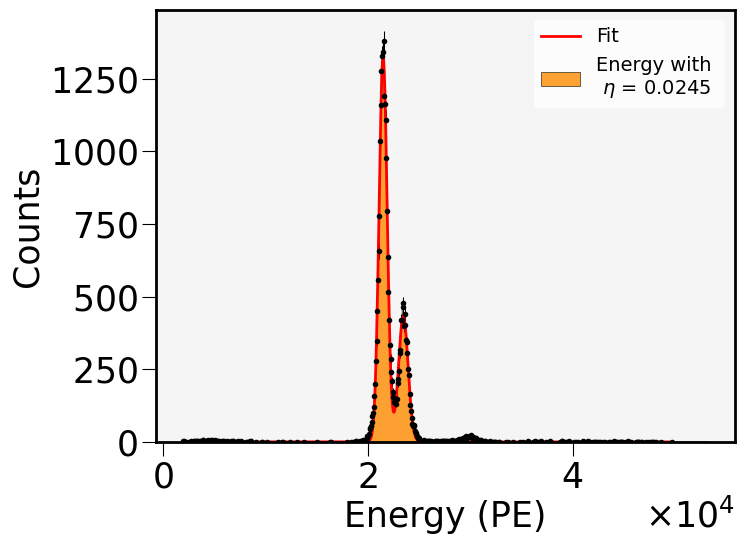

Initial values: [2000, 22250.0, 69.87348504212805, 50, 25250.0, 69.87348504212805]
Final values: [ 1324.52269342 21923.82250395   404.24927703   431.34049354
 23933.9925928    477.89578998]
Energy resolution: 4.3423%


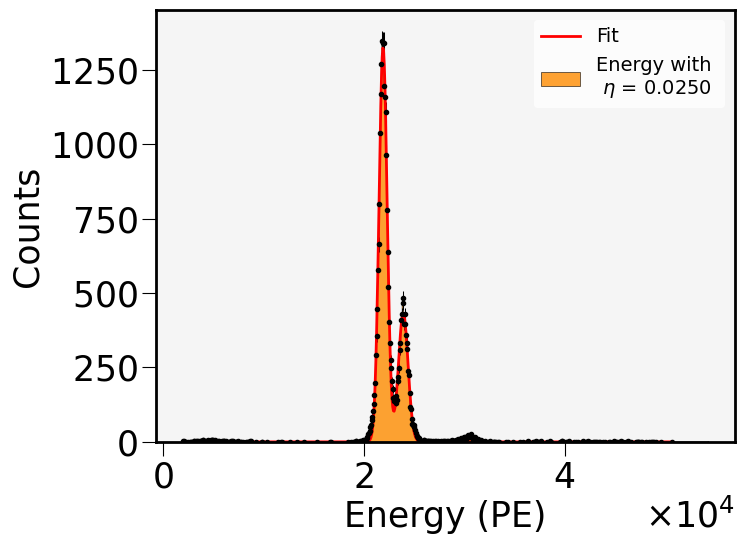

In [48]:
# Global
n_bins  = 750
rad_lim = 400

# Storage of the energy resolution values
E_resolution = []
eta_values = np.linspace(0, 0.025, 50)  # η variation

for eta in eta_values:

    # Run info
    data = ANA_DATA['High_Rn']['df']

    # Variables
    R = data['R']
    E1_corr = data['S1e_corr']
    E2_corr = data['S2e_corr']
    E_total = E1_corr + (E2_corr * eta)     # Energy estimator

    # Masking
    rad_mask = (R <= rad_lim)
    AV_mask  = ANA_DATA['High_Rn']['AV_mask']
    E_mask   = E_total[AV_mask & rad_mask]

    # Histogram
    E_counts, E_edges = np.histogram(E_mask, bins=n_bins)
    bin_width = np.diff(E_edges).mean()

    # ----- Bigaussian Fit ----- #
    # Preliminary
    E_min = 0       # 650e3
    E_max = 2000e3  # 1050e3

    # Filter the data for the fit
    fit_region_mask = (E_mask >= E_min) & (E_mask <= E_max)
    E_fit = E_mask[fit_region_mask]

    # Compute representative values for the fit
    E_centers, x_errors, E_values, y_errors = crudo.ff.prefit_1D(E_fit, E_edges)
    # Filter out points with zero error (bins with 1 event)
    valid_points = y_errors > 0
    E_centers = E_centers[valid_points];      x_errors = x_errors[valid_points]
    E_values  = E_values[valid_points];       y_errors = y_errors[valid_points]

    # Fit
    p0 = [2000, 1500 + (eta * 830e3), bin_width, 50, 2000 + (eta * 930e3), bin_width]
    print(f'Initial values: {p0}')
    popt, pcov = curve_fit(crudo.ff.bigauss_func, E_centers, E_values, p0=p0)

    # Results
    print(f'Final values: {popt}') 
    perr = np.sqrt(np.diag(pcov))

    # ----- Energy Resolution ----- #
    FWHM = 2.355 * popt[2]
    e_res = (FWHM / popt[1]) * 100
    E_resolution.append(e_res)
    print(f'Energy resolution: {e_res:.4f}%')

    # ----- Plotting ----- #
    plt.figure(figsize=(8, 6))

    # Data
    plt.stairs(E_counts, E_edges, label=f'Energy with \n $\\eta$ = {eta:.4f}', 
               fill=True, color=crudo.pt.hist_colors[2], alpha=0.8, lw=0.5, ec='black')
    plt.errorbar(E_centers, E_values, xerr=x_errors, yerr=y_errors, fmt='o', ms=3, c='black', ecolor='black', elinewidth=0.75)
    
    # Fit
    fit_y = crudo.ff.bigauss_func(E_centers, *popt)
    plt.plot(E_centers, fit_y, color="red", label="Fit")

    # ----- Styling ----- #
    plt.xlabel('Energy (PE)')
    # plt.xlim(5500, 9500)
    plt.ylabel('Counts')
    plt.legend(loc='best', fontsize=14)

    plt.gca().set_facecolor("whitesmoke")
    plt.tight_layout()
    plt.show()

#### What's the best $\eta$?

The minimum energy resolution is 3.83% at η = 0.0061


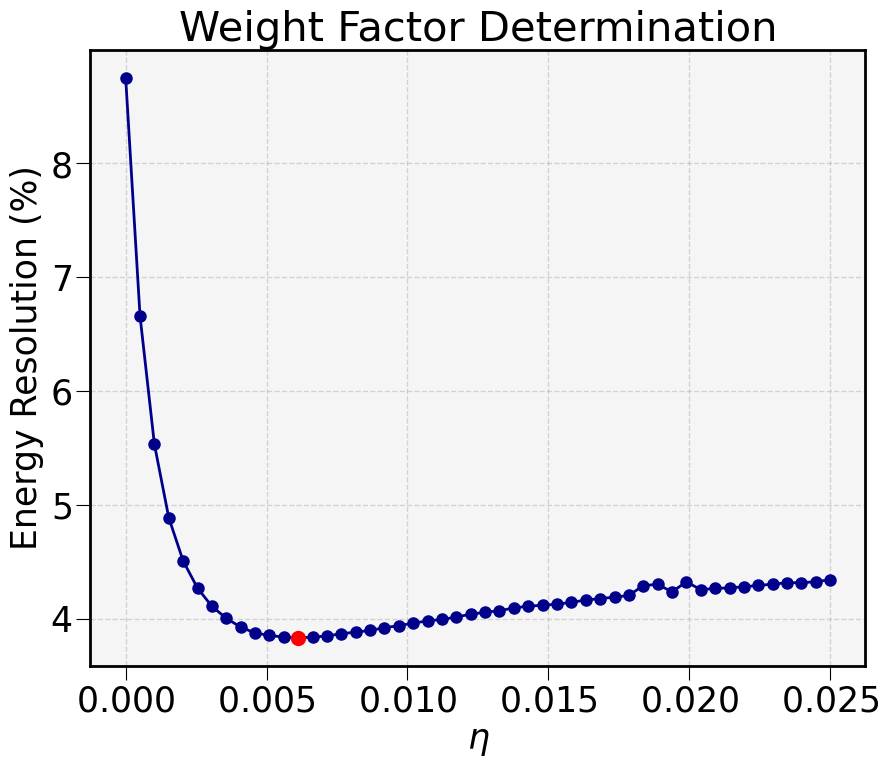

In [49]:
# Find the minimum energy resolution and corresponding eta value
min_index = np.argmin(E_resolution)
Best_eta = eta_values[min_index]
Best_res = E_resolution[min_index]

print(f"The minimum energy resolution is {Best_res:.2f}% at η = {Best_eta:.4f}")

# Store information
ANA_DATA['High_Rn']['eta_CV'] = Best_eta
ANA_DATA['Low_Rn']['eta_CV']  = Best_eta

# Plot
# plt.figure(figsize=(8, 6))
plt.plot(eta_values, E_resolution, c='darkblue', marker='o')
plt.scatter([Best_eta], [Best_res], c='red', zorder=3)
plt.xlabel('$\\eta$')
plt.ylabel('Energy Resolution (%)')
plt.title('Weight Factor Determination')

plt.grid(True)
plt.gca().set_facecolor('whitesmoke')
plt.show()

## $\lambda$ Determination

### High-Rn

High-Rn - Initial values:
222Rn: N_1 = 1.0000, μ_1 = 6500.00 PE, σ_1 = 15.81 PE

High-Rn - Fit values:
222Rn: N_1 = (1.0947e+03 ± 1.0417e+01), μ_1 = (6508.32 ± 0.82) PE, σ_1 = (112.22 ± 0.72) PE
222Rn: λ = 0.8589 keV/PE
χ² / ndof = 5.8171


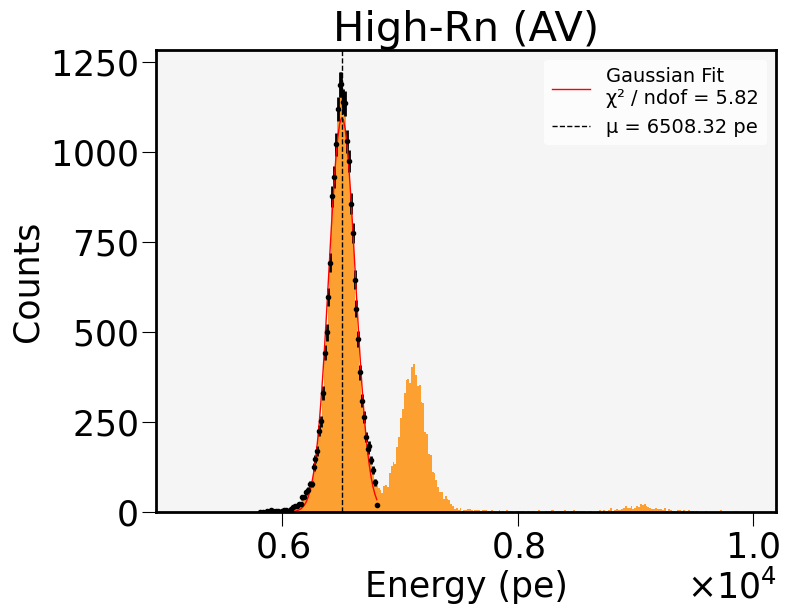

In [50]:
# Global
n_bins  = 1000
rad_lim = 400
E_Rn = 5590.3   # [keV] 222Rn energy peak

# High-Rn info
Rn_data = ANA_DATA['High_Rn']['df']
eta = ANA_DATA['High_Rn']['eta_CV']

# Variables
R = Rn_data['R']
E1_corr = Rn_data['S1e_corr']
E2_corr = Rn_data['S2e_corr']
E_total = E1_corr + (E2_corr * eta)  # Energy estimator

# Masking
rad_mask = (R <= rad_lim)
AV_mask  = ANA_DATA['High_Rn']['AV_mask']
E_mask   = E_total[AV_mask & rad_mask]

# Histogram
E_counts, E_edges = np.histogram(E_mask, bins=n_bins, range=(0, E_total.max()))
bin_width = np.diff(E_edges).mean()

# ----- Gaussian Fit ----- #
# Preliminary
E_min = 5.8e3;  E_max = 6.8e3

# Filter the data for the fit
fit_region_mask = (E_mask >= E_min) & (E_mask <= E_max)
E_fit = E_mask[fit_region_mask]

# Compute representative values for the fit
E_centers, x_errors, E_values, y_errors = crudo.ff.prefit_1D(E_fit, E_edges)
# Filter out points with zero error (bins with 1 event)
valid_points = y_errors > 0
E_centers = E_centers[valid_points];      x_errors = x_errors[valid_points]
E_values  = E_values[valid_points];       y_errors = y_errors[valid_points]

# Definte the cost function + initial guess
least_squares = LeastSquares(E_centers, E_values, y_errors, crudo.ff.gauss_func)
init_guess    = [1, 6500, bin_width]
print(f'High-Rn - Initial values:')
print(f"222Rn: N_1 = {init_guess[0]:.4f}, μ_1 = {init_guess[1]:.2f} PE, σ_1 = {init_guess[2]:.2f} PE")

# Define the Minuit object
m = Minuit(least_squares, A1=init_guess[0], mu1=init_guess[1], sigma1=init_guess[2])

# Apply soft bounds to the parameters
m.limits['mu1'] = (6250, 6750);  m.limits['sigma1'] = (0.5*bin_width, np.inf)

# Minimization process of the cost function and error estimation
m.migrad()
m.hesse()

# Results
popt = m.values;  perr = m.errors
print(f'\nHigh-Rn - Fit values:')
print(f"222Rn: N_1 = ({popt[0]:.4e} ± {perr[0]:.4e}), μ_1 = ({popt[1]:.2f} ± {perr[1]:.2f}) PE, σ_1 = ({popt[2]:.2f} ± {perr[2]:.2f}) PE")

# Lambda value
High_lambda = E_Rn / (popt[1])
print(f"222Rn: λ = {High_lambda:.4f} keV/PE")
ANA_DATA['High_Rn']['lambda_CV'] = High_lambda

# Reduced chi-square
chi2 = m.fval
ndof = len(E_centers) - m.nfit
print(f"χ² / ndof = {chi2 / ndof:.4f}")

# ----- Plotting ----- #
plt.figure(figsize=(8, 6))

# Data 
plt.bar(E_edges[:-1], E_counts, width=bin_width, align='edge',
        color=crudo.pt.hist_colors[2], alpha=0.8, lw=1.0)

# Fit
y_fit = crudo.ff.gauss_func(E_centers, *popt)
plt.errorbar(E_centers, E_values, yerr=y_errors, fmt='o', ms=3, c='black', ecolor='black')                                 
plt.plot(E_centers, y_fit, color="red", lw=1.0, label=f'Gaussian Fit\nχ² / ndof = {chi2 / ndof:.2f}')
plt.axvline(x=popt[1], c='black', alpha=1, ls='--', lw=1.0, label=f'μ = {popt[1]:.2f} pe')

# Styling                      
plt.xlabel('Energy (pe)')
plt.xlim(0.85*E_min, 1.5*E_max)
plt.ylabel('Counts')
# plt.yscale('log')
plt.title(f'High-Rn (AV)')
plt.legend(loc='upper right', fontsize=14)    
plt.gca().set_facecolor("whitesmoke")

# plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

### Low-Rn

Low-Rn - Initial values:
222Rn: N_1 = 1.0000, μ_1 = 7000.00 PE, σ_1 = 22.07 PE

Low-Rn - Fit values:
222Rn: N_1 = (6.1810e+02 ± 8.3082e+00), μ_1 = (7225.44 ± 1.43) PE, σ_1 = (139.00 ± 1.25) PE
222Rn: λ = 0.7737 keV/PE
χ² / ndof = 3.2787


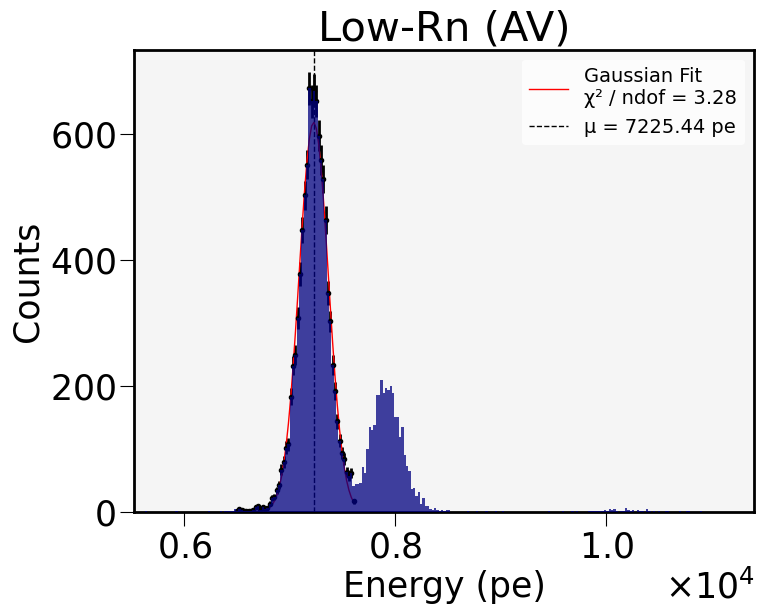

In [51]:
# Global
n_bins  = 1000
rad_lim = 400
E_Rn = 5590.3   # [keV] 222Rn energy peak

# Low-Rn info
Rn_data = ANA_DATA['Low_Rn']['df']
eta = ANA_DATA['Low_Rn']['eta_CV']

# Variables
R = Rn_data['R']
E1_corr = Rn_data['S1e_corr']
E2_corr = Rn_data['S2e_corr']
E_total = E1_corr + (E2_corr * eta)  # Energy estimator

# Masking
rad_mask = (R <= rad_lim)
AV_mask  = ANA_DATA['Low_Rn']['AV_mask']
E_mask   = E_total[AV_mask & rad_mask]

# Histogram
E_counts, E_edges = np.histogram(E_mask, bins=n_bins, range=(0, E_total.max()))
bin_width = np.diff(E_edges).mean()

# ----- Gaussian Fit ----- #
# Preliminary
E_min = 6.5e3;  E_max = 7.6e3

# Filter the data for the fit
fit_region_mask = (E_mask >= E_min) & (E_mask <= E_max)
E_fit = E_mask[fit_region_mask]

# Compute representative values for the fit
E_centers, x_errors, E_values, y_errors = crudo.ff.prefit_1D(E_fit, E_edges)
# Filter out points with zero error (bins with 1 event)
valid_points = y_errors > 0
E_centers = E_centers[valid_points];      x_errors = x_errors[valid_points]
E_values  = E_values[valid_points];       y_errors = y_errors[valid_points]

# Definte the cost function + initial guess
least_squares = LeastSquares(E_centers, E_values, y_errors, crudo.ff.gauss_func)
init_guess    = [1, 7000, bin_width]
print(f'Low-Rn - Initial values:')
print(f"222Rn: N_1 = {init_guess[0]:.4f}, μ_1 = {init_guess[1]:.2f} PE, σ_1 = {init_guess[2]:.2f} PE")

# Define the Minuit object
m = Minuit(least_squares, A1=init_guess[0], mu1=init_guess[1], sigma1=init_guess[2])

# Apply soft bounds to the parameters
m.limits['mu1'] = (6750, 7250);  m.limits['sigma1'] = (0.5*bin_width, np.inf)

# Minimization process of the cost function and error estimation
m.migrad()
m.hesse()

# Results
popt = m.values;  perr = m.errors
print(f'\nLow-Rn - Fit values:')
print(f"222Rn: N_1 = ({popt[0]:.4e} ± {perr[0]:.4e}), μ_1 = ({popt[1]:.2f} ± {perr[1]:.2f}) PE, σ_1 = ({popt[2]:.2f} ± {perr[2]:.2f}) PE")

# Lambda value
Low_lambda = E_Rn / (popt[1])
print(f"222Rn: λ = {Low_lambda:.4f} keV/PE")
ANA_DATA['Low_Rn']['lambda_CV'] = Low_lambda

# Reduced chi-square
chi2 = m.fval
ndof = len(E_centers) - m.nfit
print(f"χ² / ndof = {chi2 / ndof:.4f}")

# ----- Plotting ----- #
plt.figure(figsize=(8, 6))

# Data 
plt.bar(E_edges[:-1], E_counts, width=bin_width, align='edge',
        color=crudo.pt.hist_colors[5], alpha=0.75, lw=1.0, zorder=3)

# Fit
y_fit = crudo.ff.gauss_func(E_centers, *popt)
plt.errorbar(E_centers, E_values, yerr=y_errors, fmt='o', ms=3, c='black', ecolor='black')                                 
plt.plot(E_centers, y_fit, color="red", lw=1.0, label=f'Gaussian Fit\nχ² / ndof = {chi2 / ndof:.2f}')
plt.axvline(x=popt[1], c='black', alpha=1.0, ls='--', lw=1.0, label=f'μ = {popt[1]:.2f} pe')

# Styling                      
plt.xlabel('Energy (pe)')
plt.xlim(0.85*E_min, 1.5*E_max)
plt.ylabel('Counts')
# plt.yscale('log')
plt.title(f'Low-Rn (AV)')
plt.legend(loc='upper right', fontsize=14) 

plt.gca().set_facecolor("whitesmoke")
plt.show()

# α-Producing Isotopes

### Configuration

In [62]:
# Choose your period of interest
PERIOD = 'High_Rn'   # 'High_Rn' or 'Low_Rn'

# ----- Period Information ----- #
# Data information
Rn_data        = ANA_DATA[PERIOD]['df']
Rn_long        = ANA_DATA[PERIOD]['duration_CV']
Alpha_rate_CV  = ANA_DATA[PERIOD]['alpha_rate_CV']
Alpha_rate_err = ANA_DATA[PERIOD]['alpha_rate_err']

# Active volume
AV_mask       = ANA_DATA[PERIOD]['AV_mask']
DT_stop_CV    = ANA_DATA[PERIOD]['DTstop_CV']
DT_stop_err   = ANA_DATA[PERIOD]['DTstop_err']
Drift_vel_CV  = ANA_DATA[PERIOD]['drift_vel_CV']
Drift_vel_err = ANA_DATA[PERIOD]['drift_vel_err']
Rad_lim = 400       # in [mm]

# Energy Estimator
Eta_CV        = ANA_DATA[PERIOD]['eta_CV']
Lambda_CV     = ANA_DATA[PERIOD]['lambda_CV']

### Histogram

In [63]:
# Global
n_bins = 250

# Variables
R = Rn_data['R']
E1_corr = Rn_data['S1e_corr']
E2_corr = Rn_data['S2e_corr']
E_total = Lambda_CV * (E1_corr + (E2_corr * Eta_CV))        # Energy estimator

# Masking
rad_mask = (R <= Rad_lim)
E_mask   = E_total[AV_mask & rad_mask]

# Histogram: normalized by corrected DAQ data taking time
E_counts, E_edges = np.histogram(E_mask, bins=n_bins, range=(E_mask.min(), E_mask.max()))
E_rate  = E_counts / Rn_long
E_error = np.sqrt(E_counts) / Rn_long       # Only statistical error
bin_width = np.diff(E_edges).mean()

# ----- Selection Rate ----- #
sel_rate_CV  = np.sum(E_rate)                       
sel_rate_err = np.sqrt(np.sum(E_error**2))
print(f'{PERIOD}:\n Energy window  = [{E_mask.min():.2f}, {E_mask.max():.2f}] keV\n Selection rate = ({sel_rate_CV:.4f} ± {sel_rate_err:.4f}) Hz')

High_Rn:
 Energy window  = [857.60, 12891.45] keV
 Selection rate = (0.6109 ± 0.0037) Hz


### Tri-Gaussian Fit

In [64]:
# # Filter the data for the fit
# fit_region_mask = (E_mask >= E_min) & (E_mask <= E_max)
# E_fit = E_mask[fit_region_mask]

# Compute representative values for the fit: remember, we're working with rates!
x_centers, x_errors, y_values, y_errors = crudo.ff.prefit_1D(E_mask, bins=E_edges)
y_values = y_values.astype(np.float64)      # We divide by a float: Rn_long
y_values /= Rn_long
y_errors /= Rn_long

# Filter out poitns with zero error
valid_points = y_errors > 0
x_centers = x_centers[valid_points];    x_errors = x_errors[valid_points]
y_values  = y_values[valid_points];     y_errors = y_errors[valid_points]

# Definte the cost function + initial guess
least_squares = LeastSquares(x_centers, y_values, y_errors, crudo.ff.trigauss_func)
init_guess    = [1, 5600, bin_width, 1, 6100, bin_width, 1, 7850, bin_width]
print(f'{PERIOD} - Initial values:\n')
print(f"222Rn: N_1 = {init_guess[0]:.2f} Hz, μ_1 = {init_guess[1]:.2f} keV, σ_1 = {init_guess[2]:.2f} keV")
print(f"218Po: N_2 = {init_guess[3]:.2f} Hz, μ_2 = {init_guess[4]:.2f} keV, σ_2 = {init_guess[5]:.2f} keV")
print(f"214Po: N_3 = {init_guess[6]:.2f} Hz, μ_3 = {init_guess[7]:.2f} keV, σ_3 = {init_guess[8]:.2f} keV\n")

# Define the Minuit object
m = Minuit(least_squares, A1=init_guess[0], mu1=init_guess[1], sigma1=init_guess[2],
                          A2=init_guess[3], mu2=init_guess[4], sigma2=init_guess[5],
                          A3=init_guess[6], mu3=init_guess[7], sigma3=init_guess[8])

# Apply soft bounds to the parameters
m.limits['mu1'] = (5400, 5800);  m.limits['sigma1'] = (0.5*bin_width, np.inf)
m.limits['mu2'] = (5900, 6300);  m.limits['sigma2'] = (0.5*bin_width, np.inf)
m.limits['mu3'] = (7550, 8150);  m.limits['sigma3'] = (0.5*bin_width, 1000 if PERIOD == 'Low_Rn' else np.inf)

# Minimization process of the cost function and error estimation
m.migrad()
m.hesse()

# Results
popt = m.values;  perr = m.errors
print(f'{PERIOD} - Fit values:\n')
print(f"222Rn: N_1 = ({popt[0]:.4e} ± {perr[0]:.4e}) Hz, μ_1 = ({popt[1]:.2f} ± {perr[1]:.2f}) keV, σ_1 = ({popt[2]:.2f} ± {perr[2]:.2f}) keV")
print(f"218Po: N_2 = ({popt[3]:.4e} ± {perr[3]:.4e}) Hz, μ_2 = ({popt[4]:.2f} ± {perr[4]:.2f}) keV, σ_2 = ({popt[5]:.2f} ± {perr[5]:.2f}) keV")
print(f"214Po: N_3 = ({popt[6]:.4e} ± {perr[6]:.4e}) Hz, μ_3 = ({popt[7]:.2f} ± {perr[7]:.2f}) keV, σ_3 = ({popt[8]:.2f} ± {perr[8]:.2f}) keV")

# Reduced chi-square
chi2 = m.fval
ndof = len(x_centers) - m.nfit
print(f"χ² / ndof = {chi2 / ndof:.4f}")

# ----- Store Fit Results ----- #
Isotopes = {name: {key: val for key, val in zip(['N_CV', 'mu_CV', 'sigma_CV', 'N_err', 'mu_err', 'sigma_err'], popt[i:i+3] + perr[i:i+3])} 
            for i, name in zip(range(0, 9, 3), ['222Rn', '218Po', '214Po'])}
ANA_DATA[PERIOD]['Isotopes'] = Isotopes

High_Rn - Initial values:

222Rn: N_1 = 1.00 Hz, μ_1 = 5600.00 keV, σ_1 = 48.14 keV
218Po: N_2 = 1.00 Hz, μ_2 = 6100.00 keV, σ_2 = 48.14 keV
214Po: N_3 = 1.00 Hz, μ_3 = 7850.00 keV, σ_3 = 48.14 keV

High_Rn - Fit values:

222Rn: N_1 = (8.3138e-02 ± 8.0341e-04) Hz, μ_1 = (5590.56 ± 0.73) keV, σ_1 = (98.87 ± 0.67) keV
218Po: N_2 = (2.7662e-02 ± 4.6137e-04) Hz, μ_2 = (6107.18 ± 1.35) keV, σ_2 = (108.01 ± 1.36) keV
214Po: N_3 = (1.5039e-03 ± 1.1145e-04) Hz, μ_3 = (7784.74 ± 8.18) keV, σ_3 = (82.74 ± 10.63) keV
χ² / ndof = 5.2802


### Rn Activity

In [65]:
print(f'{PERIOD} Results:\n')
# Compute the integral of each gaussian + error
Fit_Rates   = {"222Rn": {"CV": 0.0, "Error": 0.0}, "218Po": {"CV": 0.0, "Error": 0.0}, "214Po": {"CV": 0.0, "Error": 0.0}}
Proportions = {"222Rn": {"CV": 0.0, "Error": 0.0}, "218Po": {"CV": 0.0, "Error": 0.0}, "214Po": {"CV": 0.0, "Error": 0.0}}
param_name_list = [['A1', 'mu1', 'sigma1'], ['A2', 'mu2', 'sigma2'], ['A3', 'mu3', 'sigma3']]

for i, (isotope, values) in enumerate(ANA_DATA[PERIOD]['Isotopes'].items()):

    print(f'Computing integral for {isotope}:')
    # Fit parameters name to use Minuit object
    param_names  = param_name_list[i]
    # Intregate within selected energy window
    integral_CV, integral_err = crudo.ff.gauss_int_err(values['N_CV'], values['mu_CV'], values['sigma_CV'], E_mask.min(), E_mask.max(), 
                                                 param_names, minuit_object=m)
    # IT'S AN AREA (Hz*keV): divide by bin width to get rate
    fit_rate_CV  = integral_CV / bin_width
    fit_rate_err = integral_err / bin_width
    Fit_Rates[isotope]['CV']    = fit_rate_CV
    Fit_Rates[isotope]['Error'] = fit_rate_err
    print(f"  Fit rate: R = ({fit_rate_CV:.5f} ± {fit_rate_err:.5f}) Hz")

    # Compute the proportions
    if isotope == '222Rn':
        rate_222_CV = fit_rate_CV;  rate_222_err = fit_rate_err      # For each isotope wrt 222Rn
        # Rn Fraction wrt Selection Rate
        Rn_Fraction_CV  = fit_rate_CV / sel_rate_CV
        Rn_Fraction_err = Rn_Fraction_CV * np.sqrt((fit_rate_err / fit_rate_CV)**2 + (sel_rate_err / sel_rate_CV)**2)
        print(f"  Fraction wrt sel. rate: F = {Rn_Fraction_CV:.4f} ± {Rn_Fraction_err:.4f}")

    # Store proportions
    Proportions[isotope]['CV']    = fit_rate_CV / rate_222_CV
    Proportions[isotope]['Error'] = Proportions[isotope]['CV'] * np.sqrt((fit_rate_err / fit_rate_CV)**2 + (rate_222_err / rate_222_CV)**2)
    print(f"  Proportion wrt 222Rn fit rate: α = {Proportions[isotope]['CV']:.4f} ± {Proportions[isotope]['Error']:.4f}")

# ----- 222Rn Total Rate ----- #
print(f"\nAlpha trigger rate = {Alpha_rate_CV:.4f} ± {Alpha_rate_err:.4f} Hz")
Rn_rate_CV  = Alpha_rate_CV * Rn_Fraction_CV
Rn_rate_err = Rn_rate_CV * np.sqrt((Alpha_rate_err / Alpha_rate_CV)**2 + (Rn_Fraction_err / Rn_Fraction_CV)**2)
print(f"222Rn total rate = {Rn_rate_CV:.4f} ± {Rn_rate_err:.4f} Hz")

# ----- 222Rn Activity ----- #
# Active volume
z_lim_CV  = Drift_vel_CV * DT_stop_CV
z_lim_err = z_lim_CV * np.sqrt((Drift_vel_err /Drift_vel_CV)**2 + (DT_stop_err / DT_stop_CV)**2)
NEXT_vol_CV, NEXT_vol_err = crudo.pt.selection_volume(z_lim_CV, z_lim_err, Rad_lim, 1)            # DO NOT USE THIS ERROR
print(f"Selection volume = {NEXT_vol_CV * 1e-9:.4f} ± {NEXT_vol_err * 1e-9:.4f} m³")

# Compute the activity in Bq/m³
Rn_activity_CV  = Rn_rate_CV / (NEXT_vol_CV * 1e-9)
Rn_activity_err = Rn_rate_err / (NEXT_vol_CV * 1e-9)
print(f"222Rn activity = {Rn_activity_CV:.4f} ± {Rn_activity_err:.4f} Bq / m³")

High_Rn Results:

Computing integral for 222Rn:
  Fit rate: R = (0.42805 ± 0.00307) Hz
  Fraction wrt sel. rate: F = 0.7006 ± 0.0065
  Proportion wrt 222Rn fit rate: α = 1.0000 ± 0.0102
Computing integral for 218Po:
  Fit rate: R = (0.15559 ± 0.00187) Hz
  Proportion wrt 222Rn fit rate: α = 0.3635 ± 0.0051
Computing integral for 214Po:
  Fit rate: R = (0.00648 ± 0.00066) Hz
  Proportion wrt 222Rn fit rate: α = 0.0151 ± 0.0016

Alpha trigger rate = 42.5056 ± 4.2506 Hz
222Rn total rate = 29.7814 ± 2.9912 Hz
Selection volume = 0.5825 ± 0.0064 m³
222Rn activity = 51.1285 ± 5.1352 Bq / m³


### Bi in AV

In [66]:
Rn222_rate = Fit_Rates['222Rn']['CV'];      Rn222_rate_err = Fit_Rates['222Rn']['Error']
Po218_rate = Fit_Rates['218Po']['CV'];      Po218_rate_err = Fit_Rates['218Po']['Error']
Po214_rate = Fit_Rates['214Po']['CV'];      Po214_rate_err = Fit_Rates['214Po']['Error']

In [67]:
F_214_218_CV  = Po214_rate / Po218_rate
F_214_218_err = F_214_218_CV * np.sqrt((Po214_rate_err / Po214_rate)**2 + (Po218_rate_err / Po218_rate)**2)
print(f"\n218Po to 214Po fit rate fraction = {F_214_218_CV:.4f} ± {F_214_218_err:.4f}")

F_218_222_CV  = Po218_rate / Rn222_rate
F_218_222_err = F_218_222_CV * np.sqrt((Po218_rate_err / Po218_rate)**2 + (Rn222_rate_err / Rn222_rate)**2)
print(f"222Rn to 218Po fit rate fraction = {F_218_222_CV:.4f} ± {F_218_222_err:.4f}")

# Bi activity in active volume
Bi_CV = F_214_218_CV / F_218_222_CV
Bi_err = Bi_CV * np.sqrt((F_214_218_err / F_214_218_CV)**2 + (F_218_222_err / F_218_222_CV)**2)
print(f"Bi activity: {Bi_CV:.4%} ± {Bi_err:.4%}")


218Po to 214Po fit rate fraction = 0.0416 ± 0.0043
222Rn to 218Po fit rate fraction = 0.3635 ± 0.0051
Bi activity: 11.4571% ± 1.1915%


In [68]:
# Bi_CV  = Proportions['214Po']['CV'] / (Proportions['218Po']['CV']**2)
# Bi_err = Bi_CV * np.sqrt((Proportions['214Po']['Error'] / Proportions['214Po']['CV'])**2 + (2 * Proportions['218Po']['Error'] / Proportions['218Po']['CV'])**2)
# print(f"Bi activity: {Bi_CV:.4%} ± {Bi_err:.4%}")

### Plot

In [69]:
Rn222_perc = Proportions['222Rn']['CV']
Po218_perc = Proportions['218Po']['CV']
Po214_perc = Proportions['214Po']['CV']

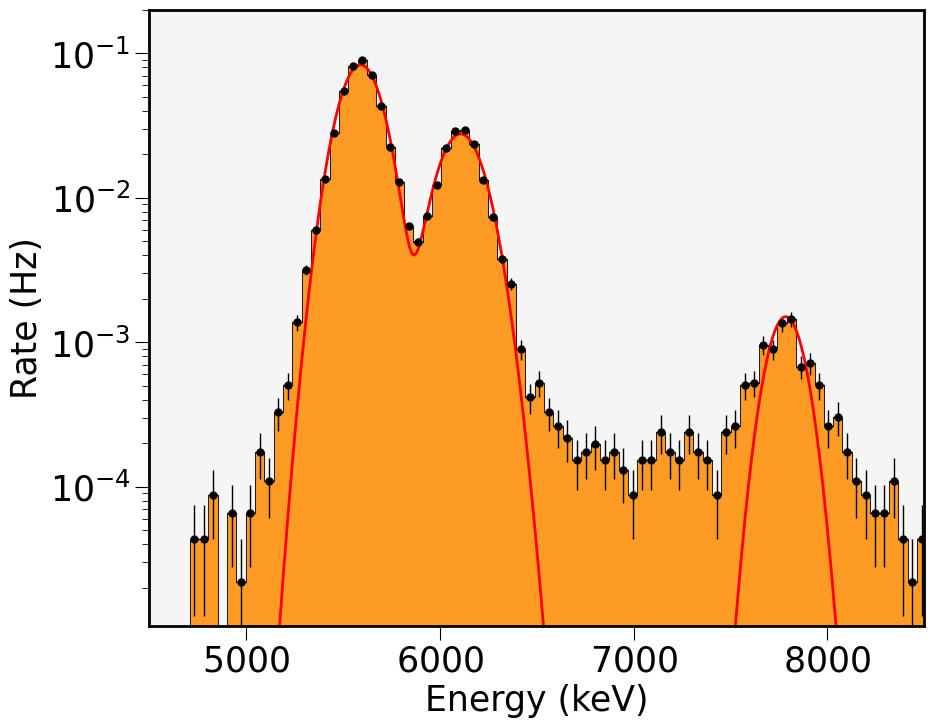

In [70]:
# ----- Plotting ----- #
fig, ax = plt.subplots()
# Data
color_hist = crudo.pt.hist_colors[2] if PERIOD == 'High_Rn' else crudo.pt.hist_colors[5]
plt.stairs(E_rate, E_edges, fill=True, color=color_hist, alpha=0.85, ec='black', lw=0.75)

# Fit
x_fit = np.linspace(x_centers.min(), x_centers.max(), 1000)
y_fit = crudo.ff.trigauss_func(x_fit, *popt)
plt.plot(x_fit, y_fit, color="red", label=f"Tri-Gaussian Fit\nχ² / ndof = {chi2 / ndof:.2f}")
plt.errorbar(x_centers, y_values, xerr=x_errors, yerr=y_errors, fmt='o', c='black', ms=5, ecolor='black', elinewidth=1.0)

# ----- Styling ----- #
# # Important text
# y_text = [1.75e-1, 1e-1, 3.5e-2, 1.75e-3] if PERIOD == 'High_Rn' else [1.25e-2, 6e-3, 1.75e-3, 4e-5]
# plt.text(8.40e3, y_text[0], r'A($^{222}$Rn)'f' = ({Rn_activity_CV:.2f} ± {Rn_activity_err:.2f}) Bq / m³', va='center', ha='right')
# plt.text(5590, y_text[1], r'$^{222}$Rn'f' ({Rn222_perc:.1%})', va='bottom', ha='center')
# plt.text(6115, y_text[2], r'$^{218}$Po'f' ({Po218_perc:.1%})', va='bottom', ha='center')
# plt.text(7834, y_text[3], r'$^{214}$Po'f' ({Po214_perc:.1%})', va='bottom', ha='center')

# # Preliminary logo
# LOGO_BOX = OffsetImage(PRELIM_LOGO, zoom = 0.1)
# xy = (E_max, E_rate.max())
# ab = AnnotationBbox(LOGO_BOX, xy, xybox=(-85, 50 if PERIOD == 'High_Rn' else 60), xycoords='data', boxcoords="offset points",  frameon=False)
# ax.add_artist(ab)

plt.xlabel('Energy (keV)')
plt.xlim(4.5e3, 8.5e3)
plt.ylabel('Rate (Hz)')
plt.ylim(y_values.min()-(y_errors.min()/2), 2e-1 if PERIOD == 'High_Rn' else 2e-1)
plt.yscale('log')
# plt.title(f'{PERIOD} (AV)')   
# plt.legend(loc='upper right')

plt.gca().set_facecolor("whitesmoke")
# plt.savefig(f'/lhome/ific/c/ccortesp/Analysis/NEXT-100/Rn_analysis/images/{PERIOD}_Energy.pdf')
plt.show()